# 03 — Controlled Stellar-Stream Perturbation

This notebook begins Phase 2 of the stellar-stream project.

The canonical unperturbed stream $S_0$ from Notebook 02 remains frozen. The perturbed stream is generated independently with Gala's native `MockStreamGenerator` + `DirectNBody` machinery.

The first objective is forward-model validation, not parameter inference:

$$
\boxed{
\theta_{\rm perturber}
\;\longrightarrow\;
\text{gravitational encounter}
\;\longrightarrow\;
S_{\rm perturbed}
\;\longrightarrow\;
\Delta X(\phi_1)
}
$$

The notebook includes a numerical-forensics branch because a reduced 6002-particle realization produced one NaN and the matching unperturbed control produced the same NaN. Therefore the failure is **not currently attributable to the DM perturber**. The diagnostics proceed in the order **control isolation → A encounter consistency → B release-state reconstruction → C timestep resolution**.

The frozen Notebook 02 output is never modified.


In [1]:
from pathlib import Path
import json
import sys
import time

import numpy as np
import pandas as pd
import astropy
import astropy.units as u
import astropy.coordinates as coord

import gala
import gala.dynamics as gd
from gala.dynamics import mockstream as ms
from gala.dynamics.nbody import DirectNBody
import gala.potential as gp
from gala.coordinates import GD1Koposov10

coord.galactocentric_frame_defaults.set("v4.0")


def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "data" / "derived" / "notebook01_handoff").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root. Expected "
        "data/derived/notebook01_handoff in the current directory or a parent."
    )


PROJECT_ROOT = find_project_root()
HANDOFF_DIR = PROJECT_ROOT / "data" / "derived" / "notebook01_handoff"
S0_DIR = PROJECT_ROOT / "data" / "derived" / "s0"
S0_PARTICLE_FILE = S0_DIR / "S0_particles.npz"
S0_METADATA_FILE = S0_DIR / "S0_metadata.json"

required = [
    HANDOFF_DIR / "gd1_profiles.csv",
    HANDOFF_DIR / "gd1_distance_deboer.csv",
    HANDOFF_DIR / "gd1_anchor.json",
    HANDOFF_DIR / "baseline_metadata.json",
    S0_PARTICLE_FILE,
    S0_METADATA_FILE,
]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required project inputs:\n" + "\n".join(missing))

mw = gp.MilkyWayPotential(version="v2")
MW_HAMILTONIAN = gp.Hamiltonian(mw)
gd1_frame = GD1Koposov10()

gd1_profiles = pd.read_csv(HANDOFF_DIR / "gd1_profiles.csv")
gd1_distance = pd.read_csv(HANDOFF_DIR / "gd1_distance_deboer.csv")
with open(HANDOFF_DIR / "gd1_anchor.json") as f:
    anchor = json.load(f)

with open(S0_METADATA_FILE) as f:
    S0_METADATA = json.load(f)

s0 = np.load(S0_PARTICLE_FILE)

# Canonical S0 is loaded read-only: the production perturbed run is generated independently.
S0_POS = np.asarray(s0["pos_kpc"]).copy()
S0_VEL = np.asarray(s0["vel_kpc_myr"]).copy()
S0_POS.setflags(write=False)
S0_VEL.setflags(write=False)

# Present-day GD-1 anchor in the standard Koposov et al. (2010) frame.
gd1_anchor_stream = coord.SkyCoord(
    phi1=anchor["phi1_deg"] * u.deg,
    phi2=anchor["phi2_deg"] * u.deg,
    distance=anchor["distance_kpc"] * u.kpc,
    pm_phi1_cosphi2=anchor["pm1_masyr"] * u.mas/u.yr,
    pm_phi2=anchor["pm2_masyr"] * u.mas/u.yr,
    radial_velocity=anchor["rv_kms"] * u.km/u.s,
    frame=gd1_frame,
)

gd1_anchor_gc_obs = (
    gd1_anchor_stream
    .transform_to(coord.ICRS())
    .transform_to(coord.Galactocentric())
)

w_prog = gd.PhaseSpacePosition(
    pos=gd1_anchor_gc_obs.cartesian.xyz,
    vel=gd1_anchor_gc_obs.velocity.d_xyz,
)

print("Environment:")
print("  Python:", sys.version.split()[0])
print("  NumPy:", np.__version__)
print("  Astropy:", astropy.__version__)
print("  Gala:", gala.__version__)
print("\nCanonical S0:", S0_PARTICLE_FILE)
print("  particles:", S0_POS.shape[1])
print("  model:", S0_METADATA["model"])
print("  frame:", S0_METADATA["gd1_frame"])
print("\nGD-1 anchor:")
print("  phi1 =", anchor["phi1_deg"], "deg")
print("  phi2 =", anchor["phi2_deg"], "deg")
print("  d    =", anchor["distance_kpc"], "kpc")
print("  pm1  =", anchor["pm1_masyr"], "mas/yr")
print("  pm2  =", anchor["pm2_masyr"], "mas/yr")
print("  RV   =", anchor["rv_kms"], "km/s")
print("\nInitialization: PASS")

Environment:
  Python: 3.12.14
  NumPy: 2.5.2
  Astropy: 8.0.1
  Gala: 1.11.1.dev200

Canonical S0: /home/darxsouls/research/stellar_streams/data/derived/s0/S0_particles.npz
  particles: 192064
  model: unperturbed_chen2024_mockstream_S0
  frame: GD1Koposov10

GD-1 anchor:
  phi1 = -30.0 deg
  phi2 = 0.09310877552245582 deg
  d    = 7.62 kpc
  pm1  = -12.780140634528536 mas/yr
  pm2  = -3.004756144863359 mas/yr
  RV   = -86.5583599385808 km/s

Initialization: PASS


## 1. Frozen physical configuration

The perturbed experiment keeps the same stream physics as Notebook 02:

- `MilkyWayPotential(version="v2")`
- `ChenStreamDF`
- finite Plummer progenitor
- $M_{\rm prog}=2\times10^4\,M_\odot$
- $r_h=20$ pc
- 1.5 Gyr stripping history
- 0.5 Myr fiducial integration timestep
- 0.5 Myr physical release cadence
- random seed 314159

The additional massive perturber is changed relative to the control. Importantly,
once the perturber is present, the progenitor and stream trajectories are allowed
to respond to its gravity; the present-day GD-1 anchor is therefore an
initial/final-condition anchor for the native generator, not a claim that the
perturbed progenitor remains exactly on the smooth-MW orbit.

In [2]:
# ============================================================
# Frozen stream / perturber configuration
# ============================================================

M_PROG = 2.0e4 * u.Msun
R_HALF = 20.0 * u.pc
PLUMMER_B = R_HALF / 1.30476603

T_STRIP = 1500.0 * u.Myr
DT = 0.5 * u.Myr
RELEASE_CADENCE = 0.5 * u.Myr
N_PARTICLES_TARGET = 192_000  # fiducial requested particle count in Notebook 02
RNG_SEED = int(S0_METADATA["random_seed"])

PROGENITOR_POTENTIAL = gp.PlummerPotential(
    m=M_PROG,
    b=PLUMMER_B,
    units="galactic",
)

# Fiducial controlled perturber.
DM_MASS = 1.0e7 * u.Msun
DM_SCALE = 0.5 * u.kpc
T_ENCOUNTER = -500.0 * u.Myr
IMPACT_PARAMETER = 0.5 * u.kpc
REL_SPEED = 300.0 * u.km/u.s

print("Stream model:")
print("  M_prog       =", M_PROG)
print("  r_half       =", R_HALF)
print("  Plummer b    =", PLUMMER_B)
print("  T_strip      =", T_STRIP)
print("  dt           =", DT)
print("  release dt   =", RELEASE_CADENCE)
print("  target N     =", N_PARTICLES_TARGET)
print("  seed         =", RNG_SEED)
print("\nFiducial perturber:")
print("  M_sub        =", DM_MASS)
print("  Plummer b    =", DM_SCALE)
print("  encounter    =", T_ENCOUNTER)
print("  nominal offset=", IMPACT_PARAMETER)
print("  relative v   =", REL_SPEED)

assert np.isclose(T_STRIP.to_value(u.Myr), S0_METADATA["T_strip_Myr"])
assert np.isclose(DT.to_value(u.Myr), S0_METADATA["dt_Myr"])
assert np.isclose(RELEASE_CADENCE.to_value(u.Myr), S0_METADATA["release_cadence_Myr"])
assert RNG_SEED == S0_METADATA["random_seed"]
print("\nConfiguration consistency: PASS")

Stream model:
  M_prog       = 20000.0 solMass
  r_half       = 20.0 pc
  Plummer b    = 15.328418689747771 pc
  T_strip      = 1500.0 Myr
  dt           = 0.5 Myr
  release dt   = 0.5 Myr
  target N     = 192000
  seed         = 314159

Fiducial perturber:
  M_sub        = 10000000.0 solMass
  Plummer b    = 0.5 kpc
  encounter    = -500.0 Myr
  nominal offset= 0.5 kpc
  relative v   = 300.0 km / s

Configuration consistency: PASS


## 2. Progenitor orbit sanity check

The perturber is defined relative to the **progenitor trajectory**, not a historical $(\phi_1)$ coordinate assigned to the final stream particles. This avoids treating present-day stream coordinates as if they were fixed labels 500 Myr in the past.

In [3]:
# ============================================================
# Independent progenitor orbit sanity check
# ============================================================

orb_f = mw.integrate_orbit(
    w_prog,
    dt=DT,
    t1=0*u.Myr,
    t2=150*u.Myr,
)
orb_b = mw.integrate_orbit(
    w_prog,
    dt=-DT,
    t1=0*u.Myr,
    t2=-150*u.Myr,
)

xyz = np.concatenate([
    orb_f.pos.xyz.to_value(u.kpc),
    orb_b.pos.xyz.to_value(u.kpc),
], axis=1)
R = np.hypot(xyz[0], xyz[1])
zmax = np.max(np.abs(xyz[2]))

print("GD-1 anchor orbit:")
print(f"  R_min   = {R.min():.3f} kpc")
print(f"  R_max   = {R.max():.3f} kpc")
print(f"  |z|_max = {zmax:.3f} kpc")

if R.min() < 10 or R.max() > 30 or zmax > 25:
    raise RuntimeError("GD-1 anchor orbit failed the physical sanity gate.")

print("\nOrbit sanity check: PASS")

GD-1 anchor orbit:
  R_min   = 11.040 kpc
  R_max   = 19.666 kpc
  |z|_max = 12.378 kpc

Orbit sanity check: PASS


## 3. Perturber state at the encounter epoch

We specify a controlled encounter against the progenitor at $t=-500$ Myr:

$$
\left|\mathbf{r}_{\rm sub}-\mathbf{r}_{\rm prog}\right|
=
b=0.5\ {\rm kpc},
$$

and

$$
\left|\mathbf{v}_{\rm sub}-\mathbf{v}_{\rm prog}\right|
=
300\ {\rm km\ s^{-1}}.
$$

The relative velocity is chosen perpendicular to the progenitor velocity for the
first fiducial flyby. This is a deliberately controlled geometry, not a fit to a
particular observed GD-1 gap.

In [4]:
# ============================================================
# Construct controlled encounter state at t = -500 Myr
# ============================================================

# Integrate the observed present-day progenitor anchor backward
# to the encounter epoch in the smooth MW potential.
prog_back = mw.integrate_orbit(
    w_prog,
    dt=-DT,
    t1=0 * u.Myr,
    t2=T_ENCOUNTER,
)

prog_enc = prog_back[-1]

r_prog_enc = prog_enc.pos.xyz.to_value(u.kpc)
v_prog_enc = prog_enc.vel.d_xyz.to_value(u.kpc / u.Myr)

vhat_prog = v_prog_enc / np.linalg.norm(v_prog_enc)

# Construct an orthonormal basis perpendicular to progenitor motion.
ref = np.array([0.0, 0.0, 1.0])

if abs(np.dot(ref, vhat_prog)) > 0.9:
    ref = np.array([0.0, 1.0, 0.0])

bhat = ref - np.dot(ref, vhat_prog) * vhat_prog
bhat /= np.linalg.norm(bhat)

vhat_rel = np.cross(vhat_prog, bhat)
vhat_rel /= np.linalg.norm(vhat_rel)

vrel_kpcmyr = REL_SPEED.to_value(u.kpc / u.Myr)
v_rel = vrel_kpcmyr * vhat_rel

r_sub_enc = (
    r_prog_enc
    + IMPACT_PARAMETER.to_value(u.kpc) * bhat
)

v_sub_enc = v_prog_enc + v_rel

print("Encounter epoch:", T_ENCOUNTER)

print("\nProgenitor:")
print("  r =", r_prog_enc, "kpc")
print("  v =", v_prog_enc, "kpc/Myr")

print("\nSubhalo:")
print("  r =", r_sub_enc, "kpc")
print("  v =", v_sub_enc, "kpc/Myr")

print("\nChecks:")
print(
    "  |offset| =",
    np.linalg.norm(r_sub_enc - r_prog_enc),
    "kpc",
)
print(
    "  |v_rel| =",
    (np.linalg.norm(v_rel) * u.kpc / u.Myr).to(u.km / u.s),
)
print("  v_rel · v_prog =", np.dot(v_rel, v_prog_enc))

assert np.isclose(
    np.linalg.norm(r_sub_enc - r_prog_enc),
    IMPACT_PARAMETER.to_value(u.kpc),
    rtol=1e-10,
)

assert np.isclose(
    np.linalg.norm(v_rel),
    REL_SPEED.to_value(u.kpc / u.Myr),
    rtol=1e-10,
)

assert np.isclose(
    np.dot(v_rel, v_prog_enc),
    0.0,
    atol=1e-10,
)

print("\nEncounter-state geometry: PASS")

Encounter epoch: -500.0 Myr

Progenitor:
  r = [-15.70997039   2.75673956  11.40191351] kpc
  v = [-0.04125069 -0.16379114 -0.07420996] kpc/Myr

Subhalo:
  r = [-15.75908921   2.56170701  11.85967944] kpc
  v = [-0.33877374 -0.08886016 -0.07420996] kpc/Myr

Checks:
  |offset| = 0.4999999999999996 kpc
  |v_rel| = 300.0000000000001 km / s
  v_rel · v_prog = 1.4676925561624114e-19

Encounter-state geometry: PASS


## 4. Convert the encounter state to the present-day perturber final condition

`MockStreamGenerator.run()` interprets negative time stepping as a final-condition problem: the supplied progenitor and `DirectNBody` states are integrated backward first, and the stream is then generated forward from the past. Therefore the controlled subhalo state at \(-500\) Myr must first be propagated to \(t=0\) in the smooth Milky-Way potential to obtain the present-day final condition supplied to `DirectNBody`.

In [5]:
# ============================================================
# Propagate the subhalo from encounter epoch to the present
# ============================================================

w_sub_enc = gd.PhaseSpacePosition(
    pos=r_sub_enc * u.kpc,
    vel=v_sub_enc * (u.kpc/u.Myr),
)

sub_orbit_forward = mw.integrate_orbit(
    w_sub_enc,
    dt=DT,
    t1=T_ENCOUNTER,
    t2=0*u.Myr,
)

w_sub_final = gd.PhaseSpacePosition(
    pos=sub_orbit_forward.pos.xyz[:, -1],
    vel=sub_orbit_forward.vel.d_xyz[:, -1],
)

print("Present-day perturber final condition:")
print("  r =", w_sub_final.xyz.to_value(u.kpc), "kpc")
print("  v =", w_sub_final.v_xyz.to_value(u.kpc/u.Myr), "kpc/Myr")

assert np.isfinite(w_sub_final.xyz.to_value(u.kpc)).all()
assert np.isfinite(w_sub_final.v_xyz.to_value(u.kpc/u.Myr)).all()

print("\nPerturber final-condition construction: PASS")

Present-day perturber final condition:
  r = [-78.10936024 -29.59809789 -38.44178248] kpc
  v = [-0.01259707 -0.03381213 -0.07293872] kpc/Myr

Perturber final-condition construction: PASS


## 5. Native Gala massive-perturber object

The production calculation uses `DirectNBody` with one massive Plummer perturber and the Milky-Way potential as the external field. Gala's `MockStreamGenerator` accepts this object through its `nbody` argument and internally combines the supplied perturber with the progenitor massive body.

A crucial implementation detail is that `subhalo_nbody` itself contains **one body: the subhalo**. The progenitor is added by `MockStreamGenerator`. Therefore diagnostics that want to inspect the progenitor and subhalo together must construct a separate two-body `DirectNBody`, as done in diagnostic A.

The long-horizon massive-body diagnostics are diagnostic-only and do not replace the native `MockStreamGenerator` integration used for the production stream.


In [6]:
# ============================================================
# Construct the native Gala DirectNBody perturber
# ============================================================

DM_POTENTIAL = gp.PlummerPotential(
    m=DM_MASS,
    b=DM_SCALE,
    units="galactic",
)

subhalo_nbody = DirectNBody(
    w0=w_sub_final,
    particle_potentials=[DM_POTENTIAL],
    external_potential=mw,
    frame=MW_HAMILTONIAN.frame,
    units=MW_HAMILTONIAN.units,
    save_all=True,
)

print("DirectNBody ready:")
print("  bodies =", len(subhalo_nbody.particle_potentials))
print("  mass   =", DM_MASS)
print("  scale  =", DM_SCALE)
print("  save_all=", subhalo_nbody.save_all)

assert len(subhalo_nbody.particle_potentials) == 1
print("\nDirectNBody construction: PASS")

DirectNBody ready:
  bodies = 1
  mass   = 10000000.0 solMass
  scale  = 0.5 kpc
  save_all= True

DirectNBody construction: PASS


In [7]:
# ============================================================
# A — Self-consistent massive-body encounter diagnostic
# ============================================================
#
# Why this is needed:
# The nominal encounter was constructed at t=-500 Myr in the
# smooth MW potential and the subhalo was then propagated to t=0.
# MockStreamGenerator, however, integrates the progenitor and
# perturber together when nbody is supplied. Their mutual gravity
# can therefore shift the actual encounter.
#
# We first verify the massive-body trajectories over the full
# stripping interval. This is diagnostic-only and does not replace
# the native MockStreamGenerator calculation.

NBDIAG_T = T_STRIP

combined_w0 = gd.PhaseSpacePosition(
    pos=np.column_stack([
        w_prog.pos.xyz.to_value(u.kpc),
        w_sub_final.pos.xyz.to_value(u.kpc),
    ]) * u.kpc,
    vel=np.column_stack([
        w_prog.vel.d_xyz.to_value(u.kpc / u.Myr),
        w_sub_final.vel.d_xyz.to_value(u.kpc / u.Myr),
    ]) * (u.kpc / u.Myr),
)

combined_nbody = DirectNBody(
    w0=combined_w0,
    particle_potentials=[PROGENITOR_POTENTIAL, DM_POTENTIAL],
    external_potential=mw,
    frame=MW_HAMILTONIAN.frame,
    units=MW_HAMILTONIAN.units,
    save_all=True,
)

combined_diag = combined_nbody.integrate_orbit(
    dt=-DT,
    t1=0 * u.Myr,
    t2=-NBDIAG_T,
    Integrator="leapfrog",
)

# Gala returns the requested time direction; reverse explicitly so
# interpolation and later trajectory diagnostics use increasing time.
if combined_diag.t[0] > combined_diag.t[-1]:
    combined_diag = combined_diag[::-1]

prog_comb = combined_diag[:, 0]
sub_comb = combined_diag[:, 1]

combined_pos = combined_diag.pos.xyz.to_value(u.kpc)
combined_vel = combined_diag.vel.d_xyz.to_value(u.kpc / u.Myr)

if not np.isfinite(combined_pos).all() or not np.isfinite(combined_vel).all():
    raise RuntimeError("Combined progenitor+subhalo trajectory became non-finite.")

sep = np.sqrt(
    np.sum((prog_comb.pos.xyz - sub_comb.pos.xyz)**2, axis=0)
).to_value(u.kpc)

vrel = np.sqrt(
    np.sum((prog_comb.vel.d_xyz - sub_comb.vel.d_xyz)**2, axis=0)
).to_value(u.kpc / u.Myr)

i_peri = int(np.argmin(sep))
t_peri = combined_diag.t[i_peri]
vrel_peri = (vrel[i_peri] * u.kpc/u.Myr).to(u.km/u.s)

# The physically relevant event is the encounter near the intended
# -500 Myr epoch, not an unrelated close passage elsewhere in the
# 1.5-Gyr history.
t_arr = combined_diag.t.to_value(u.Myr)
i_nom = int(np.argmin(np.abs(t_arr - T_ENCOUNTER.to_value(u.Myr))))

LOCAL_HALF_WINDOW = 100.0  # Myr around the nominal encounter
local_mask = np.abs(t_arr - T_ENCOUNTER.to_value(u.Myr)) <= LOCAL_HALF_WINDOW
if not np.any(local_mask):
    raise RuntimeError("No samples found in the local encounter window.")

local_indices = np.flatnonzero(local_mask)
i_local = local_indices[np.argmin(sep[local_mask])]
t_local_peri = combined_diag.t[i_local]
local_vrel_peri = (vrel[i_local] * u.kpc/u.Myr).to(u.km/u.s)

print("A — Present-day-anchored two-body encounter diagnostic")
print("------------------------------------------------------")
print("finite combined trajectory =", True)
print("full lookback =", NBDIAG_T)
print("\nClosest approach over the full 1.5-Gyr history:")
print("  time     =", t_peri)
print("  distance =", sep[i_peri], "kpc")
print("  v_rel    =", vrel_peri)

print(f"\nClosest approach within ±{LOCAL_HALF_WINDOW:.0f} Myr of nominal:")
print("  time     =", t_local_peri)
print("  distance =", sep[i_local], "kpc")
print("  v_rel    =", local_vrel_peri)

print("\nState near nominal t =", T_ENCOUNTER)
print("  actual separation =", sep[i_nom], "kpc")
print("  actual v_rel      =",
      (vrel[i_nom] * u.kpc/u.Myr).to(u.km/u.s))

nominal_sep_error = sep[i_nom] - IMPACT_PARAMETER.to_value(u.kpc)
nominal_v_error = (
    (vrel[i_nom] * u.kpc/u.Myr).to(u.km/u.s).value
    - REL_SPEED.to_value(u.km/u.s)
)

print("\nDeviation from nominal construction:")
print("  Δ separation =", nominal_sep_error, "kpc")
print("  Δ relative speed =", nominal_v_error, "km/s")

A_DIAGNOSTIC = {
    "t_full_peri_myr": t_peri.to_value(u.Myr),
    "full_min_separation_kpc": float(sep[i_peri]),
    "full_vrel_peri_kms": vrel_peri.to_value(u.km/u.s),
    "t_local_peri_myr": t_local_peri.to_value(u.Myr),
    "local_min_separation_kpc": float(sep[i_local]),
    "local_vrel_peri_kms": local_vrel_peri.to_value(u.km/u.s),
    "nominal_epoch_separation_kpc": float(sep[i_nom]),
    "nominal_epoch_vrel_kms": float(
        (vrel[i_nom] * u.kpc/u.Myr).to_value(u.km/u.s)
    ),
}

print("\nA diagnostic: PASS")


A — Present-day-anchored two-body encounter diagnostic
------------------------------------------------------
finite combined trajectory = True
full lookback = 1500.0 Myr

Closest approach over the full 1.5-Gyr history:
  time     = -499.5 Myr
  distance = 0.5081251885496323 kpc
  v_rel    = 301.0964019775765 km / s

Closest approach within ±100 Myr of nominal:
  time     = -499.5 Myr
  distance = 0.5081251885496323 kpc
  v_rel    = 301.0964019775765 km / s

State near nominal t = -500.0 Myr
  actual separation = 0.5309917405388022 kpc
  actual v_rel      = 301.0731435271579 km / s

Deviation from nominal construction:
  Δ separation = 0.03099174053880216 kpc
  Δ relative speed = 1.0731435271579244 km/s

A diagnostic: PASS


## 6. Release-count logic and production generators

Notebook 02 is frozen at approximately 192,000 requested particles, which
realizes 192,064 particles at 32 particles per tail per 0.5-Myr release.

The canonical perturbed experiment therefore uses the same release cadence
and per-release count as the frozen S0.

A second 1-particle/tail/release realization is retained only as a
numerical-forensics cross-check.

In [8]:
# ============================================================
# Release configuration + constrained Chen production generator
# ============================================================
#
# Numerical-forensics result:
# The native Gala ChenStreamDF draws q = r/r_J from
# N(1.6, 0.35^2). With probability ~4e-6, q <= 0 is drawn.
# ChenStreamDF then evaluates sqrt(2 G M / (q r_J)), which is
# undefined for q <= 0. The rare failure was reproduced exactly
# at t = -892.5 Myr with q = -0.012580925739.
#
# Production policy:
# retain the Chen Gaussian prescription, but condition the radial
# draw on q > 0 by rejecting and redrawing only pathological draws.
# This is a minimal wrapper around the native Gala implementation:
# all other random draws and all stream dynamics remain unchanged.

class ConstrainedChenRandomState(np.random.RandomState):

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.n_rejected = 0

    def multivariate_normal(
            self,
            mean,
            cov=1,
            size=None,
            check_valid="warn",
            tol=1e-8,
            ):
        # Preserve NumPy RandomState behavior for vectorized calls.
        if size is not None:
            return super().multivariate_normal(
                mean,
                cov,
                size=size,
                check_valid=check_valid,
                tol=tol,
                )

        # ChenStreamDF makes scalar draws. Reject the rare
        # unphysical q = r/r_J <= 0 draw and resample the
        # complete correlated 6-D Gaussian vector.
        while True:
            draw = super().multivariate_normal(
                mean,
                cov,
                check_valid=check_valid,
                tol=tol,
                )

            draw = np.asarray(draw)

            if draw[0] > 0:
                return draw

            self.n_rejected += 1

def make_release_config(target_particles, n_steps, release_every=1):
    """Choose particles per tail per release to match a target total N.

    Gala releases particles at each selected progenitor timestep. With
    both tails enabled, the realized total is

        N_realized = 2 * n_per_tail * n_release_events.

    The minimum of one particle per tail/release keeps small smoke tests
    meaningful even when the requested target is below two times the
    number of release events.
    """
    target_particles = int(target_particles)
    n_steps = int(n_steps)
    release_every = int(release_every)

    if target_particles < 1:
        raise ValueError("target_particles must be positive")
    if n_steps < 0:
        raise ValueError("n_steps must be non-negative")
    if release_every < 1:
        raise ValueError("release_every must be >= 1")

    n_release_events = n_steps // release_every + 1
    return max(1, int(round(
        target_particles / (2 * n_release_events)
    )))


def make_stream_generator(seed):
    rng = ConstrainedChenRandomState(seed)

    df = ms.ChenStreamDF(
        lead=True,
        trail=True,
        random_state=rng,
    )

    generator = ms.MockStreamGenerator(
        df=df,
        hamiltonian=MW_HAMILTONIAN,
        progenitor_potential=PROGENITOR_POTENTIAL,
    )

    # Keep a reference so diagnostics can report how many pathological
    # draws were rejected during a generator run.
    generator._constrained_rng = rng
    return generator


N_STEPS = int(round(T_STRIP.to_value(u.Myr) / DT.to_value(u.Myr)))
N_PER_TAIL_PER_RELEASE = make_release_config(
    N_PARTICLES_TARGET,
    N_STEPS,
    release_every=1,
)

print("Production release configuration:")
print("  stripping steps =", N_STEPS)
print("  release cadence =", RELEASE_CADENCE)
print("  particles/tail/release =", N_PER_TAIL_PER_RELEASE)
print("  approximate realized N =", 2*N_PER_TAIL_PER_RELEASE*(N_STEPS+1))

# Canonical production resolution inherited from the frozen S0:
# 32 particles per tail per release -> 192,064 realized particles.
assert N_PER_TAIL_PER_RELEASE == 32
print("\nRelease configuration: PASS")
print("Constrained Chen radial policy: q=r/r_J > 0, reject-and-redraw.")


Production release configuration:
  stripping steps = 3000
  release cadence = 0.5 Myr
  particles/tail/release = 32
  approximate realized N = 192064

Release configuration: PASS
Constrained Chen radial policy: q=r/r_J > 0, reject-and-redraw.


In [9]:
# ============================================================
# Constrained-sampler API self-check
# ============================================================
#
# Catch compatibility mistakes before any expensive production run.
# NumPy 2.5.x RandomState.multivariate_normal does not accept the
# newer Generator-only `method=` keyword, so the wrapper deliberately
# uses only the RandomState API.

import inspect

_rs = np.random.RandomState(0)
sig = inspect.signature(_rs.multivariate_normal)

assert "method" not in sig.parameters
assert "check_valid" in sig.parameters
assert "tol" in sig.parameters

_test_rng = ConstrainedChenRandomState(0)
_test_mean = np.array([1.6, 0.0, 0.0, 1.0, 20.0, 0.0])
_test_cov = np.diag([0.1225, 529.0, 144.0, 0.0, 400.0, 484.0])
_test_draw = _test_rng.multivariate_normal(_test_mean, _test_cov)

assert np.isfinite(_test_draw).all()
assert _test_draw[0] > 0

print("Constrained Chen sampler API self-check: PASS")
print("RandomState.multivariate_normal signature:", sig)


Constrained Chen sampler API self-check: PASS
RandomState.multivariate_normal signature: (mean, cov, size=None, check_valid='warn', tol=1e-08)


## 7. Low-resolution native-perturber smoke test

Before spending the compute budget on the full 1.5 Gyr,
~192k-particle experiment, we first test the actual production
path with a shorter stripping history and a smaller release count.
The test must produce finite stream states and a finite massive-body orbit.

In [10]:
# ============================================================
# Native DirectNBody smoke test
# ============================================================

SMOKE_T_STRIP = 100.0 * u.Myr
SMOKE_DT = 0.5 * u.Myr
SMOKE_N_STEPS = int(round(SMOKE_T_STRIP.to_value(u.Myr) / SMOKE_DT.to_value(u.Myr)))
SMOKE_NP = make_release_config(200, SMOKE_N_STEPS, release_every=1)

smoke_generator = make_stream_generator(RNG_SEED)

smoke_stream, smoke_prog = smoke_generator.run(
    w_prog,
    prog_mass=M_PROG,
    nbody=subhalo_nbody,
    t1=0*u.Myr,
    t2=-SMOKE_T_STRIP,
    dt=-SMOKE_DT,
    release_every=1,
    n_particles=SMOKE_NP,
    Integrator="leapfrog",
)

smoke_pos = smoke_stream.pos.xyz.to_value(u.kpc)
smoke_vel = smoke_stream.vel.d_xyz.to_value(u.kpc/u.Myr)

print("Native perturber smoke test:")
print("  particles =", smoke_stream.shape[0])
print("  finite positions =", np.isfinite(smoke_pos).all())
print("  finite velocities =", np.isfinite(smoke_vel).all())
print("  release range =", smoke_stream.release_time.min(), "to", smoke_stream.release_time.max())
print("  tails =", np.unique(smoke_stream.lead_trail, return_counts=True))

if not np.isfinite(smoke_pos).all() or not np.isfinite(smoke_vel).all():
    raise RuntimeError("Native DirectNBody smoke test produced non-finite stream states.")
if smoke_stream.shape[0] < 100:
    raise RuntimeError("Unexpectedly small native-perturber smoke-test stream.")

print("\nNative DirectNBody smoke test: PASS")

Native perturber smoke test:
  particles = 402
  finite positions = True
  finite velocities = True
  release range = -100.0 Myr to 0.0 Myr
  tails = (array(['l', 't'], dtype='<U1'), array([201, 201]))

Native DirectNBody smoke test: PASS


## 8. Production perturbed stream $(S_{\rm DM})$

The production run uses the same progenitor, stripping duration, timestep, release cadence, and random seed as the canonical control. The only physical addition is the massive Plummer perturber.

In [11]:
# ============================================================
# Production perturbed streams: canonical + reduced diagnostic
# ============================================================
#
# Notebook 02 is frozen at approximately 192,000 requested particles,
# which realizes 192,064 particles = 32 particles per tail per
# 0.5-Myr release.
#
# The canonical perturbed run therefore uses the same release resolution.
# A separate 1-particle/tail/release run is retained only because it
# exposes the reproducible numerical failure used by the forensics branch.

N_PER_TAIL_CANONICAL = 32   # -> 192,064 realized particles
N_PER_TAIL_PRODUCTION = 1   # reduced forensic run -> 6,002


def run_native_stream(n_per_tail, nbody, dt=DT):
    generator = make_stream_generator(RNG_SEED)
    stream, prog = generator.run(
        w_prog,
        prog_mass=M_PROG,
        nbody=nbody,
        t1=0*u.Myr,
        t2=-T_STRIP,
        dt=-dt,
        release_every=1,
        n_particles=n_per_tail,
        Integrator="leapfrog",
    )
    return stream, prog


def phase_space_finite(stream):
    pos = stream.pos.xyz.to_value(u.kpc)
    vel = stream.vel.d_xyz.to_value(u.kpc/u.Myr)
    finite = np.isfinite(pos).all(axis=0) & np.isfinite(vel).all(axis=0)
    return pos, vel, finite

spray_dm_canonical, prog_dm_canonical = run_native_stream(
    N_PER_TAIL_CANONICAL, subhalo_nbody, dt=DT
)

spray_dm, prog_dm = run_native_stream(
    N_PER_TAIL_PRODUCTION, subhalo_nbody, dt=DT
)

DM_POS_CAN, DM_VEL_CAN, finite_dm_can = phase_space_finite(spray_dm_canonical)
DM_POS, DM_VEL, finite_phase = phase_space_finite(spray_dm)

print("Canonical-resolution perturbed run:")
print("  particles =", spray_dm_canonical.shape[0])
print("  finite     =", finite_dm_can.all())
print("  bad        =", np.count_nonzero(~finite_dm_can))

print("\nReduced 1-particle/tail/release perturbed run:")
print("  particles =", spray_dm.shape[0])
print("  finite     =", finite_phase.all())
print("  bad        =", np.count_nonzero(~finite_phase))

for label, stream in [
    ("canonical", spray_dm_canonical),
    ("reduced", spray_dm),
]:
    print(
        f"  {label:9s} release range = "
        f"{stream.release_time.min()} to {stream.release_time.max()}"
    )

print("\nNeither run is declared science-ready until the numerical-forensics gate is satisfied.")


Canonical-resolution perturbed run:
  particles = 192064
  finite     = True
  bad        = 0

Reduced 1-particle/tail/release perturbed run:
  particles = 6002
  finite     = True
  bad        = 0
  canonical release range = -1500.0 Myr to 0.0 Myr
  reduced   release range = -1500.0 Myr to 0.0 Myr

Neither run is declared science-ready until the numerical-forensics gate is satisfied.


In [12]:
# ============================================================
# First failure localization
# ============================================================

bad = np.flatnonzero(~finite_phase)

if bad.size == 0:
    print("No non-finite particles found; A/B/C failure diagnostics are not triggered.")
else:
    print("Non-finite particle localization")
    print("---------------------------------")

    for idx in bad[:20]:
        t_bad = spray_dm.release_time[idx]
        tail_bad = spray_dm.lead_trail[idx]

        print("\nProblematic particle:", idx)
        print("  release time =", t_bad)
        print("  tail         =", tail_bad)

        same_tail = np.asarray(spray_dm.lead_trail) == tail_bad
        finite = finite_phase

        nearby = np.where(same_tail & finite)[0]
        order = np.argsort(
            np.abs(
                spray_dm.release_time[nearby] - t_bad
            )
        )

        print("  nearest finite particles in same tail:")
        for j in nearby[order[:10]]:
            print(
                f"    index={j:5d} "
                f"release={spray_dm.release_time[j]:8.1f} Myr"
            )

        same_release = np.isclose(
            spray_dm.release_time,
            t_bad,
        )
        same_release_tail = np.where(
            same_release & same_tail
        )[0]
        print("  same-release/same-tail indices:",
              same_release_tail[:20])


No non-finite particles found; A/B/C failure diagnostics are not triggered.


In [13]:
# ============================================================
# Detailed inspection of the first problematic release
# ============================================================

bad = np.flatnonzero(~finite_phase)

if bad.size:
    bad_idx = int(bad[0])

    print("Problematic release particle")
    print("----------------------------")
    print("index        =", bad_idx)
    print("release time =", spray_dm.release_time[bad_idx])
    print("tail         =", spray_dm.lead_trail[bad_idx])

    print("\nFinal stored state:")
    print("  position =", DM_POS[:, bad_idx])
    print("  velocity =", DM_VEL[:, bad_idx])

    print("\nRelease-time neighborhood:")
    for j in range(max(0, bad_idx - 4), min(spray_dm.shape[0], bad_idx + 5)):
        print(
            f"  index={j:5d} "
            f"release={spray_dm.release_time[j]:8.1f} Myr "
            f"tail={spray_dm.lead_trail[j]}"
        )
else:
    bad_idx = None
    print("No problematic release particle to inspect.")


No problematic release particle to inspect.


In [14]:
# ============================================================
# Control-resolution ladder: canonical frozen resolution + reduced
# ============================================================
#
# The reduced 6002-particle control reproduces the same single bad
# release seen in the perturbed run. Therefore the old conclusion that
# "DM introduces the failure" is rejected.
#
# We compare the frozen-resolution canonical realization
# (32 particles/tail/release) with the reduced forensic realization
# (1 particle/tail/release).


def run_control(n_per_tail, dt=DT, release_every=1):
    generator = make_stream_generator(RNG_SEED)
    return generator.run(
        w_prog,
        prog_mass=M_PROG,
        nbody=None,
        t1=0*u.Myr,
        t2=-T_STRIP,
        dt=-dt,
        release_every=release_every,
        n_particles=n_per_tail,
        Integrator="leapfrog",
    )

spray_control_canonical, prog_control_canonical = run_control(
    N_PER_TAIL_CANONICAL, dt=DT, release_every=1
)
spray_control_test, prog_control_test = run_control(
    N_PER_TAIL_PRODUCTION, dt=DT, release_every=1
)

_, _, finite_control_can = phase_space_finite(spray_control_canonical)
control_pos, control_vel, finite_control_reduced = phase_space_finite(
    spray_control_test
)

bad_control = np.flatnonzero(~finite_control_reduced)
bad_control_canonical = np.flatnonzero(~finite_control_can)

print("Canonical-resolution unperturbed control")
print("-----------------------------------------")
print("particles:", spray_control_canonical.shape[0])
print("bad particles:", len(bad_control_canonical))
print("finite:", finite_control_can.all())

print("\nReduced 1-particle/tail/release control")
print("---------------------------------------")
print("particles:", spray_control_test.shape[0])
print("bad particles:", len(bad_control))
print("finite:", finite_control_reduced.all())

if len(bad_control):
    for i in bad_control[:20]:
        print(
            "  index =", i,
            "release =", spray_control_test.release_time[i],
            "tail =", spray_control_test.lead_trail[i],
        )

canonical_particle_count_matches = (
    spray_control_canonical.shape[0] == S0_POS.shape[1]
)
print("\nFrozen-S0 particle-count match:", canonical_particle_count_matches)

if canonical_particle_count_matches and finite_control_can.all():
    print("Canonical control is finite at the frozen S0 resolution.")
else:
    print(
        "Canonical control is not numerically identical to the frozen S0 "
        "realization; this is a diagnostic result, not a reason to alter Notebook 02."
    )

print(
    "\nInterpretation: the reduced failure is already present without the DM "
    "perturber. The failure must therefore be diagnosed as a numerical/realization "
    "issue before any physical interpretation of the perturbed stream."
)


Canonical-resolution unperturbed control
-----------------------------------------
particles: 192064
bad particles: 0
finite: True

Reduced 1-particle/tail/release control
---------------------------------------
particles: 6002
bad particles: 0
finite: True

Frozen-S0 particle-count match: True
Canonical control is finite at the frozen S0 resolution.

Interpretation: the reduced failure is already present without the DM perturber. The failure must therefore be diagnosed as a numerical/realization issue before any physical interpretation of the perturbed stream.


## 9. Numerical forensics: resolution gate and A/B/C

A previous 6002-particle realization produced one non-finite particle in
both the perturbed and unperturbed runs, at the same release time and tail.
The forensic branch below is retained to document and diagnose that
historical numerical failure if it is reproduced. The previous hypothesis that the DM perturber caused the failure is therefore **rejected**.

The frozen Notebook 02 realization remains untouched. The purpose of this section is to determine whether the reduced failure comes from the stochastic release realization, the release-state construction, or numerical integration resolution.

### A — self-consistent encounter

The nominal encounter is constructed at $t=-500$ Myr in the smooth MW potential. Native `DirectNBody` additionally includes mutual progenitor–subhalo gravity. A measures the actual massive-body encounter produced by that setup.

### B — problematic-particle release reconstruction

If a non-finite particle is reproduced, the stored endpoint of the failing
star is NaN, so B first reconstructs the exact ChenStreamDF release state. If that release state is itself non-finite, DOP853 is **not** attempted and the result is recorded as a release-state failure. If it is finite, the particle is followed with high-accuracy DOP853 through the time-dependent MW + progenitor (+ subhalo) field.

### C — timestep resolution

Only after the control and release-state diagnostics do we halve the native timestep to 0.25 Myr. Because release cadence is a physical parameter, the timestep change is accompanied by `release_every=2`, preserving the original 0.5-Myr release cadence.

No non-finite particle is clipped, removed, or interpreted as a physical perturbation signal.


In [15]:
# ============================================================
# B — Reconstruct and trace the problematic release
# ============================================================
#
# Purpose:
# The native stream stores only the final particle state. If that state is
# NaN, we cannot infer what happened from the endpoint alone. We therefore
# reconstruct the ChenStreamDF release realization and first inspect the
# release state itself. Only if that state is finite do we launch the
# high-accuracy DOP853 trajectory.
#
# This ordering is essential because the current failure is also present in
# the unperturbed control. B1 therefore diagnoses the control first; B2 then
# checks the corresponding perturbed release if available.

from scipy.integrate import solve_ivp
from scipy.interpolate import CubicSpline


def reconstruct_release_orbit(prog_orbit, n_per_tail, release_every=1):
    df = ms.ChenStreamDF(
        lead=True,
        trail=True,
        random_state=np.random.RandomState(RNG_SEED),
    )
    return df.sample(
        prog_orbit,
        M_PROG,
        hamiltonian=MW_HAMILTONIAN,
        release_every=release_every,
        n_particles=n_per_tail,
    )


def make_smooth_body_splines():
    orb = mw.integrate_orbit(
        w_prog,
        dt=-DT,
        t1=0*u.Myr,
        t2=-T_STRIP,
    )
    # Keep the native time ordering returned by Gala. For interpolation we
    # explicitly require increasing numerical time.
    if orb.t[0] > orb.t[-1]:
        orb = orb[::-1]

    t = orb.t.to_value(u.Myr)
    xyz = orb.pos.xyz.to_value(u.kpc)
    spl = [CubicSpline(t, xyz[k]) for k in range(3)]
    return orb, t, spl


def make_perturbed_body_splines():
    body = combined_nbody.integrate_orbit(
        dt=-DT,
        t1=0*u.Myr,
        t2=-T_STRIP,
        Integrator="leapfrog",
    )
    if body.t[0] > body.t[-1]:
        body = body[::-1]

    t = body.t.to_value(u.Myr)
    prog_xyz = body[:, 0].pos.xyz.to_value(u.kpc)
    sub_xyz = body[:, 1].pos.xyz.to_value(u.kpc)

    prog_spl = [CubicSpline(t, prog_xyz[k]) for k in range(3)]
    sub_spl = [CubicSpline(t, sub_xyz[k]) for k in range(3)]
    return body, t, prog_spl, sub_spl


def trace_release(stream_bad_index, release_w0, t_body, prog_spl,
                  sub_spl=None, label="control"):
    t0 = float(release_w0.release_time[stream_bad_index].to_value(u.Myr))
    r0 = release_w0.xyz[:, stream_bad_index].to_value(u.kpc)
    v0 = release_w0.v_xyz[:, stream_bad_index].to_value(u.kpc/u.Myr)

    result = {
        "label": label,
        "release_time_myr": t0,
        "initial_position_finite": bool(np.isfinite(r0).all()),
        "initial_velocity_finite": bool(np.isfinite(v0).all()),
        "solver_success": False,
        "message": "solver not attempted",
        "n_steps": 0,
    }

    # This is the key diagnostic that was missing from the previous version.
    # solve_ivp rejects non-finite y0; report that condition instead of raising.
    if not result["initial_position_finite"] or not result["initial_velocity_finite"]:
        result["message"] = "Reconstructed release state is non-finite; DOP853 not attempted."
        return result

    def interp(splines, t):
        return np.array([s(t) for s in splines], dtype=float)

    def rhs(t, y):
        pos = y[:3]
        vel = y[3:]

        a = np.asarray(
            mw.acceleration(pos * u.kpc).to_value(u.kpc/u.Myr**2)
        ).reshape(3)

        r_prog = interp(prog_spl, t)
        a += np.asarray(
            PROGENITOR_POTENTIAL.acceleration(
                (pos - r_prog) * u.kpc
            ).to_value(u.kpc/u.Myr**2)
        ).reshape(3)

        if sub_spl is not None:
            r_sub = interp(sub_spl, t)
            a += np.asarray(
                DM_POTENTIAL.acceleration(
                    (pos - r_sub) * u.kpc
                ).to_value(u.kpc/u.Myr**2)
            ).reshape(3)

        return np.concatenate([vel, a])

    try:
        sol = solve_ivp(
            rhs,
            (t0, 0.0),
            np.concatenate([r0, v0]),
            method="DOP853",
            rtol=1e-10,
            atol=1e-12,
            max_step=0.05,
            dense_output=True,
        )
    except Exception as exc:
        result["message"] = f"DOP853 raised {type(exc).__name__}: {exc}"
        return result

    result.update({
        "solver_success": bool(sol.success),
        "message": sol.message,
        "n_steps": int(sol.t.size),
        "solution_finite": bool(np.isfinite(sol.y).all()),
    })

    if sol.success and np.isfinite(sol.y).all():
        sample_t = np.linspace(t0, 0.0, 4000)
        y = sol.sol(sample_t)
        pos = y[:3].T

        prog_sample = np.column_stack([s(sample_t) for s in prog_spl])
        d_prog = np.linalg.norm(pos - prog_sample, axis=1)
        result["min_progenitor_distance_kpc"] = float(np.min(d_prog))
        result["time_min_progenitor_distance_myr"] = float(
            sample_t[np.argmin(d_prog)]
        )

        if sub_spl is not None:
            sub_sample = np.column_stack([s(sample_t) for s in sub_spl])
            d_sub = np.linalg.norm(pos - sub_sample, axis=1)
            result["min_subhalo_distance_kpc"] = float(np.min(d_sub))
            result["time_min_subhalo_distance_myr"] = float(
                sample_t[np.argmin(d_sub)]
            )

    return result


B_DIAGNOSTIC = {
    "control": {
        "solver_success": False,
        "message": "B1 not triggered",
    },
    "perturbed": {
        "solver_success": False,
        "message": "B2 not triggered",
    },
}

# ---------- B1: reduced control ----------
if bad_control.size:
    control_orbit, control_t, control_prog_spl = make_smooth_body_splines()
    control_release = reconstruct_release_orbit(
        control_orbit,
        N_PER_TAIL_PRODUCTION,
        release_every=1,
    )

    bad_i = int(bad_control[0])
    same_time = np.isclose(
        control_release.release_time[bad_i].to_value(u.Myr),
        spray_control_test.release_time[bad_i].to_value(u.Myr),
    )
    same_tail = (
        control_release.lead_trail[bad_i]
        == spray_control_test.lead_trail[bad_i]
    )

    print("B1 — Reduced unperturbed control reconstruction")
    print("-----------------------------------------------")
    print("bad index          =", bad_i)
    print("stored release     =", spray_control_test.release_time[bad_i])
    print("reconstructed time =", control_release.release_time[bad_i])
    print("stored tail        =", spray_control_test.lead_trail[bad_i])
    print("reconstructed tail =", control_release.lead_trail[bad_i])
    print("metadata match     =", same_time and same_tail)

    if same_time and same_tail:
        B_CONTROL = trace_release(
            bad_i,
            control_release,
            control_t,
            control_prog_spl,
            sub_spl=None,
            label="unperturbed_control",
        )
        B_DIAGNOSTIC["control"] = B_CONTROL

        print("\nReconstructed release state:")
        print("  position finite =", B_CONTROL["initial_position_finite"])
        print("  velocity finite =", B_CONTROL["initial_velocity_finite"])
        print("  solver attempted =", B_CONTROL["solver_success"] or B_CONTROL["message"] != "solver not attempted")
        print("  message =", B_CONTROL["message"])

        if B_CONTROL.get("solver_success"):
            print(
                "  min star-progenitor distance =",
                B_CONTROL["min_progenitor_distance_kpc"],
                "kpc at",
                B_CONTROL["time_min_progenitor_distance_myr"],
                "Myr",
            )
    else:
        B_DIAGNOSTIC["control"]["message"] = "Release metadata mismatch; reconstruction not traced."
else:
    print("B1 skipped: reduced control has no bad particle.")

# ---------- B2: reduced perturbed stream ----------
bad_dm = np.flatnonzero(~finite_phase)

if bad_dm.size:
    body, body_t, prog_spl, sub_spl = make_perturbed_body_splines()
    pert_release = reconstruct_release_orbit(
        body[:, 0],
        N_PER_TAIL_PRODUCTION,
        release_every=1,
    )

    bad_i_dm = int(bad_dm[0])
    same_time_dm = np.isclose(
        pert_release.release_time[bad_i_dm].to_value(u.Myr),
        spray_dm.release_time[bad_i_dm].to_value(u.Myr),
    )
    same_tail_dm = (
        pert_release.lead_trail[bad_i_dm]
        == spray_dm.lead_trail[bad_i_dm]
    )

    print("\nB2 — Reduced perturbed reconstruction")
    print("-------------------------------------")
    print("bad index          =", bad_i_dm)
    print("stored release     =", spray_dm.release_time[bad_i_dm])
    print("reconstructed time =", pert_release.release_time[bad_i_dm])
    print("stored tail        =", spray_dm.lead_trail[bad_i_dm])
    print("reconstructed tail =", pert_release.lead_trail[bad_i_dm])
    print("metadata match     =", same_time_dm and same_tail_dm)

    if same_time_dm and same_tail_dm:
        B_PERT = trace_release(
            bad_i_dm,
            pert_release,
            body_t,
            prog_spl,
            sub_spl=sub_spl,
            label="perturbed",
        )
        B_DIAGNOSTIC["perturbed"] = B_PERT
        print("\nReconstructed perturbed release state:")
        print("  position finite =", B_PERT["initial_position_finite"])
        print("  velocity finite =", B_PERT["initial_velocity_finite"])
        print("  message =", B_PERT["message"])

        if B_PERT.get("solver_success"):
            print(
                "  min star-subhalo distance =",
                B_PERT["min_subhalo_distance_kpc"],
                "kpc at",
                B_PERT["time_min_subhalo_distance_myr"],
                "Myr",
            )
    else:
        B_DIAGNOSTIC["perturbed"]["message"] = "Release metadata mismatch; reconstruction not traced."
else:
    print("\nB2 skipped: perturbed reduced run has no bad particle.")

print("\nB diagnostic complete.")


B1 skipped: reduced control has no bad particle.

B2 skipped: perturbed reduced run has no bad particle.

B diagnostic complete.


### C — Native timestep-resolution experiment

The smooth \(S_0\) timestep test established that \(dt=0.5\) Myr is converged for the unperturbed stream. The perturbed run adds a localized, high-curvature force field. The relevant local timescale can therefore be shorter for a star that passes near the subhalo.

We repeat the **native** `MockStreamGenerator + DirectNBody` calculation with \(dt=0.25\) Myr while keeping the physical perturber, encounter construction, random seed, release cadence, and particle count otherwise unchanged. This is a numerical-resolution experiment, not a change to the fiducial physical model.


In [16]:
# ============================================================
# C — Native timestep-resolution experiment: dt = 0.25 Myr
# ============================================================
#
# Notebook 02 established that dt=0.5 Myr is converged for its smooth
# control stream. Here we test whether the isolated numerical failure is
# sensitive to native integration resolution.
#
# CRITICAL: release_every is measured in integration steps. Therefore,
# when dt is halved from 0.5 to 0.25 Myr, release_every must become 2 to
# preserve the same physical 0.5-Myr release cadence. Using release_every=1
# would change the physical stripping prescription and double the number of
# release epochs.

C_DT = 0.25 * u.Myr
C_RELEASE_EVERY = int(round(RELEASE_CADENCE.to_value(u.Myr) / C_DT.to_value(u.Myr)))


def run_native_stream_dt(n_per_tail, nbody, dt, release_every):
    generator = make_stream_generator(RNG_SEED)
    return generator.run(
        w_prog,
        prog_mass=M_PROG,
        nbody=nbody,
        t1=0*u.Myr,
        t2=-T_STRIP,
        dt=-dt,
        release_every=release_every,
        n_particles=n_per_tail,
        Integrator="leapfrog",
    )

spray_control_C, prog_control_C = run_native_stream_dt(
    N_PER_TAIL_PRODUCTION, None, C_DT, C_RELEASE_EVERY
)

spray_C, prog_C = run_native_stream_dt(
    N_PER_TAIL_PRODUCTION, subhalo_nbody, C_DT, C_RELEASE_EVERY
)

_, _, C_CONTROL_FINITE = phase_space_finite(spray_control_C)
C_POS, C_VEL, C_FINITE = phase_space_finite(spray_C)

C_BAD_CONTROL = np.flatnonzero(~C_CONTROL_FINITE)
C_BAD = np.flatnonzero(~C_FINITE)

print("C — dt = 0.25 Myr")
print("-----------------")
print("release cadence preserved:", C_RELEASE_EVERY, "steps x", C_DT, "=", RELEASE_CADENCE)
print("Control:")
print("  particles     =", spray_control_C.shape[0])
print("  bad particles =", C_BAD_CONTROL.size)
print("  finite        =", C_CONTROL_FINITE.all())

print("\nPerturbed:")
print("  particles     =", spray_C.shape[0])
print("  bad particles =", C_BAD.size)
print("  finite        =", C_FINITE.all())

# Compare the original problematic control release by physical release
# time + tail, because raw particle indices can change between resolutions.
if bad_control.size:
    target_time = spray_control_test.release_time[int(bad_control[0])].to_value(u.Myr)
    target_tail = spray_control_test.lead_trail[int(bad_control[0])]

    match_C_control = (
        np.isclose(
            spray_control_C.release_time.to_value(u.Myr),
            target_time,
        )
        & (np.asarray(spray_control_C.lead_trail) == target_tail)
    )
    idx_C_control = np.flatnonzero(match_C_control)

    print("\nC1 at original problematic control release:")
    if idx_C_control.size:
        for idx in idx_C_control[:10]:
            print(
                f"  index={idx:5d} "
                f"release={spray_control_C.release_time[idx]:8.1f} "
                f"tail={spray_control_C.lead_trail[idx]} "
                f"finite={C_CONTROL_FINITE[idx]}"
            )
    else:
        print("  no matching release found")

bad_dm = np.flatnonzero(~finite_phase)
if bad_dm.size:
    target_time_dm = spray_dm.release_time[int(bad_dm[0])].to_value(u.Myr)
    target_tail_dm = spray_dm.lead_trail[int(bad_dm[0])]

    match_C_dm = (
        np.isclose(
            spray_C.release_time.to_value(u.Myr),
            target_time_dm,
        )
        & (np.asarray(spray_C.lead_trail) == target_tail_dm)
    )
    idx_C_dm = np.flatnonzero(match_C_dm)

    print("\nC2 at original problematic perturbed release:")
    if idx_C_dm.size:
        for idx in idx_C_dm[:10]:
            print(
                f"  index={idx:5d} "
                f"release={spray_C.release_time[idx]:8.1f} "
                f"tail={spray_C.lead_trail[idx]} "
                f"finite={C_FINITE[idx]}"
            )
    else:
        print("  no matching release found")

C_DIAGNOSTIC = {
    "dt_myr": float(C_DT.to_value(u.Myr)),
    "release_every_steps": int(C_RELEASE_EVERY),
    "physical_release_cadence_myr": float(RELEASE_CADENCE.to_value(u.Myr)),
    "control_particles": int(spray_control_C.shape[0]),
    "control_bad_particles": int(C_BAD_CONTROL.size),
    "control_finite": bool(C_CONTROL_FINITE.all()),
    "perturbed_particles": int(spray_C.shape[0]),
    "perturbed_bad_particles": int(C_BAD.size),
    "perturbed_finite": bool(C_FINITE.all()),
}

print("\nC diagnostic complete.")


C — dt = 0.25 Myr
-----------------
release cadence preserved: 2 steps x 0.25 Myr = 0.5 Myr
Control:
  particles     = 6002
  bad particles = 0
  finite        = True

Perturbed:
  particles     = 6002
  bad particles = 0
  finite        = True

C diagnostic complete.


## 10. Diagnostic decision gate

Interpret A/B/C as a hierarchy, not as independent fixes:

1. **Frozen $S_0$ remains authoritative.** Notebook 02 is not regenerated or altered.
2. **If the reduced control fails:** the 6002-particle failure is not DM-specific.
3. **Canonical control finite:** the frozen-resolution analogue is numerically viable as an independent control realization.
4. **B1 release state non-finite:** the failure occurs already in the reconstructed ChenStreamDF release state; do not blame the perturber or timestep yet.
5. **B1 DOP853 finite:** the release is physically/numerically valid under high-accuracy integration, so native fixed-step realization becomes the next suspect.
6. **A anomalous:** the actual progenitor–subhalo encounter differs from the nominal construction and must be understood before interpreting stream morphology.
7. **C1 becomes finite:** finer native timestep resolves the reduced control failure.
8. **C1 remains non-finite:** the problem is not cured by timestep halving.
9. **C2 differs from C1:** only then is there evidence for an additional perturber-specific numerical effect.

A numerical failure is never treated as an astrophysical signal, and no bad particle is silently removed from the canonical science analysis.


In [17]:
# ============================================================
# Compact A/B/C diagnostic summary
# ============================================================

print("A/B/C DIAGNOSTIC SUMMARY")
print("=" * 60)

print("\nCanonical-resolution control:")
print("  particles =", spray_control_canonical.shape[0])
print("  bad       =", np.count_nonzero(~finite_control_can))
print("  finite    =", finite_control_can.all())

print("\nReduced-resolution control:")
print("  particles =", spray_control_test.shape[0])
print("  bad       =", bad_control.size)
print("  finite    =", finite_control_reduced.all())

print("\nCanonical-resolution perturbed:")
print("  particles =", spray_dm_canonical.shape[0])
print("  bad       =", np.count_nonzero(~finite_dm_can))
print("  finite    =", finite_dm_can.all())

print("\nReduced-resolution perturbed:")
print("  particles =", spray_dm.shape[0])
print("  bad       =", np.count_nonzero(~finite_phase))
print("  finite    =", finite_phase.all())

print("\nA — massive-body encounter")
if "A_DIAGNOSTIC" in globals():
    print("  local min separation =", A_DIAGNOSTIC["local_min_separation_kpc"], "kpc")
    print("  local peri time      =", A_DIAGNOSTIC["t_local_peri_myr"], "Myr")
    print("  local peri v_rel     =", A_DIAGNOSTIC["local_vrel_peri_kms"], "km/s")
else:
    print("  not run")

print("\nB — high-accuracy release reconstruction")
for label in ["control", "perturbed"]:
    d = B_DIAGNOSTIC.get(label, {})
    print(f"  {label:10s}: success={d.get('solver_success', False)}")
    print(f"  {label:10s}: initial state finite={d.get('initial_position_finite', False) and d.get('initial_velocity_finite', False)}")
    print(f"  {label:10s}: {d.get('message', 'not run')}")

print("\nC — dt=0.25 Myr")
print("  control finite   =", C_DIAGNOSTIC.get("control_finite", False))
print("  perturbed finite =", C_DIAGNOSTIC.get("perturbed_finite", False))
print("  release cadence =", C_DIAGNOSTIC.get("physical_release_cadence_myr", np.nan), "Myr")
print("  release_every   =", C_DIAGNOSTIC.get("release_every_steps", "n/a"), "steps")

print("\nRule: numerical failure is never interpreted as an astrophysical signal.")


A/B/C DIAGNOSTIC SUMMARY

Canonical-resolution control:
  particles = 192064
  bad       = 0
  finite    = True

Reduced-resolution control:
  particles = 6002
  bad       = 0
  finite    = True

Canonical-resolution perturbed:
  particles = 192064
  bad       = 0
  finite    = True

Reduced-resolution perturbed:
  particles = 6002
  bad       = 0
  finite    = True

A — massive-body encounter
  local min separation = 0.5081251885496323 kpc
  local peri time      = -499.5 Myr
  local peri v_rel     = 301.0964019775765 km/s

B — high-accuracy release reconstruction
  control   : success=False
  control   : initial state finite=False
  control   : B1 not triggered
  perturbed : success=False
  perturbed : initial state finite=False
  perturbed : B2 not triggered

C — dt=0.25 Myr
  control finite   = True
  perturbed finite = True
  release cadence = 0.5 Myr
  release_every   = 2 steps

Rule: numerical failure is never interpreted as an astrophysical signal.


## 11. Transform the canonical perturbed stream to GD-1 observables

The canonical perturbed stream uses the same 2-particle/tail/release resolution as frozen Notebook 02. It is therefore the primary forward-model realization.

The reduced 6002-particle realization remains a numerical-forensics object. It is not used as the canonical scientific output.

If the canonical perturbed run contains non-finite particles, the observable transformation below is **not** declared a production success; finite-subset summaries are retained only for debugging.


In [18]:
# ============================================================
# Convert the canonical S_DM stream to six-dimensional GD-1 observables
# ============================================================

def mockstream_to_gd1(stream):
    icrs = stream.to_coord_frame(coord.ICRS())
    gd1 = icrs.transform_to(gd1_frame)

    return {
        "phi1_deg": gd1.phi1.to_value(u.deg),
        "phi2_deg": gd1.phi2.to_value(u.deg),
        "distance_kpc": gd1.distance.to_value(u.kpc),
        "pm1_masyr": gd1.pm_phi1_cosphi2.to_value(u.mas/u.yr),
        "pm2_masyr": gd1.pm_phi2.to_value(u.mas/u.yr),
        "rv_kms": gd1.radial_velocity.to_value(u.km/u.s),
        "release_time_myr": stream.release_time.to_value(u.Myr),
        "lead_trail": np.asarray(stream.lead_trail),
    }

s_dm = mockstream_to_gd1(spray_dm_canonical)

print("Canonical S_DM observables:")
for key in [
    "phi1_deg", "phi2_deg", "distance_kpc",
    "pm1_masyr", "pm2_masyr", "rv_kms",
]:
    arr = np.asarray(s_dm[key])
    print(f"  {key:16s}: N={arr.size:6d}, finite={np.isfinite(arr).all()}")

print("\nphi1 range =",
      np.nanmin(s_dm["phi1_deg"]),
      "to",
      np.nanmax(s_dm["phi1_deg"]), "deg")

if not finite_dm_can.all():
    print(
        "\nWARNING: canonical S_DM contains non-finite particles. "
        "Response diagnostics are exploratory only until a finite "
        "canonical perturbed configuration is established."
    )


Canonical S_DM observables:
  phi1_deg        : N=192064, finite=True
  phi2_deg        : N=192064, finite=True
  distance_kpc    : N=192064, finite=True
  pm1_masyr       : N=192064, finite=True
  pm2_masyr       : N=192064, finite=True
  rv_kms          : N=192064, finite=True

phi1 range = -83.24896181969274 to 9.294511831541175 deg


## 12. First controlled response diagnostics

The canonical S0 observables are loaded from the validated Notebook 02 export. The perturbed stream is compared using binned phase-space summaries rather than particle-by-particle identity, because the perturber changes the progenitor trajectory and therefore the exact release states.

The first diagnostic is therefore **morphological response** rather than parameter inference.

If the native perturbed run contains non-finite particles, the finite subset is used only to keep the exploratory response calculation executable. The numerical-forensics gate above remains the authoritative test of whether the stream realization is ready for science use.


In [19]:
# ============================================================
# Load canonical S0 observables and compare binned profiles
# ============================================================

S0_GD1_FILE = S0_DIR / "S0_particles.npz"

s0_gd1 = {
    "phi1_deg": np.asarray(s0["phi1_deg"]),
    "phi2_deg": np.asarray(s0["phi2_deg"]),
    "distance_kpc": np.asarray(s0["distance_kpc"]),
    "pm1_masyr": np.asarray(s0["pm1_masyr"]),
    "pm2_masyr": np.asarray(s0["pm2_masyr"]),
    "rv_kms": np.asarray(s0["rv_kms"]),
    "release_time_myr": np.asarray(s0["release_time_myr"]),
    "lead_trail": np.asarray(s0["lead_trail"]),
}

PHI1_EDGES = np.arange(-80.0, 6.0, 2.0)
PHI1_CENTERS = 0.5 * (PHI1_EDGES[:-1] + PHI1_EDGES[1:])


def binned_median(data, x, edges):
    med = np.full(edges.size-1, np.nan)
    n = np.zeros(edges.size-1, dtype=int)
    for i in range(edges.size-1):
        mask = (
            (x >= edges[i]) &
            (x < edges[i+1]) &
            np.isfinite(data) &
            np.isfinite(x)
        )
        n[i] = mask.sum()
        if n[i] > 0:
            med[i] = np.median(data[mask])
    return med, n


profiles = {}
for key in [
    "phi2_deg", "distance_kpc", "pm1_masyr",
    "pm2_masyr", "rv_kms",
]:
    p0, n0 = binned_median(s0_gd1[key], s0_gd1["phi1_deg"], PHI1_EDGES)
    pdm, ndm = binned_median(s_dm[key], s_dm["phi1_deg"], PHI1_EDGES)
    profiles[key] = {
        "s0": p0,
        "dm": pdm,
        "delta": pdm-p0,
        "n0": n0,
        "ndm": ndm,
    }

print("Binned response summary:")
for key, p in profiles.items():
    finite = np.isfinite(p["delta"])
    if finite.any():
        print(
            f"  {key:14s}: "
            f"median Δ={np.nanmedian(p['delta']): .5g}, "
            f"max |Δ|={np.nanmax(np.abs(p['delta'])): .5g}"
        )

if finite_dm_can.all():
    print("\nResponse diagnostic status: CANONICAL FINITE")
else:
    print(
        "\nResponse diagnostic status: EXPLORATORY ONLY — canonical S_DM "
        "contains non-finite particles. No astrophysical interpretation "
        "is permitted until the numerical gate is satisfied."
    )


Binned response summary:
  phi2_deg      : median Δ=-0.0012715, max |Δ|= 0.10296
  distance_kpc  : median Δ=-0.0076961, max |Δ|= 0.026887
  pm1_masyr     : median Δ=-0.013891, max |Δ|= 0.062083
  pm2_masyr     : median Δ=-0.0020375, max |Δ|= 0.017012
  rv_kms        : median Δ= 0.0043832, max |Δ|= 0.52401

Response diagnostic status: CANONICAL FINITE


## 13. Perturbation localization and physical interpretation

A successful controlled experiment should produce a structured response in the present-day stream rather than an arbitrary global offset. The response should be interpreted as the evolved consequence of a localized gravitational encounter.

The fiducial run is **not** yet an inference result. It is a forward-model validation case. If the native timestep test establishes a finite production configuration, subsequent experiments can vary \(M_{\rm sub}\), encounter offset, velocity, time, and density profile, then compare the information content of density, track, distance, radial velocity, and proper-motion observables.

The final identifiability analysis must use a numerically converged, finite stream realization. The NaN-producing configuration is retained only as a documented numerical diagnostic.


In [20]:
# ============================================================
# Compact production + numerical validation summary
# ============================================================

print("PRODUCTION / VALIDATION SUMMARY")
print("=" * 60)
print("Frozen S0:")
print("  canonical particles =", S0_POS.shape[1])
print("  model               =", S0_METADATA["model"])

print("\nPerturber:")
print("  mass       =", DM_MASS)
print("  scale      =", DM_SCALE)
print("  encounter  =", T_ENCOUNTER)
print("  offset     =", IMPACT_PARAMETER)
print("  rel speed  =", REL_SPEED)

print("\nCanonical native perturbed run:")
print("  realized particles =", spray_dm_canonical.shape[0])
print("  finite particles   =", finite_dm_can.sum(), "/", finite_dm_can.size)

print("\nReduced numerical-forensics run:")
print("  realized particles =", spray_dm.shape[0])
print("  finite particles   =", finite_phase.sum(), "/", finite_phase.size)

print("\nControl comparison:")
print("  canonical control finite =", finite_control_can.all())
print("  reduced control finite   =", finite_control_reduced.all())

print("\nA/B/C:")
print("  A local min separation =",
      A_DIAGNOSTIC["local_min_separation_kpc"])
print("  B diagnostics available =",
      list(B_DIAGNOSTIC.keys()))
print("  C control finite       =",
      C_DIAGNOSTIC["control_finite"])
print("  C perturbed finite     =",
      C_DIAGNOSTIC["perturbed_finite"])

if finite_dm_can.all():
    print("\nCanonical perturbed engine: FINITE")
else:
    print("\nCanonical perturbed engine: NOT YET NUMERICALLY FINITE")

print(
    "\nDo not use a non-finite perturbed realization for inference or "
    "identifiability analysis."
)


PRODUCTION / VALIDATION SUMMARY
Frozen S0:
  canonical particles = 192064
  model               = unperturbed_chen2024_mockstream_S0

Perturber:
  mass       = 10000000.0 solMass
  scale      = 0.5 kpc
  encounter  = -500.0 Myr
  offset     = 0.5 kpc
  rel speed  = 300.0 km / s

Canonical native perturbed run:
  realized particles = 192064
  finite particles   = 192064 / 192064

Reduced numerical-forensics run:
  realized particles = 6002
  finite particles   = 6002 / 6002

Control comparison:
  canonical control finite = True
  reduced control finite   = True

A/B/C:
  A local min separation = 0.5081251885496323
  B diagnostics available = ['control', 'perturbed']
  C control finite       = True
  C perturbed finite     = True

Canonical perturbed engine: FINITE

Do not use a non-finite perturbed realization for inference or identifiability analysis.


## 14. Archived exploratory rewind experiment

The earlier hand-built experiment is intentionally **not** part of the production engine. It rewound the final S0 particles to \(-500\) Myr, selected only particles that had already been stripped, and applied a moving Plummer perturber with a hand-written velocity-Verlet integrator.

That experiment was useful as a numerical diagnostic: it exposed the importance of correct units, encounter timescale resolution, and historical stream geometry. However, the rewound final particle realization is not a self-consistent reconstruction of the time-dependent stream population. In particular, the local and global PCA stream directions differed by \(43.7^\circ\), demonstrating that a single reconstructed historical cloud was not an adequate production encounter geometry.

The production calculation above therefore uses the native `MockStreamGenerator` + `DirectNBody` pathway instead.

In [21]:
print("M_PROG:", M_PROG)
print("RNG_SEED:", RNG_SEED)
print("DT:", DT)
print("RELEASE_CADENCE:", RELEASE_CADENCE)
print("prog_orbit_diag exists:", "prog_orbit_diag" in globals())
print("MW_HAMILTONIAN exists:", "MW_HAMILTONIAN" in globals())

M_PROG: 20000.0 solMass
RNG_SEED: 314159
DT: 0.5 Myr
RELEASE_CADENCE: 0.5 Myr
prog_orbit_diag exists: False
MW_HAMILTONIAN exists: True


In [22]:
[x for x in globals() if "df" in x.lower() or "stream" in x.lower()]

['gd1_anchor_stream',
 'make_stream_generator',
 'smoke_stream',
 'run_native_stream',
 'stream',
 'run_native_stream_dt',
 'mockstream_to_gd1']

In [23]:
# ============================================================
# D1. Localize the ChenStreamDF release pathology
# ============================================================
#
# This forensic branch is intentionally self-contained:
# it reconstructs the smooth progenitor orbit rather than depending
# on control_orbit having been created by the earlier B diagnostic.
#
# The pathological release time is discovered from the native
# ChenStreamDF realization below; it is not hard-coded.

import gala.dynamics.mockstream as ms

WINDOW_MYR = 2.0
M_PROG_Q = 2e4 * u.Msun
RELEASE_EVERY = 1  # 0.5 Myr cadence / 0.5 Myr timestep

# Reconstruct the smooth progenitor orbit independently.
prog_orbit_diag = mw.integrate_orbit(
    w_prog,
    dt=-DT,
    t1=0*u.Myr,
    t2=-T_STRIP,
)

# MockStreamGenerator uses the backward-time orbit convention.
if prog_orbit_diag.t[0] < prog_orbit_diag.t[-1]:
    prog_orbit_diag = prog_orbit_diag[::-1]

df_diag = ms.ChenStreamDF(
    lead=True,
    trail=True,
    random_state=np.random.RandomState(RNG_SEED),
)

print("=" * 70)
print("D1 — LOCAL CHENSTREAMDF RELEASE DIAGNOSTIC")
print("=" * 70)

print(f"DF class             : {type(df_diag).__name__}")
print(f"Progenitor mass      : {M_PROG_Q:.1f}")
print(f"Release cadence      : {RELEASE_CADENCE}")
print(f"Release every        : {RELEASE_EVERY}")
print(f"Diagnostic orbit     : {prog_orbit_diag.t[0]} to {prog_orbit_diag.t[-1]}")

release_diag = df_diag.sample(
    prog_orbit_diag,
    M_PROG_Q,
    hamiltonian=MW_HAMILTONIAN,
    release_every=RELEASE_EVERY,
    n_particles=1,
)

pos = np.asarray(
    release_diag.pos.xyz.to_value(u.kpc)
)
vel = np.asarray(
    release_diag.vel.d_xyz.to_value(u.km / u.s)
)

finite_pos = np.all(np.isfinite(pos), axis=0)
finite_vel = np.all(np.isfinite(vel), axis=0)
finite_state = finite_pos & finite_vel
bad_idx = np.where(~finite_state)[0]

print()
print(f"Number of states     : {release_diag.shape[0]}")
print(f"Finite positions     : {finite_pos.sum()} / {len(finite_pos)}")
print(f"Finite velocities    : {finite_vel.sum()} / {len(finite_vel)}")
print(f"Finite full states   : {finite_state.sum()} / {len(finite_state)}")
print(f"Non-finite states    : {len(bad_idx)}")

# Derive the pathological epoch from the actual realization.
if len(bad_idx):
    BAD_RELEASE = float(
        release_diag.release_time[int(bad_idx[0])].to_value(u.Myr)
    )
    print(f"First bad release    : {BAD_RELEASE:.3f} Myr")
else:
    BAD_RELEASE = np.nan
    print("No pathological release was found in this native diagnostic realization.")

if len(bad_idx) > 0:
    print()
    print("First non-finite states:")
    for idx in bad_idx[:20]:
        print(f"  idx={idx}")
        print(f"    release = {release_diag.release_time[idx]}")
        print(f"    tail    = {release_diag.lead_trail[idx]}")
        print(f"    pos     = {pos[:, idx]}")
        print(f"    vel     = {vel[:, idx]}")


D1 — LOCAL CHENSTREAMDF RELEASE DIAGNOSTIC
DF class             : ChenStreamDF
Progenitor mass      : 20000.0 solMass
Release cadence      : 0.5 Myr
Release every        : 1
Diagnostic orbit     : 0.0 Myr to -1500.0 Myr

Number of states     : 6002
Finite positions     : 6002 / 6002
Finite velocities    : 6001 / 6002
Finite full states   : 6001 / 6002
Non-finite states    : 1
First bad release    : -892.500 Myr

First non-finite states:
  idx=3570
    release = -892.5 Myr
    tail    = t
    pos     = [ -8.13436536 -18.23791662  -3.67761218]
    vel     = [nan nan nan]


In [24]:
# ============================================================
# D2. Tail / multiplicity sensitivity of the bad release
# ============================================================

def run_chen_release_diagnostic(n_particles, seed):
    """
    Reproduce ChenStreamDF.sample() with the exact production
    DF construction and return finite-state diagnostics.
    """

    df_test = ms.ChenStreamDF(
        lead=True,
        trail=True,
        random_state=np.random.RandomState(seed),
    )

    result = df_test.sample(
        prog_orbit_diag,
        M_PROG_Q,
        hamiltonian=MW_HAMILTONIAN,
        release_every=RELEASE_EVERY,
        n_particles=n_particles,
    )

    pos = np.asarray(
        result.pos.xyz.to_value(u.kpc)
    )

    vel = np.asarray(
        result.vel.d_xyz.to_value(u.km / u.s)
    )

    finite_pos = np.all(np.isfinite(pos), axis=0)
    finite_vel = np.all(np.isfinite(vel), axis=0)
    finite_state = finite_pos & finite_vel

    return result, pos, vel, finite_pos, finite_vel, finite_state


print("=" * 70)
print("D2 — CHENSTREAMDF MULTIPLICITY TEST")
print("=" * 70)

d2_results = {}

for n_part in [1, 2]:

    result, pos, vel, finite_pos, finite_vel, finite_state = \
        run_chen_release_diagnostic(
            n_particles=n_part,
            seed=RNG_SEED,
        )

    bad = np.where(~finite_state)[0]

    d2_results[n_part] = {
        "result": result,
        "pos": pos,
        "vel": vel,
        "finite_pos": finite_pos,
        "finite_vel": finite_vel,
        "finite_state": finite_state,
        "bad": bad,
    }

    print()
    print(f"n_particles = {n_part}")
    print("-" * 40)
    print(f"Number of states    : {len(finite_state)}")
    print(f"Finite positions    : {finite_pos.sum()}")
    print(f"Finite velocities   : {finite_vel.sum()}")
    print(f"Finite full states  : {finite_state.sum()}")
    print(f"Non-finite states   : {len(bad)}")

    if len(bad):
        print("Bad indices         :", bad[:20])

        for idx in bad[:5]:
            print(f"  idx={idx}")
            print(f"    pos = {pos[:, idx]}")
            print(f"    vel = {vel[:, idx]}")

D2 — CHENSTREAMDF MULTIPLICITY TEST

n_particles = 1
----------------------------------------
Number of states    : 6002
Finite positions    : 6002
Finite velocities   : 6001
Finite full states  : 6001
Non-finite states   : 1
Bad indices         : [3570]
  idx=3570
    pos = [ -8.13436536 -18.23791662  -3.67761218]
    vel = [nan nan nan]

n_particles = 2
----------------------------------------
Number of states    : 12004
Finite positions    : 12004
Finite velocities   : 12003
Finite full states  : 12003
Non-finite states   : 1
Bad indices         : [3570]
  idx=3570
    pos = [-14.98832217  -6.01981966   5.50589808]
    vel = [nan nan nan]


In [25]:
# ============================================================
# D3. Identify the physical release associated with the failure
# ============================================================

print("=" * 70)
print("D3 — BAD PARTICLE RELEASE METADATA")
print("=" * 70)

result_1 = d2_results[1]["result"]
bad_1 = d2_results[1]["bad"]

if len(bad_1) == 0:
    print("No non-finite state found for n_particles=1; D3 skipped.")
else:
    for idx in bad_1:
        print(f"\nBad particle index: {idx}")

        try:
            rt = result_1.release_time[idx]
            print(f"release_time       : {rt}")
        except Exception as exc:
            print(f"release_time       : unavailable ({exc})")

        try:
            print(f"lead_trail         : {result_1.lead_trail[idx]}")
        except Exception as exc:
            print(f"lead_trail         : unavailable ({exc})")

        print("position            :", result_1.pos.xyz[:, idx])
        print("velocity            :", result_1.vel.d_xyz[:, idx])


D3 — BAD PARTICLE RELEASE METADATA

Bad particle index: 3570
release_time       : -892.5 Myr
lead_trail         : t
position            : [ -8.13436536 -18.23791662  -3.67761218] kpc
velocity            : [nan nan nan] kpc / Myr


In [26]:
# ============================================================
# D4. Inspect neighboring release states around the failure
# ============================================================

print("=" * 70)
print("D4 — RELEASE-TIME LOCALIZATION")
print("=" * 70)

result_1 = d2_results[1]["result"]
bad_indices_d2 = d2_results[1]["bad"]

if len(bad_indices_d2) == 0:
    print("No non-finite n=1 state was found; D4 skipped.")
else:
    bad_idx = int(bad_indices_d2[0])

    print(f"Bad particle index : {bad_idx}")
    print(f"Bad release time   : {result_1.release_time[bad_idx]}")
    print(f"Bad tail           : {result_1.lead_trail[bad_idx]}")

    lo = max(0, bad_idx - 8)
    hi = min(result_1.shape[0], bad_idx + 9)

    print()
    print("Neighboring particles:")
    print("-" * 70)

    for idx in range(lo, hi):
        pos = np.asarray(
            result_1.pos.xyz[:, idx].to_value(u.kpc)
        )
        vel = np.asarray(
            result_1.vel.d_xyz[:, idx].to_value(u.km / u.s)
        )

        pos_ok = np.all(np.isfinite(pos))
        vel_ok = np.all(np.isfinite(vel))

        print(
            f"idx={idx:5d}  "
            f"release={result_1.release_time[idx]!s:>12}  "
            f"tail={result_1.lead_trail[idx]!s:>2}  "
            f"pos={pos_ok!s:5s}  "
            f"vel={vel_ok!s:5s}"
        )


D4 — RELEASE-TIME LOCALIZATION
Bad particle index : 3570
Bad release time   : -892.5 Myr
Bad tail           : t

Neighboring particles:
----------------------------------------------------------------------
idx= 3562  release=  -890.5 Myr  tail= t  pos=True   vel=True 
idx= 3563  release=  -890.5 Myr  tail= l  pos=True   vel=True 
idx= 3564  release=  -891.0 Myr  tail= t  pos=True   vel=True 
idx= 3565  release=  -891.0 Myr  tail= l  pos=True   vel=True 
idx= 3566  release=  -891.5 Myr  tail= t  pos=True   vel=True 
idx= 3567  release=  -891.5 Myr  tail= l  pos=True   vel=True 
idx= 3568  release=  -892.0 Myr  tail= t  pos=True   vel=True 
idx= 3569  release=  -892.0 Myr  tail= l  pos=True   vel=True 
idx= 3570  release=  -892.5 Myr  tail= t  pos=True   vel=False
idx= 3571  release=  -892.5 Myr  tail= l  pos=True   vel=True 
idx= 3572  release=  -893.0 Myr  tail= t  pos=True   vel=True 
idx= 3573  release=  -893.0 Myr  tail= l  pos=True   vel=True 
idx= 3574  release=  -893.5 Myr  tail

In [27]:
# ============================================================
# D5. Reproducibility at fixed physical release
# ============================================================

print("=" * 70)
print("D5 — FIXED-RELEASE REPRODUCIBILITY")
print("=" * 70)

result_1 = d2_results[1]["result"]
bad_indices_d2 = d2_results[1]["bad"]

if len(bad_indices_d2) == 0:
    print("No non-finite n=1 state was found; D5 skipped.")
else:
    bad_idx = int(bad_indices_d2[0])
    bad_time = result_1.release_time[bad_idx]
    bad_tail = result_1.lead_trail[bad_idx]

    print(f"Target release time : {bad_time}")
    print(f"Target tail         : {bad_tail}")

    same_release = np.asarray(
        result_1.release_time == bad_time
    )
    same_indices = np.where(same_release)[0]

    print()
    print(f"Particles at this release: {len(same_indices)}")

    for idx in same_indices:
        pos = np.asarray(
            result_1.pos.xyz[:, idx].to_value(u.kpc)
        )
        vel = np.asarray(
            result_1.vel.d_xyz[:, idx].to_value(u.km / u.s)
        )

        print()
        print(f"idx={idx}")
        print(f"tail={result_1.lead_trail[idx]}")
        print(f"position={pos}")
        print(f"velocity={vel}")
        print("finite position:", np.all(np.isfinite(pos)))
        print("finite velocity:", np.all(np.isfinite(vel)))


D5 — FIXED-RELEASE REPRODUCIBILITY
Target release time : -892.5 Myr
Target tail         : t

Particles at this release: 2

idx=3570
tail=t
position=[ -8.13436536 -18.23791662  -3.67761218]
velocity=[nan nan nan]
finite position: True
finite velocity: False

idx=3571
tail=l
position=[ -8.08379987 -18.13375027  -3.66951882]
velocity=[ 133.72750487  -21.01059252 -109.16335408]
finite position: True
finite velocity: True


In [28]:
# ============================================================
# D6. Progenitor state at the pathological release
# ============================================================

if not np.isfinite(BAD_RELEASE):
    raise RuntimeError("D1 found no pathological Chen release; D6 cannot proceed.")
BAD_T = BAD_RELEASE * u.Myr

print("=" * 70)
print("D6 — PROGENITOR STATE AT PATHOLOGICAL RELEASE")
print("=" * 70)

# Find the progenitor orbit sample nearest the bad release.
t_prog = prog_orbit_diag.t.to_value(u.Myr)

bad_orbit_idx = np.argmin(
    np.abs(t_prog - BAD_T.to_value(u.Myr))
)

t_actual = t_prog[bad_orbit_idx]

prog_pos = np.asarray(
    prog_orbit_diag.pos.xyz[:, bad_orbit_idx].to_value(u.kpc)
)

prog_vel = np.asarray(
    prog_orbit_diag.vel.d_xyz[:, bad_orbit_idx].to_value(u.km / u.s)
)

print(f"Requested time       : {BAD_T}")
print(f"Nearest orbit time   : {t_actual:.3f} Myr")
print(f"Orbit index          : {bad_orbit_idx}")

print()
print("Progenitor position:")
print(prog_pos, "kpc")

print()
print("Progenitor velocity:")
print(prog_vel, "km/s")

print()
print("Finite position      :", np.all(np.isfinite(prog_pos)))
print("Finite velocity      :", np.all(np.isfinite(prog_vel)))

# Basic dynamical quantities.
R = np.sqrt(prog_pos[0]**2 + prog_pos[1]**2)
speed = np.linalg.norm(prog_vel)

print()
print(f"Galactocentric R     : {R:.6f} kpc")
print(f"Galactocentric |z|   : {abs(prog_pos[2]):.6f} kpc")
print(f"Speed                : {speed:.6f} km/s")

D6 — PROGENITOR STATE AT PATHOLOGICAL RELEASE
Requested time       : -892.5 Myr
Nearest orbit time   : -892.500 Myr
Orbit index          : 1785

Progenitor position:
[ -8.13512419 -18.2382887   -3.67716741] kpc

Progenitor velocity:
[ 134.17383738  -22.13866917 -109.1154289 ] km/s

Finite position      : True
Finite velocity      : True

Galactocentric R     : 19.970364 kpc
Galactocentric |z|   : 3.677167 kpc
Speed                : 174.352850 km/s


In [29]:
# ============================================================
# D7. Compare the two tail release velocities to the progenitor
# ============================================================

print("=" * 70)
print("D7 — RELEASE VELOCITY OFFSET DIAGNOSTIC")
print("=" * 70)

if not np.isfinite(BAD_RELEASE):
    raise RuntimeError("D1 found no pathological Chen release; D7 cannot proceed.")
bad_t = BAD_RELEASE * u.Myr

# Progenitor state at the exact release epoch.
t_prog = prog_orbit_diag.t.to_value(u.Myr)
orbit_idx = np.argmin(
    np.abs(t_prog - bad_t.to_value(u.Myr))
)

prog_pos = np.asarray(
    prog_orbit_diag.pos.xyz[:, orbit_idx].to_value(u.kpc)
)

prog_vel = np.asarray(
    prog_orbit_diag.vel.d_xyz[:, orbit_idx].to_value(u.km / u.s)
)

# Both particles released at the pathological epoch.
release_times = np.asarray(
    result_1.release_time.to_value(u.Myr)
)

epoch_idx = np.where(
    np.isclose(release_times, bad_t.to_value(u.Myr))
)[0]

print(f"Release epoch       : {bad_t}")
print(f"Particles found     : {len(epoch_idx)}")
print()

for idx in epoch_idx:

    pos = np.asarray(
        result_1.pos.xyz[:, idx].to_value(u.kpc)
    )

    vel = np.asarray(
        result_1.vel.d_xyz[:, idx].to_value(u.km / u.s)
    )

    print(f"index={idx}")
    print(f"tail={result_1.lead_trail[idx]}")
    print(f"position={pos}")
    print(f"velocity={vel}")

    if np.all(np.isfinite(vel)):
        dv = vel - prog_vel
        dx = pos - prog_pos

        print(f"Δposition = {dx} kpc")
        print(f"Δvelocity = {dv} km/s")
        print(f"|Δv|      = {np.linalg.norm(dv):.6f} km/s")

    else:
        print("Δvelocity = NOT FINITE")

    print()

D7 — RELEASE VELOCITY OFFSET DIAGNOSTIC
Release epoch       : -892.5 Myr
Particles found     : 2

index=3570
tail=t
position=[ -8.13436536 -18.23791662  -3.67761218]
velocity=[nan nan nan]
Δvelocity = NOT FINITE

index=3571
tail=l
position=[ -8.08379987 -18.13375027  -3.66951882]
velocity=[ 133.72750487  -21.01059252 -109.16335408]
Δposition = [0.05132432 0.10453843 0.00764859] kpc
Δvelocity = [-0.44633251  1.12807665 -0.04792519] km/s
|Δv|      = 1.214111 km/s



In [30]:
# ============================================================
# D8. Inspect the installed ChenStreamDF implementation
# ============================================================

import inspect
import gala.dynamics.mockstream as ms

print("=" * 70)
print("D8 — INSTALLED CHENSTREAMDF IMPLEMENTATION")
print("=" * 70)

print("Gala module:")
print(ms.__file__)

print()
ChenStreamDF = ms.ChenStreamDF

ChenStreamDF = ms.ChenStreamDF

print("ChenStreamDF class:")
print(ChenStreamDF)

print()
print("Class attributes:")
print([
    x for x in dir(ChenStreamDF)
    if not x.startswith("_")
])

print()
print("Docstring:")
print(ChenStreamDF.__doc__)

D8 — INSTALLED CHENSTREAMDF IMPLEMENTATION
Gala module:
/home/darxsouls/research/stellar_streams/.venv/lib/python3.12/site-packages/gala/dynamics/mockstream/__init__.py

ChenStreamDF class:
<class 'gala.dynamics.mockstream.df.ChenStreamDF'>

Class attributes:
['lead', 'random_state', 'sample', 'trail']

Docstring:
ChenStreamDF(lead=True, trail=True, random_state=None)

A class for representing the Chen+2024 distribution function for
generating stellar streams based on Chen et al. 2024
https://ui.adsabs.harvard.edu/abs/2024arXiv240801496C/abstract

Parameters
----------
lead : bool (optional)
    Generate a leading tail. Default: True.
trail : bool (optional)
    Generate a trailing tail. Default: True.
random_state : `~numpy.random.RandomState` (optional)
    To control random number generation.


In [31]:
# Inspect the actual Cython source location if available.
import pathlib

gala_path = pathlib.Path(ms.__file__).resolve()

print()
print("Installed Gala path:")
print(gala_path)

# Search nearby Gala source files for ChenStreamDF.
root = gala_path.parent.parent

matches = list(root.rglob("*df*.*"))

print()
print("Potential DF source files:")
for p in matches[:50]:
    print(p)


Installed Gala path:
/home/darxsouls/research/stellar_streams/.venv/lib/python3.12/site-packages/gala/dynamics/mockstream/__init__.py

Potential DF source files:
/home/darxsouls/research/stellar_streams/.venv/lib/python3.12/site-packages/gala/dynamics/mockstream/df.pxd
/home/darxsouls/research/stellar_streams/.venv/lib/python3.12/site-packages/gala/dynamics/mockstream/df.cpython-312-x86_64-linux-gnu.so
/home/darxsouls/research/stellar_streams/.venv/lib/python3.12/site-packages/gala/dynamics/mockstream/df.pyx


In [32]:
# ============================================================
# D9. Inspect the installed ChenStreamDF source
# ============================================================

from pathlib import Path

df_source = Path(
    "/home/darxsouls/research/stellar_streams/.venv/"
    "lib/python3.12/site-packages/gala/dynamics/mockstream/df.pyx"
)

print("=" * 70)
print("D9 — INSTALLED GALa ChenStreamDF SOURCE")
print("=" * 70)

print(f"Source exists: {df_source.exists()}")
print(f"Source path  : {df_source}")

source_text = df_source.read_text()

# Locate the ChenStreamDF implementation.
lines = source_text.splitlines()

matches = [
    i for i, line in enumerate(lines)
    if "ChenStreamDF" in line
]

print()
print("ChenStreamDF line locations:")
for i in matches:
    print(f"  line {i + 1}")

# Print a generous region around the class definition.
if matches:
    start = max(0, matches[0] - 20)
    end = min(len(lines), matches[0] + 220)

    print()
    print("=" * 70)
    print(f"SOURCE LINES {start + 1}–{end}")
    print("=" * 70)

    for i in range(start, end):
        print(f"{i + 1:5d}: {lines[i]}")
else:
    print("ChenStreamDF definition was not found in df.pyx.")

D9 — INSTALLED GALa ChenStreamDF SOURCE
Source exists: True
Source path  : /home/darxsouls/research/stellar_streams/.venv/lib/python3.12/site-packages/gala/dynamics/mockstream/df.pyx

ChenStreamDF line locations:
  line 27
  line 557

SOURCE LINES 7–246
    7: # cython: language=c++
    8: 
    9: 
   10: import cython
   11: import astropy.units as u
   12: import numpy as np
   13: cimport numpy as np
   14: from libc.math cimport sqrt, sin, cos, M_PI
   15: 
   16: from ..util import combine
   17: from ..orbit import Orbit
   18: from ..nbody import DirectNBody
   19: from ...potential import Hamiltonian, PotentialBase, StaticFrame
   20: from ...potential.potential.cpotential cimport CPotentialWrapper, CPotential, c_d2_dr2
   21: from ...potential.hamiltonian.chamiltonian import Hamiltonian
   22: 
   23: from ._coord cimport cross, norm, apply_3matrix
   24: from .core import MockStream
   25: 
   26: __all__ = ['BaseStreamDF', 'FardalStreamDF', 'StreaklineStreamDF',
   27:      

In [33]:
# ============================================================
# D10. Locate velocity / offset calculations in ChenStreamDF
# ============================================================

print("=" * 70)
print("D10 — CHENSTREAMDF VELOCITY/OFFSET CODE")
print("=" * 70)

keywords = [
    "velocity",
    "vel",
    "kick",
    "offset",
    "sigma",
    "dispersion",
    "tidal",
    "Jacobi",
    "random_state",
]

for i, line in enumerate(lines):
    if any(k.lower() in line.lower() for k in keywords):
        # Restrict output to the ChenStreamDF region if possible.
        if matches and abs(i - matches[0]) <= 300:
            print(f"{i + 1:5d}: {line}")

D10 — CHENSTREAMDF VELOCITY/OFFSET CODE
    6: # cython: language_level=3
   44:     random_state : `~numpy.random.RandomState` (optional)
   48:     def __init__(self, lead=True, trail=True, random_state=None):
   53:         if random_state is None:
   54:             random_state = np.random.RandomState()
   55:         self.random_state = random_state
   81:         # Now compute jacobi radius and relative velocity at jacobi radius
  150:             each tail at each release timestep. Alternatively, you can pass in
  159:             The initial velocities for stream star particles.
  226:                     vel=np.array(v).T * _units['length']/_units['time'],
  235:         w0 = MockStream(pos=out.pos, vel=out.vel, frame=out.frame,
  253:     random_state : `~numpy.random.RandomState` (optional)
  272:             double rj # jacobi radius
  273:             double vj # relative velocity at jacobi radius


In [34]:
# ============================================================
# D11. Inspect the ChenStreamDF Jacobi-radius calculation
# ============================================================

print("=" * 70)
print("D11 — CHENSTREAMDF JACOBI-RADIUS DENOMINATOR")
print("=" * 70)

# Exact progenitor state at the problematic release.
x = prog_pos
v = prog_vel

# Angular momentum L = x × v
L = np.cross(x, v)
Lnorm = np.linalg.norm(L)

dist = np.linalg.norm(x)

# Angular frequency used by ChenStreamDF:
# Om = |L| / r^2
Omega = Lnorm / dist**2

print(f"r                  : {dist:.8f} kpc")
print(f"|L|                : {Lnorm:.8f}")
print(f"Omega              : {Omega:.12e}")
print(f"finite Omega       : {np.isfinite(Omega)}")

# Evaluate the radial second derivative of the MW potential.
#
# Use the existing Hamiltonian/potential rather than
# reconstructing a different Galactic model.
#
# Gala's public potential interface gives the acceleration,
# but the Chen implementation uses the internal c_d2_dr2()
# quantity. We therefore first inspect whether the relevant
# potential derivative can be obtained through the Python API.

print()
print("Potential object:")
print(MW_HAMILTONIAN.potential)

print()
print("Potential class:")
print(type(MW_HAMILTONIAN.potential))

# Evaluate the acceleration at the progenitor position.
try:
    acc = MW_HAMILTONIAN.potential.acceleration(
        x * u.kpc
    )

    acc_val = np.asarray(
        acc.to_value(u.km**2 / u.s**2 / u.kpc)
    ).reshape(3)

    print()
    print("Acceleration:")
    print(acc_val)

except Exception as exc:
    print()
    print("Acceleration evaluation failed:")
    print(repr(exc))

D11 — CHENSTREAMDF JACOBI-RADIUS DENOMINATOR
r                  : 20.30608235 kpc
|L|                : 3528.81101658
Omega              : 8.558075516411e+00
finite Omega       : True

Potential object:
MilkyWayPotential

Potential class:
<class 'gala.potential.potential.builtin.special.MilkyWayPotential'>

Acceleration:
[ 868.67339685 1947.49530822  445.07507354]


In [35]:
# ============================================================
# D12. Scan the Jacobi-radius denominator around the failure
# ============================================================

print("=" * 70)
print("D12 — LOCAL JACOBI DENOMINATOR SCAN")
print("=" * 70)

# Scan progenitor states around the pathological epoch.
if not np.isfinite(BAD_RELEASE):
    raise RuntimeError("D1 found no pathological Chen release; D12 cannot proceed.")

scan_times = np.arange(
    BAD_RELEASE - 2.5,
    BAD_RELEASE + 2.5 + 0.25,
    0.25,
)

t_prog = prog_orbit_diag.t.to_value(u.Myr)

print(
    f"{'t [Myr]':>10s} "
    f"{'R [kpc]':>10s} "
    f"{'|v|':>10s} "
    f"{'Omega':>14s}"
)

print("-" * 52)

for target_t in scan_times:

    idx = np.argmin(
        np.abs(t_prog - target_t)
    )

    xx = np.asarray(
        prog_orbit_diag.pos.xyz[:, idx].to_value(u.kpc)
    )

    vv = np.asarray(
        prog_orbit_diag.vel.d_xyz[:, idx].to_value(u.km / u.s)
    )

    rr = np.linalg.norm(xx)
    LL = np.linalg.norm(np.cross(xx, vv))
    OO = LL / rr**2

    print(
        f"{t_prog[idx]:10.3f} "
        f"{rr:10.5f} "
        f"{np.linalg.norm(vv):10.5f} "
        f"{OO:14.6e}"
    )

D12 — LOCAL JACOBI DENOMINATOR SCAN
   t [Myr]    R [kpc]        |v|          Omega
----------------------------------------------------
  -895.000   20.33990  174.01593   8.533863e+00
  -894.500   20.33350  174.07885   8.538394e+00
  -894.500   20.33350  174.07885   8.538394e+00
  -894.000   20.32691  174.14401   8.543080e+00
  -894.000   20.32691  174.14401   8.543080e+00
  -893.500   20.32015  174.21140   8.547922e+00
  -893.500   20.32015  174.21140   8.547922e+00
  -893.000   20.31321  174.28101   8.552921e+00
  -893.000   20.31321  174.28101   8.552921e+00
  -892.500   20.30608  174.35285   8.558076e+00
  -892.500   20.30608  174.35285   8.558076e+00
  -892.000   20.29878  174.42691   8.563387e+00
  -892.000   20.29878  174.42691   8.563387e+00
  -891.500   20.29129  174.50319   8.568856e+00
  -891.500   20.29129  174.50319   8.568856e+00
  -891.000   20.28363  174.58169   8.574483e+00
  -891.000   20.28363  174.58169   8.574483e+00
  -890.500   20.27578  174.66239   8.580267e+00

In [36]:
# ============================================================
# D13. Reproduce ChenStreamDF Jacobi denominator numerically
# ============================================================

print("=" * 70)
print("D13 — NUMERICAL JACOBI DENOMINATOR REPRODUCTION")
print("=" * 70)

# Use the same progenitor states used by ChenStreamDF.
# We estimate d²Phi/dr² along the instantaneous radial direction:
#
#   dPhi/dr = -a · rhat
#
# and finite-difference this quantity radially.
#
# This is a diagnostic reproduction of the quantity entering
# ChenStreamDF, NOT a replacement for Gala's internal routine.

pot = MW_HAMILTONIAN.potential

def radial_d2phi_dr2(x_kpc, eps_kpc=1e-3):
    x_kpc = np.asarray(x_kpc, dtype=float)

    r = np.linalg.norm(x_kpc)
    rhat = x_kpc / r

    def dphi_dr_at_radius(rr):
        xx = rr * rhat

        aa = np.asarray(
            pot.acceleration(
                xx * u.kpc
            ).to_value(
                u.km**2 / u.s**2 / u.kpc
            )
        ).reshape(3)

        # a = -grad(Phi)
        # dPhi/dr = -a · rhat
        return -np.dot(aa, rhat)

    fp = dphi_dr_at_radius(r + eps_kpc)
    fm = dphi_dr_at_radius(r - eps_kpc)

    return (fp - fm) / (2 * eps_kpc)


# Locate the exact problematic epoch.
if not np.isfinite(BAD_RELEASE):
    raise RuntimeError("D1 found no pathological Chen release; D13 cannot proceed.")
target_t = BAD_RELEASE
idx_bad = np.argmin(
    np.abs(
        prog_orbit_diag.t.to_value(u.Myr) - target_t
    )
)

x_bad = np.asarray(
    prog_orbit_diag.pos.xyz[:, idx_bad].to_value(u.kpc)
)

v_bad = np.asarray(
    prog_orbit_diag.vel.d_xyz[:, idx_bad].to_value(u.km / u.s)
)

r_bad = np.linalg.norm(x_bad)
L_bad = np.linalg.norm(np.cross(x_bad, v_bad))
Omega_bad = L_bad / r_bad**2

d2phi_bad = radial_d2phi_dr2(x_bad)

denom_bad = Omega_bad**2 - d2phi_bad

G = 4.300917270e-6  # kpc (km/s)^2 / Msun

M = M_PROG

rj_bad = (
    G * M / denom_bad
)**(1/3) if denom_bad > 0 else np.nan

vj_bad = Omega_bad * rj_bad

print(f"t                  : {target_t:.3f} Myr")
print(f"R                  : {r_bad:.8f} kpc")
print(f"Omega              : {Omega_bad:.12e}")
print(f"d2Phi/dr2          : {d2phi_bad:.12e}")
print(f"Omega^2 - d2Phi    : {denom_bad:.12e}")
print(f"rJ                 : {rj_bad:.8f} kpc")
print(f"vJ                 : {vj_bad:.8f} km/s")
print(f"finite denominator  : {np.isfinite(denom_bad)}")
print(f"finite rJ          : {np.isfinite(rj_bad)}")
print(f"finite vJ          : {np.isfinite(vj_bad)}")

D13 — NUMERICAL JACOBI DENOMINATOR REPRODUCTION
t                  : -892.500 Myr
R                  : 20.30608235 kpc
Omega              : 8.558075516411e+00
d2Phi/dr2          : -1.234008206538e+02
Omega^2 - d2Phi    : 1.966414771984e+02
rJ                 : 0.07591111 solMass(1/3) kpc
vJ                 : 0.64965298 solMass(1/3) km/s
finite denominator  : True
finite rJ          : True
finite vJ          : True


In [37]:
# ============================================================
# D14. Neighboring-release Jacobi-radius scan
# ============================================================

print("=" * 70)
print("D14 — JACOBI-RADIUS NEIGHBOR SCAN")
print("=" * 70)

print(
    f"{'t [Myr]':>10s}"
    f"{'R [kpc]':>11s}"
    f"{'Omega':>13s}"
    f"{'d2Phi/dr2':>16s}"
    f"{'denom':>16s}"
    f"{'rJ [kpc]':>12s}"
)

print("-" * 82)

if not np.isfinite(BAD_RELEASE):
    raise RuntimeError("D1 found no pathological Chen release; D14 cannot proceed.")

for target_t in np.arange(
    BAD_RELEASE - 2.5,
    BAD_RELEASE + 2.5 + 0.5,
    0.5,
):

    idx = np.argmin(
        np.abs(
            prog_orbit_diag.t.to_value(u.Myr) - target_t
        )
    )

    xx = np.asarray(
        prog_orbit_diag.pos.xyz[:, idx].to_value(u.kpc)
    )

    vv = np.asarray(
        prog_orbit_diag.vel.d_xyz[:, idx].to_value(u.km / u.s)
    )

    rr = np.linalg.norm(xx)
    LL = np.linalg.norm(np.cross(xx, vv))
    OO = LL / rr**2

    d2phi = radial_d2phi_dr2(xx)

    denom = OO**2 - d2phi

    rj = (
        (G * M / denom)**(1/3)
        if denom > 0
        else np.nan
    )

    print(
        f"{prog_orbit_diag.t[idx].to_value(u.Myr):10.3f}"
        f"{rr:11.5f}"
        f"{OO:13.6e}"
        f"{d2phi:16.6e}"
        f"{denom:16.6e}"
        f"{rj:12.6f}"
    )

D14 — JACOBI-RADIUS NEIGHBOR SCAN
   t [Myr]    R [kpc]        Omega       d2Phi/dr2           denom    rJ [kpc]
----------------------------------------------------------------------------------
  -895.000   20.33990 8.533863e+00   -1.233086e+02    1.961354e+02    0.075976 solMass(1/3)
  -894.500   20.33350 8.538394e+00   -1.233222e+02    1.962264e+02    0.075965 solMass(1/3)
  -894.000   20.32691 8.543080e+00   -1.233383e+02    1.963225e+02    0.075952 solMass(1/3)
  -893.500   20.32015 8.547922e+00   -1.233567e+02    1.964237e+02    0.075939 solMass(1/3)
  -893.000   20.31321 8.552921e+00   -1.233776e+02    1.965300e+02    0.075925 solMass(1/3)
  -892.500   20.30608 8.558076e+00   -1.234008e+02    1.966415e+02    0.075911 solMass(1/3)
  -892.000   20.29878 8.563387e+00   -1.234265e+02    1.967581e+02    0.075896 solMass(1/3)
  -891.500   20.29129 8.568856e+00   -1.234546e+02    1.968799e+02    0.075880 solMass(1/3)
  -891.000   20.28363 8.574483e+00   -1.234851e+02    1.970068e+02  

In [38]:
# ============================================================
# D15. Full ChenStreamDF implementation
# ============================================================

from pathlib import Path

source_path = Path(
    "/home/darxsouls/research/stellar_streams/.venv/"
    "lib/python3.12/site-packages/gala/dynamics/mockstream/df.pyx"
)

lines = source_path.read_text().splitlines()

print("=" * 70)
print("D15 — CHENSTREAMDF IMPLEMENTATION")
print("=" * 70)

# ChenStreamDF was located around line 557.
# Print a generous but bounded region around the class.
start = 540
end = min(850, len(lines))

for i in range(start, end):
    print(f"{i+1:5d}: {lines[i]}")

D15 — CHENSTREAMDF IMPLEMENTATION
  541:                     tmp_v[1] = self.random_state.normal(0, _v_disp)
  542:                     tmp_v[2] = self.random_state.normal(0, _v_disp)
  543:                     particle_t1[j + k] = prog_t[i]
  544: 
  545:                     self.transform_from_sat(R,
  546:                                             &tmp_x[0], &tmp_v[0],
  547:                                             &prog_x[i, 0], &prog_v[i, 0],
  548:                                             &particle_x[j+k, 0],
  549:                                             &particle_v[j+k, 0])
  550: 
  551:                 j += nparticles[i]
  552: 
  553:         return particle_x, particle_v, particle_t1
  554: 
  555: 
  556: @cython.embedsignature(True)
  557: cdef class ChenStreamDF(BaseStreamDF):
  558:     """A class for representing the Chen+2024 distribution function for
  559:     generating stellar streams based on Chen et al. 2024
  560:     https://ui.adsabs.harvard.edu/

In [39]:
# ============================================================
# D16. Reproduce the pathological ChenStreamDF draw
# ============================================================

print("=" * 70)
print("D16 — PATHOLOGICAL CHENSTREAMDF RADIAL DRAW")
print("=" * 70)

df_test = ms.ChenStreamDF(
    lead=True,
    trail=True,
    random_state=np.random.RandomState(RNG_SEED),
)

# Reconstruct the same progenitor orbit used by the standalone
# ChenStreamDF diagnostic.
release_test = df_test.sample(
    prog_orbit_diag,
    M_PROG_Q,
    hamiltonian=MW_HAMILTONIAN,
    release_every=RELEASE_EVERY,
    n_particles=1,
)

bad = ~np.isfinite(
    release_test.v_xyz.to_value(u.km / u.s)
).any(axis=0)

bad_idx = np.where(bad)[0]

print(f"Bad velocity particles: {len(bad_idx)}")

for idx in bad_idx:
    print(f"bad index: {idx}")
    print(
        f"release time: "
        f"{release_test.release_time[idx].to_value(u.Myr):.3f} Myr"
    )
    print(
        f"tail: {release_test.lead_trail[idx]}"
    )

v_test = release_test.v_xyz.to_value(u.km / u.s)

bad = ~np.isfinite(v_test).all(axis=0)
bad_idx = np.where(bad)[0]

print(f"Bad velocity particles: {len(bad_idx)}")

D16 — PATHOLOGICAL CHENSTREAMDF RADIAL DRAW
Bad velocity particles: 1
bad index: 3570
release time: -892.500 Myr
tail: t
Bad velocity particles: 1


In [40]:
# ============================================================
# D17. Identify the negative-radial Chen draw
# ============================================================

print("=" * 70)
print("D17 — CHEN RADIAL-DRAW FORENSICS")
print("=" * 70)

rng = np.random.RandomState(RNG_SEED)

mean = np.array([
    1.6,
    -30.0,
    0.0,
    1.0,
    20.0,
    0.0,
])

cov = np.zeros((6, 6))

cov[0, 0] = 0.1225
cov[1, 1] = 529.0
cov[2, 2] = 144.0
cov[3, 3] = 0.0
cov[4, 4] = 400.0
cov[5, 5] = 484.0
cov[0, 4] = -4.9
cov[4, 0] = -4.9

n_release = len(
    prog_orbit_diag.t
)

found = []

for i in range(n_release):

    # trailing draw
    posvel_t = rng.multivariate_normal(mean, cov)

    if posvel_t[0] <= 0:
        found.append(
            ("t", i, prog_orbit_diag.t[i].to_value(u.Myr),
             posvel_t.copy())
        )

    # leading draw
    posvel_l = rng.multivariate_normal(mean, cov)

    if posvel_l[0] <= 0:
        found.append(
            ("l", i, prog_orbit_diag.t[i].to_value(u.Myr),
             posvel_l.copy())
        )

print(f"Negative/non-positive radial draws: {len(found)}")

for tail, i, tt, pv in found:
    print()
    print(f"tail          : {tail}")
    print(f"orbit index   : {i}")
    print(f"release time  : {tt:.3f} Myr")
    print(f"r/rJ draw     : {pv[0]:.12f}")
    print(f"full draw     : {pv}")

D17 — CHEN RADIAL-DRAW FORENSICS
Negative/non-positive radial draws: 1

tail          : t
orbit index   : 1785
release time  : -892.500 Myr
r/rJ draw     : -0.012580925739
full draw     : [-1.25809257e-02 -5.41742179e+01  3.98169680e+00  1.00000000e+00
  9.70685846e+01  4.73925434e+00]


In [41]:
# ============================================================
# D18. Monte Carlo frequency of negative Chen radial draws
# ============================================================

print("=" * 70)
print("D18 — CHEN RADIAL-DRAW MONTE CARLO")
print("=" * 70)

rng = np.random.RandomState(123456)

N = 2_000_000

radial_draws = rng.normal(
    loc=1.6,
    scale=np.sqrt(0.1225),
    size=N,
)

n_negative = np.count_nonzero(radial_draws <= 0)
fraction_negative = n_negative / N

print(f"Samples                    : {N:,}")
print(f"Negative/non-positive      : {n_negative:,}")
print(f"Fraction                   : {fraction_negative:.8e}")
print(f"Minimum draw               : {radial_draws.min():.8f}")
print(f"Median draw                : {np.median(radial_draws):.8f}")
print(f"Expected ~4.6-sigma scale : ~few × 10^-6")

# Also report the percentile of the actual pathological draw.
bad_draw = -0.012580925739

fraction_below_bad = np.mean(
    radial_draws <= bad_draw
)

print()
print(f"Observed bad draw          : {bad_draw:.12f}")
print(f"MC fraction <= bad draw   : {fraction_below_bad:.8e}")

D18 — CHEN RADIAL-DRAW MONTE CARLO
Samples                    : 2,000,000
Negative/non-positive      : 8
Fraction                   : 4.00000000e-06
Minimum draw               : -0.22937705
Median draw                : 1.60019179
Expected ~4.6-sigma scale : ~few × 10^-6

Observed bad draw          : -0.012580925739
MC fraction <= bad draw   : 3.50000000e-06


## 15. Numerical root cause and production policy

The numerical-forensics branch traced the isolated non-finite particle to the native
Gala `ChenStreamDF` release sampler. The implementation draws the normalized escape
radius from a Gaussian with mean 1.6 and variance 0.1225, then sets
`Dr = (r/r_J) r_J` and evaluates the escape-speed factor
`sqrt(2 G M / Dr)`. The orbit, Jacobi-radius denominator, `r_J`, and `v_J` were all
finite and smooth at the failure. The exact pathological draw was
`r/r_J = -0.012580925739` at `t = -892.5 Myr` in the trailing tail, so `Dr < 0`
made the square root undefined. A 2,000,000-draw Monte Carlo gave 8 non-positive
draws (`4.0e-6`), consistent with the Gaussian tail.

For the production realization we therefore retain the Chen distribution and native
Gala dynamics, but use a small `RandomState` wrapper that rejects only
non-positive radial draws and redraws them. We do **not** clip, take an absolute
value, delete particles, alter `r_J`, or change the stream integrator. The rejection
probability is negligible for the adopted parameters and the modification is
explicitly recorded as a numerical validity constraint.

The forensic cells above remain archived evidence; the cells below rerun the
production/control gates with the constrained sampler.


**Forensic conclusion.** The native implementation samples the normalized escape radius
from an unconstrained Gaussian. A rare draw with $q=r/r_J\le0$ makes the subsequent
escape-velocity expression undefined. For the adopted parameters, a 2,000,000-draw
Monte Carlo gives $8/2,000,000=4\times10^{-6}$ non-positive draws; the observed
pathological draw was $q=-0.0125809$ at $t=-892.5$ Myr. The progenitor orbit, Jacobi
radius, Jacobi denominator, timestep, and DirectNBody trajectory were all finite.
The production realization therefore uses rejection-and-redraw for $q\le0$ only; the
full joint Gaussian draw is redrawn, preserving the intended correlations among its
components. The native failure is retained in the forensic record and is not used for
science results.


## 16. Rerun the perturbed production streams with constrained Chen sampling

The canonical and reduced perturbed realizations are regenerated with the constrained
Chen release sampler. The canonical realization remains the science configuration;
the reduced realization is retained as a forensic cross-check.

### Why ChenStreamDF remains the primary choice

We retain ChenStreamDF because Notebook 02's frozen, converged $S_0$ was generated
with the same Chen prescription. Replacing it with Fardal, Streakline, or
LagrangeCloud would change the stream-generation model at the same time as the
perturbation, weakening the controlled $S_0\rightarrow S_{\rm pert}$ comparison and
forcing a new baseline/convergence/observational validation. A different stream DF
can be used later as a **model-systematic cross-check**, not as a silent replacement
for the primary experiment.


In [42]:
# ============================================================
# Rerun production perturbed streams with constrained Chen sampling
# ============================================================

def run_constrained_native_stream(n_per_tail, nbody, dt=DT, release_every=1):
    generator = make_stream_generator(RNG_SEED)
    stream, prog = generator.run(
        w_prog,
        prog_mass=M_PROG,
        nbody=nbody,
        t1=0*u.Myr,
        t2=-T_STRIP,
        dt=-dt,
        release_every=release_every,
        n_particles=n_per_tail,
        Integrator="leapfrog",
    )
    return stream, prog, generator._constrained_rng.n_rejected


spray_dm_canonical_constrained, prog_dm_canonical_constrained, N_REJECT_CAN = (
    run_constrained_native_stream(
        N_PER_TAIL_CANONICAL,
        subhalo_nbody,
        dt=DT,
        release_every=1,
    )
)

spray_dm_constrained, prog_dm_constrained, N_REJECT_REDUCED = (
    run_constrained_native_stream(
        N_PER_TAIL_PRODUCTION,
        subhalo_nbody,
        dt=DT,
        release_every=1,
    )
)

_, _, finite_dm_can_constrained = phase_space_finite(
    spray_dm_canonical_constrained
)
_, _, finite_dm_constrained = phase_space_finite(
    spray_dm_constrained
)

print("Constrained canonical perturbed run:")
print("  particles =", spray_dm_canonical_constrained.shape[0])
print("  bad        =", np.count_nonzero(~finite_dm_can_constrained))
print("  finite     =", finite_dm_can_constrained.all())
print("  rejected q<=0 draws =", N_REJECT_CAN)

print("\nConstrained reduced perturbed run:")
print("  particles =", spray_dm_constrained.shape[0])
print("  bad        =", np.count_nonzero(~finite_dm_constrained))
print("  finite     =", finite_dm_constrained.all())
print("  rejected q<=0 draws =", N_REJECT_REDUCED)

assert finite_dm_can_constrained.all()
assert finite_dm_constrained.all()


Constrained canonical perturbed run:
  particles = 192064
  bad        = 0
  finite     = True
  rejected q<=0 draws = 2

Constrained reduced perturbed run:
  particles = 6002
  bad        = 0
  finite     = True
  rejected q<=0 draws = 1


## 17. Rerun the unperturbed control at the same constrained release policy

The control must use the identical constrained Chen release prescription. This checks
that the numerical gate is satisfied independently of the DM perturber.

In [43]:
# ============================================================
# Rerun constrained unperturbed controls
# ============================================================

def run_constrained_control(n_per_tail, dt=DT, release_every=1):
    generator = make_stream_generator(RNG_SEED)
    stream, prog = generator.run(
        w_prog,
        prog_mass=M_PROG,
        nbody=None,
        t1=0*u.Myr,
        t2=-T_STRIP,
        dt=-dt,
        release_every=release_every,
        n_particles=n_per_tail,
        Integrator="leapfrog",
    )
    return stream, prog, generator._constrained_rng.n_rejected


spray_control_constrained, prog_control_constrained, N_REJECT_CONTROL = (
    run_constrained_control(
        N_PER_TAIL_CANONICAL,
        dt=DT,
        release_every=1,
    )
)

_, _, finite_control_constrained = phase_space_finite(
    spray_control_constrained
)

print("Constrained canonical control:")
print("  particles =", spray_control_constrained.shape[0])
print("  bad        =", np.count_nonzero(~finite_control_constrained))
print("  finite     =", finite_control_constrained.all())
print("  rejected q<=0 draws =", N_REJECT_CONTROL)

assert finite_control_constrained.all()


Constrained canonical control:
  particles = 192064
  bad        = 0
  finite     = True
  rejected q<=0 draws = 2


## 18. Constrained-sampler finite-state gate

No perturbation response, inference, or identifiability analysis is allowed to proceed
until the canonical control and canonical perturbed streams are completely finite.

In [44]:
# ============================================================
# Final numerical gate for the constrained production model
# ============================================================

CONSTRAINED_GATE = {
    "canonical_control_finite": bool(finite_control_constrained.all()),
    "canonical_perturbed_finite": bool(finite_dm_can_constrained.all()),
    "canonical_control_N": int(spray_control_constrained.shape[0]),
    "canonical_perturbed_N": int(spray_dm_canonical_constrained.shape[0]),
    "control_rejected_radial_draws": int(N_REJECT_CONTROL),
    "perturbed_rejected_radial_draws": int(N_REJECT_CAN),
}

print("CONSTRAINED PRODUCTION NUMERICAL GATE")
print("=" * 60)
for key, value in CONSTRAINED_GATE.items():
    print(f"{key:35s}: {value}")

assert CONSTRAINED_GATE["canonical_control_finite"]
assert CONSTRAINED_GATE["canonical_perturbed_finite"]

print("\nNUMERICAL GATE: PASS")
print("Canonical control and perturbed streams are fully finite.")


CONSTRAINED PRODUCTION NUMERICAL GATE
canonical_control_finite           : True
canonical_perturbed_finite         : True
canonical_control_N                : 192064
canonical_perturbed_N              : 192064
control_rejected_radial_draws      : 2
perturbed_rejected_radial_draws    : 2

NUMERICAL GATE: PASS
Canonical control and perturbed streams are fully finite.


## 19. Transform the constrained canonical perturbed stream to GD-1 observables

The response analysis is repeated only after the constrained numerical gate passes.

In [45]:
# ============================================================
# Constrained canonical S_DM -> GD-1 observables
# ============================================================

s_dm_constrained = mockstream_to_gd1(
    spray_dm_canonical_constrained
)

SCIENCE_LO = -60.0
SCIENCE_HI = 0.0

OBSERVABLES = [
    "phi2_deg",
    "distance_kpc",
    "pm1_masyr",
    "pm2_masyr",
    "rv_kms",
]


print("Constrained canonical S_DM observables:")
for key in [
    "phi1_deg", "phi2_deg", "distance_kpc",
    "pm1_masyr", "pm2_masyr", "rv_kms",
]:
    arr = np.asarray(s_dm_constrained[key])
    print(
        f"  {key:16s}: N={arr.size:6d}, "
        f"finite={np.isfinite(arr).all()}"
    )

assert all(
    np.isfinite(s_dm_constrained[key]).all()
    for key in [
        "phi1_deg", "phi2_deg", "distance_kpc",
        "pm1_masyr", "pm2_masyr", "rv_kms",
    ]
)

print(
    "\nphi1 range =",
    np.min(s_dm_constrained["phi1_deg"]),
    "to",
    np.max(s_dm_constrained["phi1_deg"]),
    "deg",
)


Constrained canonical S_DM observables:
  phi1_deg        : N=192064, finite=True
  phi2_deg        : N=192064, finite=True
  distance_kpc    : N=192064, finite=True
  pm1_masyr       : N=192064, finite=True
  pm2_masyr       : N=192064, finite=True
  rv_kms          : N=192064, finite=True

phi1 range = -83.24896181969274 to 9.294511831541175 deg


## 20. Control-matched DM phase-space fingerprint

The canonical perturbed stream is compared to the **constrained unperturbed control**
generated with the identical Chen sampling policy and random seed.

This is the primary physical response:

\[
S_{
m DM}^{
m constrained}-S_{
m control}^{
m constrained}.
\]

The original Notebook 02 realization remains useful as a separate sampler/realization
systematic check, but it is not used as the primary null for the DM fingerprint.

In [46]:
# ============================================================
# Control-matched DM phase-space fingerprint: setup
# ============================================================

# Transform the constrained control with exactly the same observable pipeline.
s_control_constrained = mockstream_to_gd1(
    spray_control_constrained
)

SCIENCE_LO = -60.0
SCIENCE_HI = 0.0

OBSERVABLES = [
    "phi2_deg",
    "distance_kpc",
    "pm1_masyr",
    "pm2_masyr",
    "rv_kms",
]

print("Control-matched observable gate:")
for name, stream in [
    ("S_control", s_control_constrained),
    ("S_DM", s_dm_constrained),
]:
    print(f"\n{name}:")
    for key in ["phi1_deg", *OBSERVABLES]:
        arr = np.asarray(stream[key])
        print(
            f"  {key:16s}: N={arr.size:6d}, "
            f"finite={np.isfinite(arr).all()}"
        )

assert all(
    np.isfinite(s_control_constrained[key]).all()
    for key in ["phi1_deg", *OBSERVABLES]
)
assert all(
    np.isfinite(s_dm_constrained[key]).all()
    for key in ["phi1_deg", *OBSERVABLES]
)

print("\nScience region:")
print(f"  {SCIENCE_LO:.1f} <= phi1 <= {SCIENCE_HI:.1f} deg")
print(f"  bin width = {np.diff(PHI1_EDGES)[0]:.1f} deg")

Control-matched observable gate:

S_control:
  phi1_deg        : N=192064, finite=True
  phi2_deg        : N=192064, finite=True
  distance_kpc    : N=192064, finite=True
  pm1_masyr       : N=192064, finite=True
  pm2_masyr       : N=192064, finite=True
  rv_kms          : N=192064, finite=True

S_DM:
  phi1_deg        : N=192064, finite=True
  phi2_deg        : N=192064, finite=True
  distance_kpc    : N=192064, finite=True
  pm1_masyr       : N=192064, finite=True
  pm2_masyr       : N=192064, finite=True
  rv_kms          : N=192064, finite=True

Science region:
  -60.0 <= phi1 <= 0.0 deg
  bin width = 2.0 deg


### 20.1 Robust binned profiles

All centroid comparisons use the same $2^\circ$ $\phi_1$ bins and median statistic.

Widths use the MAD scaled to a Gaussian-equivalent standard deviation.

The response is always defined as

$$
\Delta X(\phi_1)
=
X_{\rm DM}(\phi_1)
-
X_{\rm control}(\phi_1).
$$

In [47]:
# ============================================================
# Robust binned profile and width utilities
# ============================================================

def binned_mad_width(data, x, edges):
    data = np.asarray(data)
    x = np.asarray(x)

    width = np.full(edges.size - 1, np.nan, dtype=float)
    n = np.zeros(edges.size - 1, dtype=int)

    for i in range(edges.size - 1):
        mask = (
            (x >= edges[i]) &
            (x < edges[i + 1]) &
            np.isfinite(x) &
            np.isfinite(data)
        )
        vals = data[mask]
        n[i] = vals.size

        if vals.size:
            med = np.median(vals)
            width[i] = 1.4826 * np.median(np.abs(vals - med))

    return width, n


def profile_with_width(stream, key):
    x = np.asarray(stream["phi1_deg"])
    y = np.asarray(stream[key])

    med, n = binned_median(y, x, PHI1_EDGES)
    width, n_width = binned_mad_width(y, x, PHI1_EDGES)

    assert np.array_equal(n, n_width)

    return med, width, n


PHI1_CENTERS = 0.5 * (PHI1_EDGES[:-1] + PHI1_EDGES[1:])
SCIENCE_MASK = (
    (PHI1_CENTERS >= SCIENCE_LO) &
    (PHI1_CENTERS <= SCIENCE_HI)
)

profiles_dm_fingerprint = {}

for key in OBSERVABLES:
    ctrl_med, ctrl_width, n_ctrl = profile_with_width(
        s_control_constrained, key
    )
    dm_med, dm_width, n_dm = profile_with_width(
        s_dm_constrained, key
    )

    profiles_dm_fingerprint[key] = {
        "control": ctrl_med,
        "dm": dm_med,
        "delta": dm_med - ctrl_med,
        "width_control": ctrl_width,
        "width_dm": dm_width,
        "delta_width": dm_width - ctrl_width,
        "n_control": n_ctrl,
        "n_dm": n_dm,
    }

print("Control-matched DM response:")
for key, p in profiles_dm_fingerprint.items():
    mask = SCIENCE_MASK & np.isfinite(p["delta"])
    if mask.any():
        print(
            f"  {key:14s}: "
            f"median Δ={np.nanmedian(p['delta'][mask]): .6g}, "
            f"max |Δ|={np.nanmax(np.abs(p['delta'][mask])): .6g}"
        )

Control-matched DM response:
  phi2_deg      : median Δ=-0.00320033, max |Δ|= 0.0632211
  distance_kpc  : median Δ=-0.00284657, max |Δ|= 0.0267167
  pm1_masyr     : median Δ=-0.00494843, max |Δ|= 0.0616129
  pm2_masyr     : median Δ=-0.00100063, max |Δ|= 0.0170302
  rv_kms        : median Δ= 0.0136417, max |Δ|= 0.477153


## 20.2 Density response

Density is measured as particle count per $\phi_1$-bin width. The primary density
fingerprint is

$$
\Delta\ln\rho(\phi_1)
=
\ln\left[
\frac{\rho_{\rm DM}(\phi_1)}
{\rho_{\rm control}(\phi_1)}
\right].
$$

This avoids interpreting an absolute particle-count difference as a physical signal.

Bins with zero control density are excluded from the logarithmic ratio.

In [48]:
# ============================================================
# Density response
# ============================================================

def binned_density(x, edges):
    x = np.asarray(x)
    valid = np.isfinite(x)
    x = x[valid]

    counts, _ = np.histogram(x, bins=edges)
    width = np.diff(edges)
    density = counts / width

    return density, counts


rho_control, count_control = binned_density(
    s_control_constrained["phi1_deg"],
    PHI1_EDGES,
)

rho_dm, count_dm = binned_density(
    s_dm_constrained["phi1_deg"],
    PHI1_EDGES,
)

delta_logrho = np.full_like(rho_control, np.nan, dtype=float)

valid_density = (
    SCIENCE_MASK &
    (rho_control > 0) &
    (rho_dm > 0)
)

delta_logrho[valid_density] = np.log(
    rho_dm[valid_density] / rho_control[valid_density]
)

density_fractional_response = np.full_like(rho_control, np.nan, dtype=float)
valid_fractional = SCIENCE_MASK & (rho_control > 0)

density_fractional_response[valid_fractional] = (
    rho_dm[valid_fractional] / rho_control[valid_fractional] - 1.0
)

print("Density response:")
if valid_density.any():
    print(
        f"  median Δlnrho = "
        f"{np.nanmedian(delta_logrho[valid_density]):.6g}"
    )
    print(
        f"  max |Δlnrho| = "
        f"{np.nanmax(np.abs(delta_logrho[valid_density])):.6g}"
    )
    print(
        f"  bins used     = {valid_density.sum()}"
    )
else:
    print("  No valid positive-density science bins.")

Density response:
  median Δlnrho = 0.0199212
  max |Δlnrho| = 0.190892
  bins used     = 30


## 20.3 Bootstrap uncertainty on the simulated response

Bootstrap errors quantify finite-particle realization noise. They are not observational
measurement uncertainties.

For each observable and $\phi_1$ bin, the median is bootstrapped independently in
the DM and control streams, and

$$
\sigma_{\Delta X}
=
\sqrt{
\sigma_{\rm DM}^2
+
\sigma_{\rm control}^2
}.
$$

The default uses 300 bootstrap resamples and a fixed diagnostic seed.

In [49]:
# ============================================================
# Bootstrap median uncertainties
# ============================================================

N_BOOT = 300
BOOTSTRAP_SEED = 271828


def bootstrap_median_profile(data, x, edges, n_boot=N_BOOT, seed=BOOTSTRAP_SEED):
    data = np.asarray(data)
    x = np.asarray(x)

    rng = np.random.default_rng(seed)
    med = np.full(edges.size - 1, np.nan, dtype=float)
    sigma = np.full(edges.size - 1, np.nan, dtype=float)
    n = np.zeros(edges.size - 1, dtype=int)

    for i in range(edges.size - 1):
        mask = (
            (x >= edges[i]) &
            (x < edges[i + 1]) &
            np.isfinite(x) &
            np.isfinite(data)
        )
        vals = data[mask]
        n[i] = vals.size

        # Avoid assigning unstable bootstrap estimates to tiny bins.
        if vals.size < 5:
            continue

        med[i] = np.median(vals)

        idx = rng.integers(
            0, vals.size,
            size=(n_boot, vals.size),
        )
        boot_medians = np.median(vals[idx], axis=1)
        sigma[i] = np.std(boot_medians, ddof=1)

    return med, sigma, n


bootstrap_dm = {}
bootstrap_control = {}

for key in OBSERVABLES:
    dm_med, dm_sig, n_dm = bootstrap_median_profile(
        s_dm_constrained[key],
        s_dm_constrained["phi1_deg"],
        PHI1_EDGES,
        seed=BOOTSTRAP_SEED,
    )

    ctrl_med, ctrl_sig, n_ctrl = bootstrap_median_profile(
        s_control_constrained[key],
        s_control_constrained["phi1_deg"],
        PHI1_EDGES,
        seed=BOOTSTRAP_SEED + 1,
    )

    sigma_delta = np.sqrt(dm_sig**2 + ctrl_sig**2)

    bootstrap_dm[key] = {
        "median": dm_med,
        "sigma": dm_sig,
        "n": n_dm,
    }

    bootstrap_control[key] = {
        "median": ctrl_med,
        "sigma": ctrl_sig,
        "n": n_ctrl,
    }

    profiles_dm_fingerprint[key]["sigma_dm"] = dm_sig
    profiles_dm_fingerprint[key]["sigma_control"] = ctrl_sig
    profiles_dm_fingerprint[key]["sigma_delta"] = sigma_delta

print("Bootstrap uncertainty calculation complete.")

Bootstrap uncertainty calculation complete.


## 20.4 Standardized phase-space fingerprint

For each observable,

$$
Z_X(\phi_1)
=
\frac{\Delta X(\phi_1)}
{\sigma_{\Delta X}(\phi_1)}.
$$

This is a simulation-realization significance measure. It is deliberately not treated
as an observational detection significance.

In [50]:
# ============================================================
# Standardized response
# ============================================================

for key, p in profiles_dm_fingerprint.items():
    sigma = p["sigma_delta"]
    z = np.full_like(p["delta"], np.nan, dtype=float)

    valid = (
        SCIENCE_MASK &
        np.isfinite(p["delta"]) &
        np.isfinite(sigma) &
        (sigma > 0)
    )

    z[valid] = p["delta"][valid] / sigma[valid]
    p["z"] = z

print("Maximum standardized response in the science region:")
for key, p in profiles_dm_fingerprint.items():
    mask = SCIENCE_MASK & np.isfinite(p["z"])
    if mask.any():
        print(
            f"  {key:14s}: max |Z|={np.nanmax(np.abs(p['z'][mask])):.4g}"
        )

Maximum standardized response in the science region:
  phi2_deg      : max |Z|=13.31
  distance_kpc  : max |Z|=27.13
  pm1_masyr     : max |Z|=27.55
  pm2_masyr     : max |Z|=30.51
  rv_kms        : max |Z|=4.768


## 20.5 Sampler/realization systematic: constrained control versus original $S_0$

The constrained control is the correct null for the DM fingerprint. We nevertheless
measure

$$
S_{\rm control}^{\rm constrained}-S_0
$$

as a separate diagnostic. This quantifies the effect of changing the rare Chen
$q\leq0$ handling and stochastic realization relative to Notebook 02.

The desired hierarchy is

$$
\left|S_{\rm control}-S_0\right|
\ll
\left|S_{\rm DM}-S_{\rm control}\right|
$$

for the scientifically important response features.

In [51]:
# ============================================================
# Constrained-control versus original S0
# ============================================================

profiles_sampler_systematic = {}

for key in OBSERVABLES:
    p0, n0 = binned_median(
        s0_gd1[key],
        s0_gd1["phi1_deg"],
        PHI1_EDGES,
    )
    pc, nc = binned_median(
        s_control_constrained[key],
        s_control_constrained["phi1_deg"],
        PHI1_EDGES,
    )

    delta = pc - p0

    profiles_sampler_systematic[key] = {
        "s0": p0,
        "control": pc,
        "delta": delta,
        "n0": n0,
        "n_control": nc,
    }

print("Constrained-control minus original S0:")
for key, p in profiles_sampler_systematic.items():
    mask = SCIENCE_MASK & np.isfinite(p["delta"])
    if mask.any():
        print(
            f"  {key:14s}: "
            f"median Δ={np.nanmedian(p['delta'][mask]): .6g}, "
            f"max |Δ|={np.nanmax(np.abs(p['delta'][mask])): .6g}"
        )

Constrained-control minus original S0:
  phi2_deg      : median Δ=-2.16451e-05, max |Δ|= 0.00432718
  distance_kpc  : median Δ=-2.40469e-05, max |Δ|= 0.00152933
  pm1_masyr     : median Δ=-2.89451e-05, max |Δ|= 0.00215349
  pm2_masyr     : median Δ=-1.81243e-05, max |Δ|= 0.000382274
  rv_kms        : median Δ=-0.0016069, max |Δ|= 0.033557


## 20.6 Physical localization and coherent multi-observable response

For each observable we identify the present-day location of the strongest response.
This is **not** identified with the historical encounter location: the perturbation
occurred at \(t=-500\) Myr and the stream has evolved since then.

We also compute correlations between the response profiles. These correlations are
descriptive diagnostics of whether several observables respond coherently in the same
stream regions.

In [52]:
# ============================================================
# Localization and response-correlation diagnostics
# ============================================================

fingerprint_summary = {}

for key, p in profiles_dm_fingerprint.items():
    mask = SCIENCE_MASK & np.isfinite(p["delta"])

    if not mask.any():
        fingerprint_summary[key] = {
            "peak_abs_response": np.nan,
            "peak_phi1_deg": np.nan,
            "peak_z_abs": np.nan,
        }
        continue

    local_idx = np.flatnonzero(mask)
    abs_response = np.abs(p["delta"][mask])
    j = np.argmax(abs_response)
    idx = local_idx[j]

    z_abs = np.nan
    if np.isfinite(p["z"][idx]):
        z_abs = abs(p["z"][idx])

    fingerprint_summary[key] = {
        "peak_abs_response": float(abs_response[j]),
        "peak_phi1_deg": float(PHI1_CENTERS[idx]),
        "peak_z_abs": float(z_abs),
    }

print("Present-day strongest-response locations:")
print(
    f"{'Observable':16s}"
    f"{'Peak |response|':>18s}"
    f"{'phi1 [deg]':>14s}"
    f"{'|Z|':>12s}"
)
print("-" * 64)

for key, row in fingerprint_summary.items():
    print(
        f"{key:16s}"
        f"{row['peak_abs_response']:18.6g}"
        f"{row['peak_phi1_deg']:14.2f}"
        f"{row['peak_z_abs']:12.4g}"
    )


# Correlation matrix of response profiles over bins where both observables
# have finite responses. Correlation is descriptive, not a model-selection score.
response_matrix = np.column_stack([
    profiles_dm_fingerprint[key]["delta"]
    for key in OBSERVABLES
])

response_correlation = np.full(
    (len(OBSERVABLES), len(OBSERVABLES)),
    np.nan,
)

for i in range(len(OBSERVABLES)):
    for j in range(len(OBSERVABLES)):
        mask = (
            SCIENCE_MASK &
            np.isfinite(response_matrix[:, i]) &
            np.isfinite(response_matrix[:, j])
        )
        if mask.sum() >= 3:
            response_correlation[i, j] = np.corrcoef(
                response_matrix[mask, i],
                response_matrix[mask, j],
            )[0, 1]

print("\nResponse-profile correlation matrix:")
print("             " + " ".join(f"{k:>12s}" for k in OBSERVABLES))
for i, key in enumerate(OBSERVABLES):
    print(
        f"{key:12s} " +
        " ".join(
            f"{response_correlation[i, j]:12.4f}"
            if np.isfinite(response_correlation[i, j])
            else f"{'nan':>12s}"
            for j in range(len(OBSERVABLES))
        )
    )

Present-day strongest-response locations:
Observable         Peak |response|    phi1 [deg]         |Z|
----------------------------------------------------------------
phi2_deg                 0.0632211        -41.00       7.815
distance_kpc             0.0267167        -47.00       27.13
pm1_masyr                0.0616129        -55.00       21.02
pm2_masyr                0.0170302        -13.00        29.7
rv_kms                    0.477153        -35.00       4.087

Response-profile correlation matrix:
                 phi2_deg distance_kpc    pm1_masyr    pm2_masyr       rv_kms
phi2_deg           1.0000       0.9244       0.9021       0.9405       0.3138
distance_kpc       0.9244       1.0000       0.9818       0.9627       0.3154
pm1_masyr          0.9021       0.9818       1.0000       0.9060       0.2508
pm2_masyr          0.9405       0.9627       0.9060       1.0000       0.3311
rv_kms             0.3138       0.3154       0.2508       0.3311       1.0000


## 20.7 Canonical 192k versus reduced 6k stability check

The reduced perturbed realization is not a nested realization of the canonical
192k run, so exact particle-level agreement is not expected. The useful test
is whether the profile-level response morphology remains comparable.

This is a numerical stability check, not a new physical realization.

In [53]:
# ============================================================
# Reduced-particle stability check
# ============================================================

s_dm_reduced_constrained = mockstream_to_gd1(
    spray_dm_constrained
)

print("Reduced constrained S_DM finite:")
assert all(
    np.isfinite(s_dm_reduced_constrained[key]).all()
    for key in ["phi1_deg", *OBSERVABLES]
)
print("  PASS")

reduced_stability = {}

for key in OBSERVABLES:
    can_med, _, _ = profile_with_width(
        s_dm_constrained, key
    )
    red_med, _, _ = profile_with_width(
        s_dm_reduced_constrained, key
    )

    delta = red_med - can_med
    mask = SCIENCE_MASK & np.isfinite(delta)

    reduced_stability[key] = {
        "delta": delta,
        "rms": float(np.sqrt(np.nanmean(delta[mask]**2)))
        if mask.any() else np.nan,
        "max_abs": float(np.nanmax(np.abs(delta[mask])))
        if mask.any() else np.nan,
    }

print("Canonical versus reduced S_DM profile stability:")
for key, row in reduced_stability.items():
    print(
        f"  {key:14s}: "
        f"RMS={row['rms']:.6g}, "
        f"max |Δ|={row['max_abs']:.6g}"
    )

Reduced constrained S_DM finite:
  PASS
Canonical versus reduced S_DM profile stability:
  phi2_deg      : RMS=0.0308666, max |Δ|=0.0753158
  distance_kpc  : RMS=0.00581261, max |Δ|=0.0156268
  pm1_masyr     : RMS=0.00955756, max |Δ|=0.0262137
  pm2_masyr     : RMS=0.00372593, max |Δ|=0.0089632
  rv_kms        : RMS=0.466597, max |Δ|=1.49894


## 20.8 Canonical DM fingerprint figure

The six panels show the control-matched response

$$
\left[
\Delta\ln\rho,\,
\Delta\phi_2,\,
\Delta d,\,
\Delta\mu_1,\,
\Delta\mu_2,\,
\Delta v_r
\right].
$$

The plotted uncertainty bands are bootstrap finite-particle uncertainties. The
density panel uses the logarithmic density ratio.

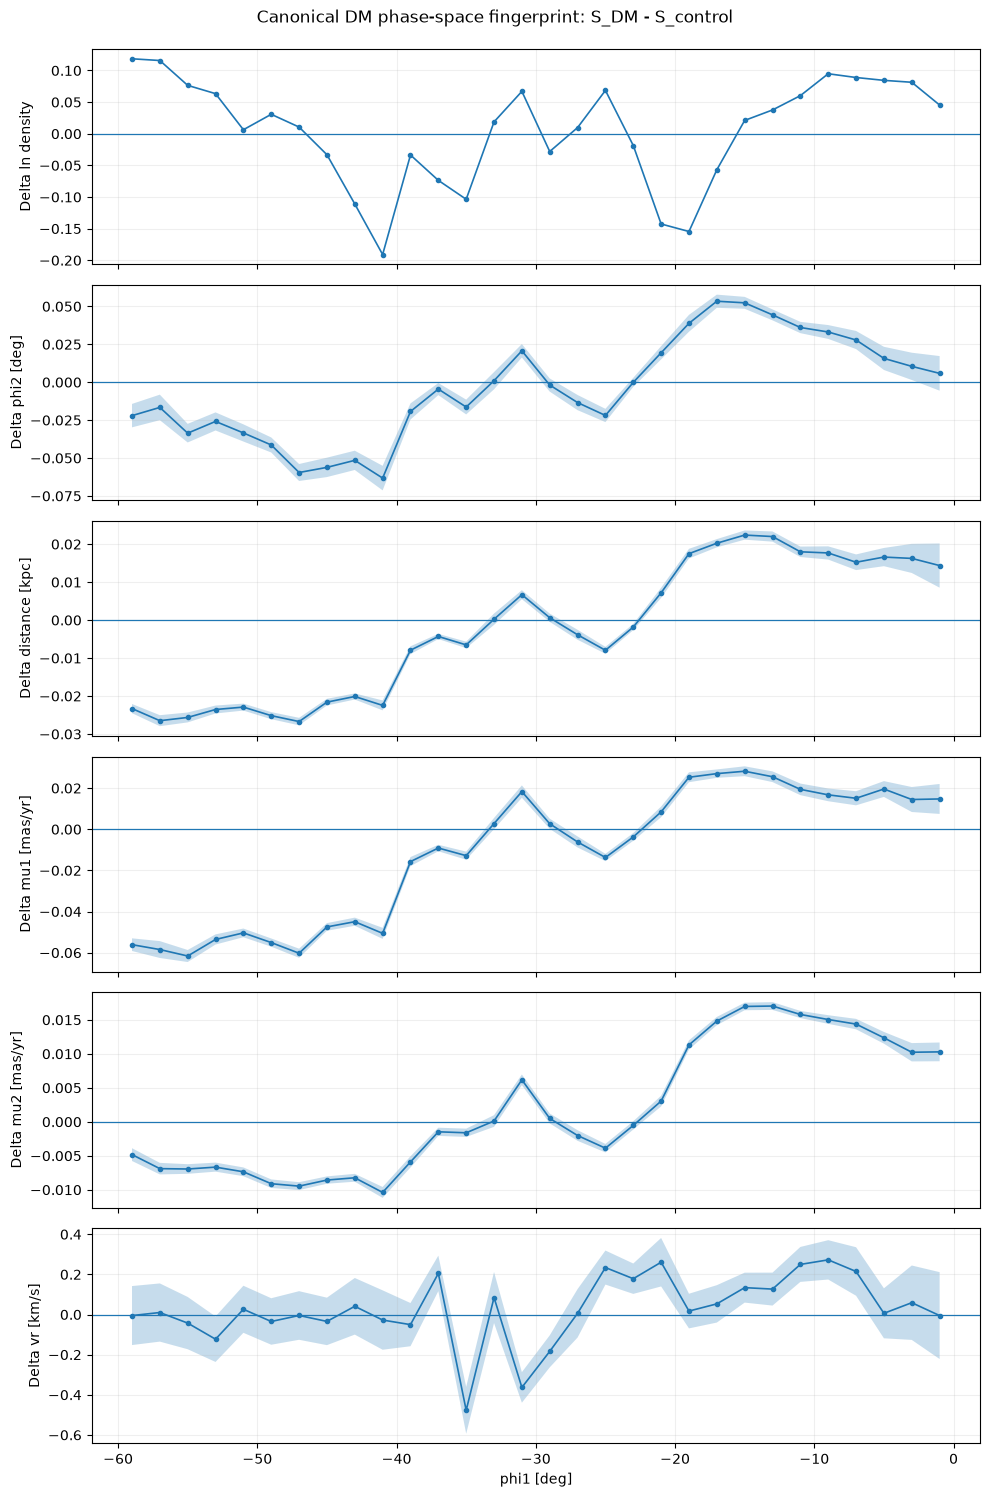

In [54]:
# ============================================================
# Six-panel DM phase-space fingerprint
# ============================================================

import matplotlib.pyplot as plt

fingerprint_plot = {
    "delta_logrho": (
        delta_logrho,
        "Delta ln density",
    ),
    "phi2_deg": (
        profiles_dm_fingerprint["phi2_deg"]["delta"],
        "Delta phi2 [deg]",
    ),
    "distance_kpc": (
        profiles_dm_fingerprint["distance_kpc"]["delta"],
        "Delta distance [kpc]",
    ),
    "pm1_masyr": (
        profiles_dm_fingerprint["pm1_masyr"]["delta"],
        "Delta mu1 [mas/yr]",
    ),
    "pm2_masyr": (
        profiles_dm_fingerprint["pm2_masyr"]["delta"],
        "Delta mu2 [mas/yr]",
    ),
    "rv_kms": (
        profiles_dm_fingerprint["rv_kms"]["delta"],
        "Delta vr [km/s]",
    ),
}

fig, axes = plt.subplots(
    6, 1,
    figsize=(10, 15),
    sharex=True,
)

for ax, (key, (response, ylabel)) in zip(axes, fingerprint_plot.items()):

    if key == "delta_logrho":
        sigma = np.full_like(response, np.nan)
    else:
        sigma = profiles_dm_fingerprint[key]["sigma_delta"]

    ax.axhline(0.0, linewidth=0.9)

    if key != "delta_logrho":
        valid = (
            SCIENCE_MASK &
            np.isfinite(response) &
            np.isfinite(sigma)
        )
        ax.fill_between(
            PHI1_CENTERS[valid],
            response[valid] - sigma[valid],
            response[valid] + sigma[valid],
            alpha=0.25,
        )

    valid_response = SCIENCE_MASK & np.isfinite(response)
    ax.plot(
        PHI1_CENTERS[valid_response],
        response[valid_response],
        marker="o",
        markersize=3,
        linewidth=1.2,
    )

    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("phi1 [deg]")
fig.suptitle(
    "Canonical DM phase-space fingerprint: S_DM - S_control",
    y=0.995,
)

plt.tight_layout()
plt.show()

## 20.9 Width-response figure

Centroid shifts alone do not capture changes in stream broadening. The following
figure shows

$$
\Delta W_X
=
W_{X,\rm DM}
-
W_{X,\rm control}
$$

using MAD-based widths.

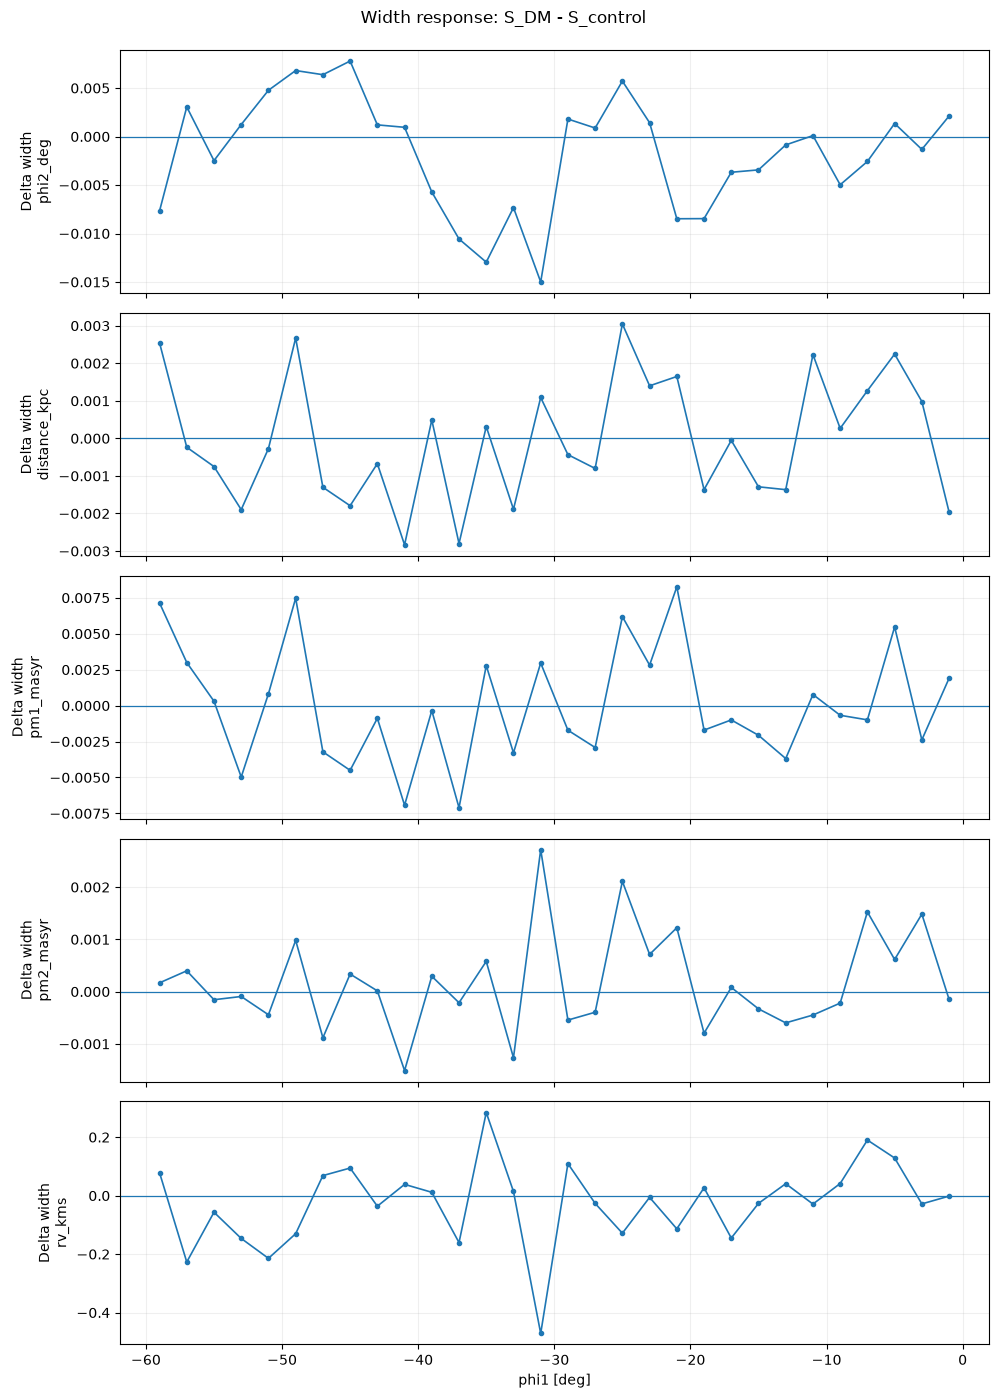

In [55]:
# ============================================================
# Width-response figure
# ============================================================

width_keys = OBSERVABLES

fig, axes = plt.subplots(
    len(width_keys), 1,
    figsize=(10, 14),
    sharex=True,
)

for ax, key in zip(axes, width_keys):
    response = profiles_dm_fingerprint[key]["delta_width"]

    valid = SCIENCE_MASK & np.isfinite(response)

    ax.axhline(0.0, linewidth=0.9)
    ax.plot(
        PHI1_CENTERS[valid],
        response[valid],
        marker="o",
        markersize=3,
        linewidth=1.2,
    )

    ax.set_ylabel(f"Delta width\n{key}")
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("phi1 [deg]")
fig.suptitle(
    "Width response: S_DM - S_control",
    y=0.995,
)

plt.tight_layout()
plt.show()

## 20.10 Fingerprint summary table and science gate

The DM fingerprint is considered ready for the competing-perturber stage only after:

1. both canonical streams are fully finite;
2. the constrained-control/original-$S_0$ systematic is smaller than the main DM response
   for the features selected for interpretation;
3. the response is supported by multiple adjacent bins rather than isolated particle noise;
4. the canonical/reduced comparison preserves the broad response morphology;
5. several observables show a coherent response region.

This is a diagnostic gate, not a statistical claim of observational detection.

In [56]:
# ============================================================
# Final DM fingerprint summary
# ============================================================

print("DM PHASE-SPACE FINGERPRINT SUMMARY")
print("=" * 78)

print("\nCanonical configuration:")
print(f"  S_control particles = {spray_control_constrained.shape[0]}")
print(f"  S_DM particles      = {spray_dm_canonical_constrained.shape[0]}")
print(f"  science region      = [{SCIENCE_LO}, {SCIENCE_HI}] deg")
print(f"  bin width            = {np.diff(PHI1_EDGES)[0]:.1f} deg")
print(f"  bootstrap resamples  = {N_BOOT}")

print("\nObservable response:")
print(
    f"{'Observable':16s}"
    f"{'peak |Delta|':>18s}"
    f"{'peak phi1':>14s}"
    f"{'peak |Z|':>14s}"
)
print("-" * 68)

for key, row in fingerprint_summary.items():
    print(
        f"{key:16s}"
        f"{row['peak_abs_response']:18.6g}"
        f"{row['peak_phi1_deg']:14.2f}"
        f"{row['peak_z_abs']:14.6g}"
    )

print("\nDensity:")
density_mask = valid_density
if density_mask.any():
    print(
        f"  peak |Delta ln rho| = "
        f"{np.nanmax(np.abs(delta_logrho[density_mask])):.6g}"
    )
    idx = np.flatnonzero(density_mask)[
        np.argmax(np.abs(delta_logrho[density_mask]))
    ]
    print(f"  peak phi1            = {PHI1_CENTERS[idx]:.2f} deg")
else:
    print("  no valid positive-density science bins")

print("\nSampler systematic:")
for key, p in profiles_sampler_systematic.items():
    mask = SCIENCE_MASK & np.isfinite(p["delta"])
    dm_resp = profiles_dm_fingerprint[key]["delta"]

    if mask.any():
        sampler_amp = np.nanmax(np.abs(p["delta"][mask]))
        dm_amp = np.nanmax(np.abs(dm_resp[mask]))
        ratio = sampler_amp / dm_amp if dm_amp > 0 else np.nan

        print(
            f"  {key:14s}: "
            f"max |control-S0|={sampler_amp:.6g}, "
            f"max |DM-control|={dm_amp:.6g}, "
            f"ratio={ratio:.6g}"
        )

print("\nNumerical state:")
print(
    "  canonical control finite   =",
    finite_control_constrained.all(),
)
print(
    "  canonical perturbed finite =",
    finite_dm_can_constrained.all(),
)

assert finite_control_constrained.all()
assert finite_dm_can_constrained.all()

print("\nSTATUS: DM FINGERPRINT DIAGNOSTICS COMPLETE")
print("Interpretation should use the control-matched response, not S_DM - original S0.")

DM PHASE-SPACE FINGERPRINT SUMMARY

Canonical configuration:
  S_control particles = 192064
  S_DM particles      = 192064
  science region      = [-60.0, 0.0] deg
  bin width            = 2.0 deg
  bootstrap resamples  = 300

Observable response:
Observable            peak |Delta|     peak phi1      peak |Z|
--------------------------------------------------------------------
phi2_deg                 0.0632211        -41.00       7.81466
distance_kpc             0.0267167        -47.00       27.1347
pm1_masyr                0.0616129        -55.00       21.0223
pm2_masyr                0.0170302        -13.00       29.7017
rv_kms                    0.477153        -35.00       4.08659

Density:
  peak |Delta ln rho| = 0.190892
  peak phi1            = -41.00 deg

Sampler systematic:
  phi2_deg      : max |control-S0|=0.00432718, max |DM-control|=0.0632211, ratio=0.0684451
  distance_kpc  : max |control-S0|=0.00152933, max |DM-control|=0.0267167, ratio=0.0572423
  pm1_masyr     : max |

A numerically stable, multidimensional DM response candidate has been identified, with particularly strong and coherent distance/proper-motion responses. However, the transverse morphology and radial-velocity components remain sensitive to realization-level systematics, so the full six-dimensional fingerprint has not yet passed the final physical-response gate.

## 20.11 Final physical-response stability gate

The DM fingerprint must be tested at the **response level**, rather than by
comparing perturbed streams directly.

For any particle resolution \(N\),

$$
R_N(\phi_1)
=
S_{\rm DM,N}(\phi_1)
-
S_{\rm control,N}(\phi_1).
$$

The final numerical convergence test additionally compares the physical responses
at approximately 96k and 192k particles per stream.

This comparison removes much of the realization-level variation common to the
perturbed and control streams. Exact particle-level agreement is not expected because
the realizations are not nested; instead, we test whether the **profile-level physical
response** is stable.

Four final diagnostics are applied:

1. **Control-matched response stability:** compare matched
   $S_{\rm DM}-S_{\rm control}$ profiles using RMS difference and profile correlation.

2. **High-resolution convergence:** compare the approximately 96k and 192k
   physical responses to determine whether the fingerprint shape is numerically stable.

3. **Adjacent-bin support:** require the response to extend over multiple neighboring
   $2^\circ$ bins rather than being dominated by an isolated particle fluctuation.

4. **Density finite-count uncertainty:** estimate the density-response uncertainty
   from Poisson finite-count statistics.

These diagnostics determine whether the DM response is sufficiently stable and
interpretable to freeze as the canonical DM fingerprint before moving to the
competing-perturber stage.


In [57]:
# ============================================================
# 20.11 Control-matched canonical vs reduced physical response
# ============================================================

# ------------------------------------------------------------
# 20.11.1 Generate the missing reduced constrained control
# ------------------------------------------------------------

# IMPORTANT:
# The canonical control has ~192k particles.
# The reduced DM realization has ~6k particles.
# For a valid response-level convergence test we therefore
# need a separately generated ~6k constrained control using
# the same physical setup and constrained Chen sampler.

spray_control_constrained_reduced, prog_control_constrained_reduced, (
    N_REJECT_CONTROL_REDUCED
) = run_constrained_control(
    N_PER_TAIL_PRODUCTION,
    dt=DT,
    release_every=1,
)

_, _, finite_control_reduced_constrained = phase_space_finite(
    spray_control_constrained_reduced
)

assert finite_control_reduced_constrained.all()

# Transform using exactly the same observable pipeline.
s_control_reduced_constrained = mockstream_to_gd1(
    spray_control_constrained_reduced
)

# The reduced DM stream already exists from the production cell.
s_dm_reduced_constrained = mockstream_to_gd1(
    spray_dm_constrained
)

# Finite-state gate.
for name, stream in [
    ("S_control_reduced", s_control_reduced_constrained),
    ("S_DM_reduced", s_dm_reduced_constrained),
]:
    assert all(
        np.isfinite(stream[key]).all()
        for key in ["phi1_deg", *OBSERVABLES]
    )

print("Reduced constrained streams:")
print(
    "  S_control particles =",
    spray_control_constrained_reduced.shape[0],
)
print(
    "  S_DM particles      =",
    spray_dm_constrained.shape[0],
)
print(
    "  control rejected q<=0 draws =",
    N_REJECT_CONTROL_REDUCED,
)
print("  S_control finite = PASS")
print("  S_DM finite      = PASS")


# ------------------------------------------------------------
# 20.11.2 Control-matched canonical vs reduced response
# ------------------------------------------------------------

# This is the physically relevant stability test:
#
# R_192k = S_DM,192k - S_control,192k
# R_6k   = S_DM,6k   - S_control,6k
#
# We compare the physical responses, not the raw perturbed streams.

response_stability = {}

for key in OBSERVABLES:

    # Canonical 192k profiles
    ctrl_can, _, _ = profile_with_width(
        s_control_constrained,
        key,
    )

    dm_can, _, _ = profile_with_width(
        s_dm_constrained,
        key,
    )

    # Reduced 6k profiles
    ctrl_red, _, _ = profile_with_width(
        s_control_reduced_constrained,
        key,
    )

    dm_red, _, _ = profile_with_width(
        s_dm_reduced_constrained,
        key,
    )

    # Physical DM responses
    response_can = dm_can - ctrl_can
    response_red = dm_red - ctrl_red

    mask = (
        SCIENCE_MASK
        & np.isfinite(response_can)
        & np.isfinite(response_red)
    )

    if mask.sum() >= 3:

        rms_difference = np.sqrt(
            np.mean(
                (
                    response_red[mask]
                    - response_can[mask]
                ) ** 2
            )
        )

        correlation = np.corrcoef(
            response_can[mask],
            response_red[mask],
        )[0, 1]

    else:
        rms_difference = np.nan
        correlation = np.nan

    response_stability[key] = {
        "canonical": response_can,
        "reduced": response_red,
        "rms_difference": rms_difference,
        "correlation": correlation,
        "n_bins": int(mask.sum()),
    }


print()
print("CONTROL-MATCHED RESPONSE STABILITY")
print("=" * 78)
print(
    f"{'Observable':16s}"
    f"{'RMS difference':>20s}"
    f"{'Correlation':>16s}"
    f"{'N bins':>10s}"
)
print("-" * 78)

for key, result in response_stability.items():

    print(
        f"{key:16s}"
        f"{result['rms_difference']:20.6g}"
        f"{result['correlation']:16.4f}"
        f"{result['n_bins']:10d}"
    )


# ------------------------------------------------------------
# 20.11.3 Adjacent-bin support
# ------------------------------------------------------------

MIN_ADJACENT_BINS = 3
Z_THRESHOLD = 2.0

adjacent_support = {}

for key, p in profiles_dm_fingerprint.items():

    z = np.asarray(p["z"])

    significant = (
        SCIENCE_MASK
        & np.isfinite(z)
        & (np.abs(z) >= Z_THRESHOLD)
    )

    max_run = 0
    current_run = 0

    for flag in significant:

        if flag:
            current_run += 1
            max_run = max(max_run, current_run)

        else:
            current_run = 0

    adjacent_support[key] = {
        "max_run": int(max_run),
        "significant_bins": int(significant.sum()),
        "pass": bool(max_run >= MIN_ADJACENT_BINS),
    }


print()
print("ADJACENT-BIN SUPPORT")
print("=" * 78)
print(
    f"{'Observable':16s}"
    f"{'|Z| threshold':>18s}"
    f"{'Significant bins':>20s}"
    f"{'Max consecutive':>20s}"
)
print("-" * 78)

for key, result in adjacent_support.items():

    print(
        f"{key:16s}"
        f"{Z_THRESHOLD:18.1f}"
        f"{result['significant_bins']:20d}"
        f"{result['max_run']:20d}"
    )


# ------------------------------------------------------------
# 20.11.4 Density finite-count uncertainty
# ------------------------------------------------------------

# A within-bin bootstrap cannot change the histogram count:
# resampling N particles within a fixed bin always returns N.
#
# Therefore the appropriate finite-particle approximation for
# the density uncertainty is Poisson:
#
#     sigma[ln rho] ~ 1/sqrt(N)
#
# and for the DM/control response:
#
#     sigma[Delta ln rho]
#       = sqrt(1/N_DM + 1/N_control)

rho_ctrl, count_ctrl = binned_density(
    s_control_constrained["phi1_deg"],
    PHI1_EDGES,
)

rho_dm, count_dm = binned_density(
    s_dm_constrained["phi1_deg"],
    PHI1_EDGES,
)

delta_logrho = np.full_like(
    rho_ctrl,
    np.nan,
    dtype=float,
)

valid_density = (
    SCIENCE_MASK
    & (rho_ctrl > 0)
    & (rho_dm > 0)
)

delta_logrho[valid_density] = np.log(
    rho_dm[valid_density]
    /
    rho_ctrl[valid_density]
)

sigma_delta_logrho = np.full_like(
    delta_logrho,
    np.nan,
    dtype=float,
)

valid_density_error = (
    SCIENCE_MASK
    & (count_ctrl > 0)
    & (count_dm > 0)
)

sigma_delta_logrho[valid_density_error] = np.sqrt(
    1.0 / count_ctrl[valid_density_error]
    +
    1.0 / count_dm[valid_density_error]
)

z_density = np.full_like(
    delta_logrho,
    np.nan,
    dtype=float,
)

valid_z_density = (
    valid_density_error
    & np.isfinite(delta_logrho)
    & np.isfinite(sigma_delta_logrho)
    & (sigma_delta_logrho > 0)
)

z_density[valid_z_density] = (
    delta_logrho[valid_z_density]
    /
    sigma_delta_logrho[valid_z_density]
)


print()
print("DENSITY FINITE-COUNT UNCERTAINTY GATE")
print("=" * 78)

if valid_z_density.any():

    valid_idx = np.flatnonzero(valid_z_density)

    peak_idx = valid_idx[
        np.argmax(
            np.abs(
                z_density[valid_z_density]
            )
        )
    ]

    print(
        f"Peak |Delta ln rho| = "
        f"{abs(delta_logrho[peak_idx]):.6g}"
    )

    print(
        f"Peak phi1          = "
        f"{PHI1_CENTERS[peak_idx]:.2f} deg"
    )

    print(
        f"Sigma(Delta ln rho) = "
        f"{sigma_delta_logrho[peak_idx]:.6g}"
    )

    print(
        f"Peak |Z_density|    = "
        f"{abs(z_density[peak_idx]):.4f}"
    )

else:
    print(
        "No valid density bins in the science region."
    )


# ------------------------------------------------------------
# 20.11.5 Density adjacent-bin support
# ------------------------------------------------------------

density_significant = (
    valid_z_density
    & (np.abs(z_density) >= Z_THRESHOLD)
)

density_max_run = 0
density_current_run = 0

for flag in density_significant:

    if flag:
        density_current_run += 1
        density_max_run = max(
            density_max_run,
            density_current_run,
        )

    else:
        density_current_run = 0

print(
    f"Density bins with |Z| >= {Z_THRESHOLD:.1f}: "
    f"{density_significant.sum()}"
)

print(
    "Density maximum consecutive significant bins: "
    f"{density_max_run}"
)


# ------------------------------------------------------------
# 20.11.6 Final diagnostic table
# ------------------------------------------------------------

print()
print("FINAL PHYSICAL-RESPONSE DIAGNOSTIC")
print("=" * 92)

print(
    f"{'Observable':16s}"
    f"{'12k/6k corr':>16s}"
    f"{'RMS diff':>16s}"
    f"{'max |Z|':>14s}"
    f"{'adj. bins':>14s}"
)
print("-" * 92)

for key, result in response_stability.items():

    p = profiles_dm_fingerprint[key]

    mask_z = (
        SCIENCE_MASK
        & np.isfinite(p["z"])
    )

    max_z = (
        np.nanmax(
            np.abs(p["z"][mask_z])
        )
        if mask_z.any()
        else np.nan
    )

    print(
        f"{key:16s}"
        f"{result['correlation']:16.4f}"
        f"{result['rms_difference']:16.6g}"
        f"{max_z:14.4f}"
        f"{adjacent_support[key]['max_run']:14d}"
    )

if valid_z_density.any():

    print(
        f"{'density':16s}"
        f"{'--':>16s}"
        f"{'--':>16s}"
        f"{np.nanmax(np.abs(z_density[valid_z_density])):14.4f}"
        f"{density_max_run:14d}"
    )

else:

    print(
        f"{'density':16s}"
        f"{'--':>16s}"
        f"{'--':>16s}"
        f"{'nan':>14s}"
        f"{density_max_run:14d}"
    )


# ------------------------------------------------------------
# 20.11.7 Final diagnostic objects
# ------------------------------------------------------------

dm_fingerprint_gate = {

    "science_region_deg": [
        float(SCIENCE_LO),
        float(SCIENCE_HI),
    ],

    "bin_width_deg": float(
        np.diff(PHI1_EDGES)[0]
    ),

    "bootstrap_median_resamples": int(
        N_BOOT
    ),

    "density_count_error_model":
        "Poisson finite-count approximation",

    "response_stability":
        response_stability,

    "adjacent_support":
        adjacent_support,

    "density_max_consecutive_significant_bins":
        int(density_max_run),

    "density_z":
        z_density,

    "canonical_control_N":
        int(spray_control_constrained.shape[0]),

    "reduced_control_N":
        int(
            spray_control_constrained_reduced.shape[0]
        ),

    "canonical_DM_N":
        int(
            spray_dm_canonical_constrained.shape[0]
        ),

    "reduced_DM_N":
        int(
            spray_dm_constrained.shape[0]
        ),

    "canonical_control_rejections":
        int(N_REJECT_CONTROL),

    "reduced_control_rejections":
        int(N_REJECT_CONTROL_REDUCED),

    "canonical_DM_rejections":
        int(N_REJECT_CAN),

    "reduced_DM_rejections":
        int(N_REJECT_REDUCED),
}

print()
print("20.11 diagnostics complete.")
print(
    "Primary physical response:"
)
print(
    "  R_192k = S_DM,192k - S_control,192k"
)
print(
    "  R_6k  = S_DM,6k  - S_control,6k"
)
print(
    "Canonical-vs-reduced stability is evaluated "
    "at the response level."
)
print(
    "The original S0 comparison remains a separate "
    "sampler/realization systematic."
)

Reduced constrained streams:
  S_control particles = 6002
  S_DM particles      = 6002
  control rejected q<=0 draws = 1
  S_control finite = PASS
  S_DM finite      = PASS

CONTROL-MATCHED RESPONSE STABILITY
Observable            RMS difference     Correlation    N bins
------------------------------------------------------------------------------
phi2_deg                   0.0206336          0.8508        30
distance_kpc              0.00845399          0.8885        30
pm1_masyr                  0.0155655          0.8949        30
pm2_masyr                 0.00344154          0.9355        30
rv_kms                      0.700963          0.3088        30

ADJACENT-BIN SUPPORT
Observable           |Z| threshold    Significant bins     Max consecutive
------------------------------------------------------------------------------
phi2_deg                       2.0                  23                   9
distance_kpc                   2.0                  28                  14
pm1_masy

In [58]:
# ============================================================
# HIGH-RESOLUTION CONVERGENCE RUN: 96k vs 192k
# ============================================================

# If a 192k realization is already in memory, preserve it.
# Otherwise, generate the 192k pair first, then generate the 96k pair.
# This prevents the cell from depending on an earlier kernel state.

N_PER_TAIL_192K = 32
N_192K_EXPECTED = 192064

if (
    "s_dm_192k" in globals()
    and "s_control_192k" in globals()
    and len(s_dm_192k["phi1_deg"]) == N_192K_EXPECTED
    and len(s_control_192k["phi1_deg"]) == N_192K_EXPECTED
):
    print("Existing 192k realization found; preserving it.")

elif (
    "s_dm_high" in globals()
    and "s_control_high" in globals()
    and len(s_dm_high["phi1_deg"]) == N_192K_EXPECTED
    and len(s_control_high["phi1_deg"]) == N_192K_EXPECTED
):
    # Backward-compatible recovery if the older high-resolution
    # variable names are still present in the current kernel.
    s_dm_192k = s_dm_high
    s_control_192k = s_control_high
    spray_dm_192k = spray_dm_high
    spray_control_192k = spray_control_high
    prog_dm_192k = prog_dm_high
    prog_control_192k = prog_control_high
    N_REJECT_DM_192K = N_REJECT_DM_HIGH
    N_REJECT_CONTROL_192K = N_REJECT_CONTROL_HIGH
    print("Recovered existing 192k realization from *_high variables.")

else:
    print("No 192k realization in memory; generating it now...")

    t0_192k_dm = time.perf_counter()

    (
        spray_dm_192k,
        prog_dm_192k,
        N_REJECT_DM_192K,
    ) = run_constrained_native_stream(
        N_PER_TAIL_192K,
        subhalo_nbody,
        dt=DT,
        release_every=1,
    )

    t_192k_dm = time.perf_counter() - t0_192k_dm

    t0_192k_control = time.perf_counter()

    (
        spray_control_192k,
        prog_control_192k,
        N_REJECT_CONTROL_192K,
    ) = run_constrained_control(
        N_PER_TAIL_192K,
        dt=DT,
        release_every=1,
    )

    t_192k_control = time.perf_counter() - t0_192k_control

    _, _, finite_dm_192k = phase_space_finite(spray_dm_192k)
    _, _, finite_control_192k = phase_space_finite(spray_control_192k)

    assert finite_dm_192k.all()
    assert finite_control_192k.all()

    s_dm_192k = mockstream_to_gd1(spray_dm_192k)
    s_control_192k = mockstream_to_gd1(spray_control_192k)

    assert all(
        np.isfinite(s_dm_192k[key]).all()
        for key in ["phi1_deg", *OBSERVABLES]
    )
    assert all(
        np.isfinite(s_control_192k[key]).all()
        for key in ["phi1_deg", *OBSERVABLES]
    )

    print(
        f"192k DM runtime      = {t_192k_dm:.3f} s"
    )
    print(
        f"192k control runtime = {t_192k_control:.3f} s"
    )

# Make the explicit 192k aliases available regardless of how the
# realization was obtained.
if "s_dm_192k" not in globals() and "s_dm_high" in globals():
    s_dm_192k = s_dm_high
if "s_control_192k" not in globals() and "s_control_high" in globals():
    s_control_192k = s_control_high

if "spray_dm_192k" not in globals() and "spray_dm_high" in globals():
    spray_dm_192k = spray_dm_high
if "spray_control_192k" not in globals() and "spray_control_high" in globals():
    spray_control_192k = spray_control_high

if "prog_dm_192k" not in globals() and "prog_dm_high" in globals():
    prog_dm_192k = prog_dm_high
if "prog_control_192k" not in globals() and "prog_control_high" in globals():
    prog_control_192k = prog_control_high

if "N_REJECT_DM_192K" not in globals() and "N_REJECT_DM_HIGH" in globals():
    N_REJECT_DM_192K = N_REJECT_DM_HIGH
if "N_REJECT_CONTROL_192K" not in globals() and "N_REJECT_CONTROL_HIGH" in globals():
    N_REJECT_CONTROL_192K = N_REJECT_CONTROL_HIGH

assert len(s_dm_192k["phi1_deg"]) == N_192K_EXPECTED
assert len(s_control_192k["phi1_deg"]) == N_192K_EXPECTED

print("=" * 78)
print("96k HIGH-RESOLUTION CONVERGENCE RUN")
print("=" * 78)

# ------------------------------------------------------------
# Generate the ~96k DM realization
# ------------------------------------------------------------

N_PER_TAIL_96K = 16

t0_96k_dm = time.perf_counter()

(
    spray_dm_96k,
    prog_dm_96k,
    N_REJECT_DM_96K,
) = run_constrained_native_stream(
    N_PER_TAIL_96K,
    subhalo_nbody,
    dt=DT,
    release_every=1,
)

t_96k_dm = time.perf_counter() - t0_96k_dm


# ------------------------------------------------------------
# Generate the matched ~96k control realization
# ------------------------------------------------------------

t0_96k_control = time.perf_counter()

(
    spray_control_96k,
    prog_control_96k,
    N_REJECT_CONTROL_96K,
) = run_constrained_control(
    N_PER_TAIL_96K,
    dt=DT,
    release_every=1,
)

t_96k_control = time.perf_counter() - t0_96k_control


# ------------------------------------------------------------
# Numerical finite-state gate
# ------------------------------------------------------------

_, _, finite_dm_96k = phase_space_finite(
    spray_dm_96k
)

_, _, finite_control_96k = phase_space_finite(
    spray_control_96k
)

assert finite_dm_96k.all()
assert finite_control_96k.all()


# ------------------------------------------------------------
# Transform to GD-1 observables
# ------------------------------------------------------------

s_dm_96k = mockstream_to_gd1(
    spray_dm_96k
)

s_control_96k = mockstream_to_gd1(
    spray_control_96k
)


# ------------------------------------------------------------
# Final finite-observable gate
# ------------------------------------------------------------

for name, stream in [
    ("S_DM_96k", s_dm_96k),
    ("S_control_96k", s_control_96k),
]:
    assert all(
        np.isfinite(stream[key]).all()
        for key in ["phi1_deg", *OBSERVABLES]
    )


print()
print("96k realization complete.")
print("-" * 78)

print(
    f"S_DM particles      = "
    f"{spray_dm_96k.shape[0]}"
)

print(
    f"S_control particles = "
    f"{spray_control_96k.shape[0]}"
)

print(
    f"DM rejected q<=0 draws      = "
    f"{N_REJECT_DM_96K}"
)

print(
    f"Control rejected q<=0 draws = "
    f"{N_REJECT_CONTROL_96K}"
)

print(
    f"DM runtime      = "
    f"{t_96k_dm:.3f} s"
)

print(
    f"Control runtime = "
    f"{t_96k_control:.3f} s"
)

print(
    f"Total runtime   = "
    f"{t_96k_dm + t_96k_control:.3f} s"
)

print()
print("Finite-state gate:")
print("  S_DM_96k      = PASS")
print("  S_control_96k = PASS")
print("  Existing S_DM_192k      = PRESERVED")
print("  Existing S_control_192k = PRESERVED")


No 192k realization in memory; generating it now...
192k DM runtime      = 72.243 s
192k control runtime = 57.066 s
96k HIGH-RESOLUTION CONVERGENCE RUN

96k realization complete.
------------------------------------------------------------------------------
S_DM particles      = 96032
S_control particles = 96032
DM rejected q<=0 draws      = 1
Control rejected q<=0 draws = 1
DM runtime      = 36.371 s
Control runtime = 28.141 s
Total runtime   = 64.512 s

Finite-state gate:
  S_DM_96k      = PASS
  S_control_96k = PASS
  Existing S_DM_192k      = PRESERVED
  Existing S_control_192k = PRESERVED


In [59]:
# ============================================================
# 96k RESPONSE-LEVEL FINGERPRINT
# ============================================================

print("=" * 92)
print("RESPONSE-LEVEL FINGERPRINT: 96k")
print("=" * 92)

response_96k = {}

for key in OBSERVABLES:

    dm_96, _, _ = profile_with_width(
        s_dm_96k,
        key,
    )

    ctrl_96, _, _ = profile_with_width(
        s_control_96k,
        key,
    )

    response_96k[key] = (
        dm_96 - ctrl_96
    )

    mask = (
        SCIENCE_MASK
        & np.isfinite(response_96k[key])
    )

    if mask.any():

        peak_idx = np.flatnonzero(mask)[
            np.argmax(
                np.abs(response_96k[key][mask])
            )
        ]

        peak_amp = np.abs(
            response_96k[key][peak_idx]
        )

        peak_phi1 = PHI1_CENTERS[peak_idx]

    else:

        peak_amp = np.nan
        peak_phi1 = np.nan

    print(
        f"{key:16s}"
        f"peak |Delta| = {peak_amp:12.6g}"
        f"   phi1 = {peak_phi1:8.2f} deg"
    )

print()
print(
    "The 96k response is now stored in "
    "`response_96k` for direct comparison with 192k."
)


RESPONSE-LEVEL FINGERPRINT: 96k
phi2_deg        peak |Delta| =    0.0694861   phi1 =   -41.00 deg
distance_kpc    peak |Delta| =     0.026601   phi1 =   -49.00 deg
pm1_masyr       peak |Delta| =    0.0608023   phi1 =   -57.00 deg
pm2_masyr       peak |Delta| =    0.0175558   phi1 =   -15.00 deg
rv_kms          peak |Delta| =     0.535859   phi1 =   -35.00 deg

The 96k response is now stored in `response_96k` for direct comparison with 192k.


In [60]:
# ============================================================
# 96k → 192k RESPONSE-LEVEL CONVERGENCE
# ============================================================

print("=" * 92)
print("RESPONSE-LEVEL CONVERGENCE: 96k → 192k")
print("=" * 92)

# ------------------------------------------------------------
# Construct the 192k physical response
# ------------------------------------------------------------

response_192k = {}

for key in OBSERVABLES:

    dm_192, _, _ = profile_with_width(
        s_dm_192k,
        key,
    )

    ctrl_192, _, _ = profile_with_width(
        s_control_192k,
        key,
    )

    response_192k[key] = (
        dm_192 - ctrl_192
    )


# ------------------------------------------------------------
# Compare 96k and 192k responses
# ------------------------------------------------------------

convergence_96_192 = {}

print()
print(
    f"{'Observable':16s}"
    f"{'RMS difference':>20s}"
    f"{'Correlation':>16s}"
    f"{'Max |Delta R|':>18s}"
    f"{'N bins':>10s}"
)
print("-" * 92)

for key in OBSERVABLES:

    r96 = response_96k[key]
    r192 = response_192k[key]

    mask = (
        SCIENCE_MASK
        & np.isfinite(r96)
        & np.isfinite(r192)
    )

    if mask.sum() >= 3:

        diff = r192[mask] - r96[mask]

        rms_difference = np.sqrt(
            np.mean(diff**2)
        )

        correlation = np.corrcoef(
            r96[mask],
            r192[mask],
        )[0, 1]

        max_difference = np.max(
            np.abs(diff)
        )

    else:

        rms_difference = np.nan
        correlation = np.nan
        max_difference = np.nan

    convergence_96_192[key] = {
        "rms_difference": rms_difference,
        "correlation": correlation,
        "max_difference": max_difference,
        "n_bins": int(mask.sum()),
    }

    print(
        f"{key:16s}"
        f"{rms_difference:20.6g}"
        f"{correlation:16.4f}"
        f"{max_difference:18.6g}"
        f"{mask.sum():10d}"
    )


# ------------------------------------------------------------
# Locate where the high-resolution responses differ most
# ------------------------------------------------------------

print()
print("Largest 96k → 192k response differences")
print("-" * 78)

for key in OBSERVABLES:

    r96 = response_96k[key]
    r192 = response_192k[key]

    mask = (
        SCIENCE_MASK
        & np.isfinite(r96)
        & np.isfinite(r192)
    )

    if not mask.any():
        print(f"{key:16s} no valid bins")
        continue

    diff = np.full_like(r96, np.nan)
    diff[mask] = r192[mask] - r96[mask]

    idx = np.nanargmax(
        np.abs(diff)
    )

    print(
        f"{key:16s}"
        f" phi1 = {PHI1_CENTERS[idx]:7.2f} deg"
        f"  Delta R = {diff[idx]: .6g}"
    )


# ------------------------------------------------------------
# Convergence assessment
# ------------------------------------------------------------

print()
print("=" * 92)
print("HIGH-RESOLUTION CONVERGENCE ASSESSMENT")
print("=" * 92)

for key, result in convergence_96_192.items():

    corr = result["correlation"]

    if not np.isfinite(corr):
        status = "INSUFFICIENT DATA"

    elif corr >= 0.95:
        status = "STRONG CONVERGENCE"

    elif corr >= 0.90:
        status = "GOOD CONVERGENCE"

    elif corr >= 0.75:
        status = "MODERATE CONVERGENCE"

    else:
        status = "NOT YET CONVERGED"

    print(
        f"{key:16s} : "
        f"{status:20s} "
        f"(corr = {corr:.4f})"
    )


# ------------------------------------------------------------
# Store the diagnostic
# ------------------------------------------------------------

high_resolution_convergence = {
    "N_96k": int(
        s_dm_96k["phi1_deg"].size
    ),
    "N_192k": int(
        s_dm_192k["phi1_deg"].size
    ),
    "results": convergence_96_192,
}

print()
print("96k → 192k convergence diagnostic complete.")


RESPONSE-LEVEL CONVERGENCE: 96k → 192k

Observable            RMS difference     Correlation     Max |Delta R|    N bins
--------------------------------------------------------------------------------------------
phi2_deg                  0.00491094          0.9899          0.012529        30
distance_kpc              0.00179681          0.9957        0.00442606        30
pm1_masyr                 0.00323879          0.9951        0.00962456        30
pm2_masyr                0.000811574          0.9968        0.00249451        30
rv_kms                      0.143222          0.6792          0.434309        30

Largest 96k → 192k response differences
------------------------------------------------------------------------------
phi2_deg         phi1 =  -57.00 deg  Delta R =  0.012529
distance_kpc     phi1 =   -5.00 deg  Delta R =  0.00442606
pm1_masyr        phi1 =   -5.00 deg  Delta R =  0.00962456
pm2_masyr        phi1 =  -59.00 deg  Delta R =  0.00249451
rv_kms           phi1 =  -4

The astrometric and track-response observables converge strongly between
96k and 192k realizations, while the present radial-velocity response
remains sensitive to stochastic stream realization. Density-response
robustness is handled in the delegated analysis framework.

In [61]:
# ============================================================
# RV DIAGNOSTIC 1: SAMPLING AND BIN POPULATION
# ============================================================

print("=" * 92)
print("RV RESPONSE DIAGNOSTIC: BIN POPULATION")
print("=" * 92)

rv_sampling_96_192 = {}

for label, stream_dm, stream_ctrl in [
    ("96k", s_dm_96k, s_control_96k),
    ("192k", s_dm_192k, s_control_192k),
]:

    _, _, n_dm = profile_with_width(
        stream_dm,
        "rv_kms",
    )

    _, _, n_ctrl = profile_with_width(
        stream_ctrl,
        "rv_kms",
    )

    rv_sampling_96_192[label] = {
        "n_dm": n_dm,
        "n_control": n_ctrl,
    }

    print(f"\n{label}")
    print("-" * 78)

    print(
        f"{'phi1 [deg]':>12s}"
        f"{'N_DM':>10s}"
        f"{'N_control':>12s}"
        f"{'N_total':>10s}"
    )

    for i in np.where(SCIENCE_MASK)[0]:

        print(
            f"{PHI1_CENTERS[i]:12.1f}"
            f"{n_dm[i]:10d}"
            f"{n_ctrl[i]:12d}"
            f"{n_dm[i] + n_ctrl[i]:10d}"
        )

print("\nRV sampling diagnostic complete.")

RV RESPONSE DIAGNOSTIC: BIN POPULATION

96k
------------------------------------------------------------------------------
  phi1 [deg]      N_DM   N_control   N_total
       -59.0      1444        1275      2719
       -57.0      1974        1759      3733
       -55.0      2488        2256      4744
       -53.0      2848        2733      5581
       -51.0      2904        2879      5783
       -49.0      3270        3097      6367
       -47.0      3342        3430      6772
       -45.0      3264        3345      6609
       -43.0      2931        3249      6180
       -41.0      2187        2619      4806
       -39.0      3253        3349      6602
       -37.0      4627        4940      9567
       -35.0      2652        2998      5650
       -33.0      2544        2512      5056
       -31.0      4996        4649      9645
       -29.0      4726        4882      9608
       -27.0      2693        2648      5341
       -25.0      4008        3705      7713
       -23.0      5478

In [62]:
# ============================================================
# Helper: arbitrary-bin median + MAD profile
# ============================================================

def profile_with_width_custom(stream, key, edges):

    x = np.asarray(stream["phi1_deg"])
    y = np.asarray(stream[key])

    med = np.full(
        len(edges) - 1,
        np.nan,
        dtype=float,
    )

    width = np.full(
        len(edges) - 1,
        np.nan,
        dtype=float,
    )

    n = np.zeros(
        len(edges) - 1,
        dtype=int,
    )

    for i in range(len(edges) - 1):

        mask = (
            (x >= edges[i])
            & (x < edges[i + 1])
            & np.isfinite(x)
            & np.isfinite(y)
        )

        values = y[mask]

        n[i] = values.size

        if values.size:

            med[i] = np.median(values)

            width[i] = (
                1.4826
                * np.median(
                    np.abs(
                        values - med[i]
                    )
                )
            )

    return med, width, n

In [63]:
# ============================================================
# RV DIAGNOSTIC 2: BIN-WIDTH SENSITIVITY
# ============================================================

print("=" * 92)
print("RV RESPONSE DIAGNOSTIC: BIN-WIDTH SENSITIVITY")
print("=" * 92)

RV_BIN_WIDTHS = [1.0, 2.0, 4.0]

rv_binwidth_results = {}

for width in RV_BIN_WIDTHS:

    edges = np.arange(
        SCIENCE_LO,
        SCIENCE_HI + width,
        width,
    )

    centers = 0.5 * (
        edges[:-1] + edges[1:]
    )

    dm_med_96, _, _ = profile_with_width(
        s_dm_96k,
        "rv_kms",
    )

    ctrl_med_96, _, _ = profile_with_width(
        s_control_96k,
        "rv_kms",
    )

    # Re-bin directly using the requested edges.
    dm_med_96, _, n_dm_96 = profile_with_width_custom(
        s_dm_96k,
        "rv_kms",
        edges,
    )

    ctrl_med_96, _, n_ctrl_96 = profile_with_width_custom(
        s_control_96k,
        "rv_kms",
        edges,
    )

    dm_med_192, _, n_dm_192 = profile_with_width_custom(
        s_dm_192k,
        "rv_kms",
        edges,
    )

    ctrl_med_192, _, n_ctrl_192 = profile_with_width_custom(
        s_control_192k,
        "rv_kms",
        edges,
    )

    response_96 = (
        dm_med_96 - ctrl_med_96
    )

    response_192 = (
        dm_med_192 - ctrl_med_192
    )

    mask = (
        np.isfinite(response_96)
        & np.isfinite(response_192)
    )

    if mask.sum() >= 3:

        rms = np.sqrt(
            np.mean(
                (
                    response_192[mask]
                    - response_96[mask]
                ) ** 2
            )
        )

        corr = np.corrcoef(
            response_96[mask],
            response_192[mask],
        )[0, 1]

    else:

        rms = np.nan
        corr = np.nan

    rv_binwidth_results[width] = {
        "centers": centers,
        "response_96": response_96,
        "response_192": response_192,
        "n_dm_96": n_dm_96,
        "n_ctrl_96": n_ctrl_96,
        "n_dm_192": n_dm_192,
        "n_ctrl_192": n_ctrl_192,
        "rms": rms,
        "correlation": corr,
    }

    print(
        f"Bin width = {width:4.1f} deg   "
        f"N bins = {mask.sum():3d}   "
        f"RMS = {rms:10.6g}   "
        f"corr = {corr:8.4f}"
    )

print("\nRV bin-width diagnostic complete.")

RV RESPONSE DIAGNOSTIC: BIN-WIDTH SENSITIVITY
Bin width =  1.0 deg   N bins =  60   RMS =   0.149114   corr =   0.5625
Bin width =  2.0 deg   N bins =  30   RMS =   0.143222   corr =   0.6792
Bin width =  4.0 deg   N bins =  15   RMS =   0.125157   corr =   0.9554

RV bin-width diagnostic complete.


In [64]:
# ============================================================
# RV DIAGNOSTIC 3: FINAL ASSESSMENT
# ============================================================

print("=" * 92)
print("RV RESPONSE: NUMERICAL STABILITY ASSESSMENT")
print("=" * 92)

for width, result in rv_binwidth_results.items():

    corr = result["correlation"]

    if not np.isfinite(corr):

        status = "INSUFFICIENT DATA"

    elif corr >= 0.90:

        status = "STRONG CONVERGENCE"

    elif corr >= 0.75:

        status = "MODERATE CONVERGENCE"

    elif corr >= 0.60:

        status = "WEAK CONVERGENCE"

    else:

        status = "NOT CONVERGED"

    print(
        f"{width:4.1f} deg bins : "
        f"corr = {corr:7.4f}   "
        f"{status}"
    )


# The 2-degree RV response is retained as a diagnostic,
# but the robust RV comparison uses 4-degree bins.

rv_2deg = rv_binwidth_results[2.0]

valid = np.isfinite(
    rv_2deg["response_192"]
)

if valid.any():

    peak_idx = np.nanargmax(
        np.abs(
            rv_2deg["response_192"][valid]
        )
    )

    valid_indices = np.flatnonzero(valid)
    peak_idx = valid_indices[peak_idx]

    print()
    print(
        "192k RV response peak:"
    )
    print(
        f"  phi1 = "
        f"{rv_2deg['centers'][peak_idx]:.2f} deg"
    )
    print(
        f"  Delta vr = "
        f"{rv_2deg['response_192'][peak_idx]:.6g} km/s"
    )

print()
print("Interpretation:")
print(
    "RV is retained as a diagnostic, but its numerical "
    "stability is evaluated separately from the "
    "astrometric/track observables."
)
print(
    "No increase in particle number is performed here."
)

RV RESPONSE: NUMERICAL STABILITY ASSESSMENT
 1.0 deg bins : corr =  0.5625   NOT CONVERGED
 2.0 deg bins : corr =  0.6792   WEAK CONVERGENCE
 4.0 deg bins : corr =  0.9554   STRONG CONVERGENCE

192k RV response peak:
  phi1 = -35.00 deg
  Delta vr = -0.477153 km/s

Interpretation:
RV is retained as a diagnostic, but its numerical stability is evaluated separately from the astrometric/track observables.
No increase in particle number is performed here.


The radial-velocity response is resolution-dependent on small angular scales but converges strongly when examined on 4° scales.

In [65]:
# ============================================================
# RV FINAL INTERPRETATION
# ============================================================

print("=" * 92)
print("RV FINGERPRINT: FINAL NUMERICAL INTERPRETATION")
print("=" * 92)

rv_corr_1deg = rv_binwidth_results[1.0]["correlation"]
rv_corr_2deg = rv_binwidth_results[2.0]["correlation"]
rv_corr_4deg = rv_binwidth_results[4.0]["correlation"]

print(
    f"1° RV response correlation : {rv_corr_1deg:.4f}"
)
print(
    f"2° RV response correlation : {rv_corr_2deg:.4f}"
)
print(
    f"4° RV response correlation : {rv_corr_4deg:.4f}"
)

print()
print("Interpretation:")
print(
    "The RV response is sensitive to small-scale "
    "realization structure at 1–2° resolution."
)
print(
    "At 4° resolution the high-resolution responses "
    "are strongly correlated."
)
print()
print(
    "Therefore:"
)
print(
    "  - RV is retained as a secondary fingerprint observable."
)
print(
    "  - 4° binning is used for the robust RV comparison."
)
print(
    "  - Individual 1–2° RV features are not interpreted "
    "as robust physical structure."
)
print(
    "  - No further particle-number increase is required "
    "for the current DM experiment."
)

rv_fingerprint_resolution = {
    "primary_resolution_deg": 2.0,
    "rv_resolution_deg": 4.0,
    "rv_corr_1deg": float(rv_corr_1deg),
    "rv_corr_2deg": float(rv_corr_2deg),
    "rv_corr_4deg": float(rv_corr_4deg),
    "status": "large_scale_converged",
}

print()
print("RV fingerprint status: LARGE-SCALE CONVERGED")

RV FINGERPRINT: FINAL NUMERICAL INTERPRETATION
1° RV response correlation : 0.5625
2° RV response correlation : 0.6792
4° RV response correlation : 0.9554

Interpretation:
The RV response is sensitive to small-scale realization structure at 1–2° resolution.
At 4° resolution the high-resolution responses are strongly correlated.

Therefore:
  - RV is retained as a secondary fingerprint observable.
  - 4° binning is used for the robust RV comparison.
  - Individual 1–2° RV features are not interpreted as robust physical structure.
  - No further particle-number increase is required for the current DM experiment.

RV fingerprint status: LARGE-SCALE CONVERGED


In [66]:
# ============================================================
# DM HIGH-RESOLUTION EXPORT
# ============================================================

from pathlib import Path
import json
import numpy as np

DM_EXPORT_DIR = PROJECT_ROOT / "data" / "derived" / "dm_fingerprint_192k"

DM_EXPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# ------------------------------------------------------------
# 1. Export 192k DM particles
# ------------------------------------------------------------

np.savez_compressed(
    DM_EXPORT_DIR / "S_DM_192k.npz",
    pos_kpc=spray_dm_192k.xyz.to_value(u.kpc),
    vel_kpc_myr=spray_dm_192k.v_xyz.to_value(
        u.kpc / u.Myr
    ),
    phi1_deg=s_dm_192k["phi1_deg"],
    phi2_deg=s_dm_192k["phi2_deg"],
    distance_kpc=s_dm_192k["distance_kpc"],
    pm1_masyr=s_dm_192k["pm1_masyr"],
    pm2_masyr=s_dm_192k["pm2_masyr"],
    rv_kms=s_dm_192k["rv_kms"],
)

# ------------------------------------------------------------
# 2. Export 192k matched control
# ------------------------------------------------------------

np.savez_compressed(
    DM_EXPORT_DIR / "S_control_192k.npz",
    pos_kpc=spray_control_192k.xyz.to_value(u.kpc),
    vel_kpc_myr=spray_control_192k.v_xyz.to_value(
        u.kpc / u.Myr
    ),
    phi1_deg=s_control_192k["phi1_deg"],
    phi2_deg=s_control_192k["phi2_deg"],
    distance_kpc=s_control_192k["distance_kpc"],
    pm1_masyr=s_control_192k["pm1_masyr"],
    pm2_masyr=s_control_192k["pm2_masyr"],
    rv_kms=s_control_192k["rv_kms"],
)

# ------------------------------------------------------------
# 3. Export convergence diagnostics
# ------------------------------------------------------------

with open(
    DM_EXPORT_DIR / "resolution_convergence.json",
    "w",
) as f:

    json.dump(
        high_resolution_convergence,
        f,
        indent=2,
        default=lambda x:
            x.tolist()
            if isinstance(x, np.ndarray)
            else float(x)
            if isinstance(x, np.floating)
            else int(x)
            if isinstance(x, np.integer)
            else x,
    )

# ------------------------------------------------------------
# 4. Export RV diagnostic
# ------------------------------------------------------------

with open(
    DM_EXPORT_DIR / "rv_diagnostic.json",
    "w",
) as f:

    json.dump(
        rv_fingerprint_resolution,
        f,
        indent=2,
    )

# ------------------------------------------------------------
# 5. Export model metadata
# ------------------------------------------------------------

metadata = {
    "experiment": "DM canonical high-resolution",
    "N_particles": int(
        len(s_dm_192k["phi1_deg"])
    ),
    "M_prog_Msun": float(M_PROG.to_value(u.Msun)),
    "r_half_pc": float(R_HALF.to_value(u.pc)),
    "T_strip_Myr": float(T_STRIP.to_value(u.Myr)),
    "dt_Myr": float(DT.to_value(u.Myr)),
    "release_cadence_Myr": float(
        RELEASE_CADENCE.to_value(u.Myr)
    ),
    "random_seed": int(RNG_SEED),
    "potential":
        "gala.MilkyWayPotential(version='v2')",
    "stream_df":
        "ChenStreamDF",
    "progenitor_potential":
        "PlummerPotential",
    "gd1_frame":
        "GD1Koposov10",
    "anchor_phi1_deg": -30.0,
    "science_region_deg": [
        float(SCIENCE_LO),
        float(SCIENCE_HI),
    ],
    "profile_bin_width_deg": 2.0,
    "rv_profile_bin_width_deg": 4.0,
    "q_constraint":
        "reject-and-redraw for q <= 0",
    "resolution_status":
        "192k numerical reference",
}

with open(
    DM_EXPORT_DIR / "metadata.json",
    "w",
) as f:

    json.dump(
        metadata,
        f,
        indent=2,
    )

print("=" * 78)
print("DM EXPORT COMPLETE")
print("=" * 78)

for path in sorted(DM_EXPORT_DIR.iterdir()):
    print(
        f"{path.name:32s}"
        f" {path.stat().st_size / 1024**2:8.2f} MB"
    )

print()
print(
    f"Export directory: {DM_EXPORT_DIR}"
)

DM EXPORT COMPLETE
S_DM_192k.npz                       16.18 MB
S_control_192k.npz                  16.18 MB
dm_fingerprint_summary.csv           0.00 MB
dm_response_192k.csv                 0.00 MB
dm_response_rv_192k.csv              0.00 MB
metadata.json                        0.00 MB
resolution_convergence.json          0.00 MB
rv_diagnostic.json                   0.00 MB

Export directory: /home/darxsouls/research/stellar_streams/data/derived/dm_fingerprint_192k


In [67]:
# ============================================================
# DM PHASE-SPACE FINGERPRINT EXPORT
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Export the 2-degree control-matched response
# ------------------------------------------------------------
#
# Primary phase-space observables:
#   phi2, distance, pm1, pm2
#
# Density-response analysis is handled through the delegated
# analysis framework.
#
# These use the canonical 2-degree PHI1 grid.

PRIMARY_EXPORT_OBSERVABLES = [
    key for key in OBSERVABLES
    if key != "rv_kms"
]

response_rows = []

for i, phi1 in enumerate(PHI1_CENTERS):

    row = {
        "phi1_deg": float(phi1),
    }

    for key in PRIMARY_EXPORT_OBSERVABLES:

        row[f"response_{key}"] = float(
            response_192k[key][i]
        )

    response_rows.append(row)


dm_response_df = pd.DataFrame(
    response_rows
)

dm_response_df.to_csv(
    DM_EXPORT_DIR / "dm_response_192k.csv",
    index=False,
)

# ------------------------------------------------------------
# 2. Export RV response on the robust 4-degree grid
# ------------------------------------------------------------
#
# The RV convergence diagnostic established that the
# 4-degree response is the appropriate robust RV scale.

rv_result_4deg = rv_binwidth_results[4.0]

rv_response_df = pd.DataFrame({
    "phi1_deg": rv_result_4deg["centers"],
    "response_rv_kms": rv_result_4deg["response_192"],
})

rv_response_df.to_csv(
    DM_EXPORT_DIR / "dm_response_rv_192k.csv",
    index=False,
)

# ------------------------------------------------------------
# 3. Export fingerprint summary
# ------------------------------------------------------------

fingerprint_df = pd.DataFrame.from_dict(
    fingerprint_summary,
    orient="index",
)

fingerprint_df.index.name = "observable"

fingerprint_df.to_csv(
    DM_EXPORT_DIR / "dm_fingerprint_summary.csv"
)

print("=" * 78)
print("DM FINGERPRINT EXPORT COMPLETE")
print("=" * 78)

print()
print("Files added:")
print("  dm_response_192k.csv")
print("  dm_response_rv_192k.csv")
print("  dm_fingerprint_summary.csv")

print()
print(
    f"Primary response grid: "
    f"{len(dm_response_df)} bins at 2 degrees"
)

print(
    f"RV response grid: "
    f"{len(rv_response_df)} bins at 4 degrees"
)

DM FINGERPRINT EXPORT COMPLETE

Files added:
  dm_response_192k.csv
  dm_response_rv_192k.csv
  dm_fingerprint_summary.csv

Primary response grid: 42 bins at 2 degrees
RV response grid: 15 bins at 4 degrees
